In [1]:
# =============================================================================
# SETUP — autoreload dei moduli e configurazione del logging
# =============================================================================
import logging, warnings
warnings.filterwarnings("ignore")

import six, dateutil, dateutil.tz

%load_ext autoreload
%autoreload 2

import io, contextlib
from IPython.extensions import autoreload as _ar
_orig_check = _ar.ModuleReloader.check
def _silent_check(self, *args, **kwargs):
    with contextlib.redirect_stderr(io.StringIO()):
        return _orig_check(self, *args, **kwargs)
_ar.ModuleReloader.check = _silent_check

logging.basicConfig(level=logging.WARNING, format="%(levelname)s | %(message)s")

In [2]:
# =============================================================================
# DIPENDENZE — installazione e pinning delle versioni
# =============================================================================
import sys

!{sys.executable} -m pip install -q "numpy<2" "pandas>=2,<2.3" --force-reinstall 2>/dev/null
!{sys.executable} -m pip install -q pyportfolioopt 2>/dev/null

In [3]:
# =============================================================================
# UTILITY — salvataggio figure in PNG + PDF vettoriale
# =============================================================================
import logging
from pathlib import Path
import matplotlib.pyplot as plt

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)


def save_fig(fig, name: str, dpi: int = 200):
    """Salva `fig` in figures/<name>.png e figures/<name>.pdf."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")
    return fig

In [4]:
%%writefile config.py
# =============================================================================
# CONFIG.PY — Configurazione centralizzata del framework
# =============================================================================
from __future__ import annotations
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Tuple

# -----------------------------------------------------------------------------
# Riproducibilità e costanti globali
# -----------------------------------------------------------------------------
SEED: int = 42
TRADING_DAYS_PER_YEAR: int = 252
MONTHS_PER_YEAR: int = 12

# Directory di lavoro
try:
    _HERE = Path(__file__).resolve().parent
except NameError:
    _HERE = Path.cwd()

# -----------------------------------------------------------------------------
# Universo investibile
# -----------------------------------------------------------------------------
@dataclass(frozen=True)
class Asset:
    ticker: str          # identificativo univoco
    filename: str        # file Excel sorgente
    name: str            # denominazione estesa
    asset_class: str     # macro-categoria funzionale
    sub_group: str       # sottoclasse
    quote_ccy: str       # valuta di denominazione

ASSET_UNIVERSE: Tuple[Asset, ...] = (
    # ---- Safe assets --------------------------------------------------------
    Asset("XEON.DE", "XEON.DE.xlsx",
          "Xtrackers II EUR Overnight Rate Swap UCITS 1C", "safe", "cash", "EUR"),
    Asset("DBXP.DE", "DBXP.DE.xlsx",
          "Xtrackers II Eurozone Gov Bond 1-3 UCITS 1C", "safe", "govt", "EUR"),
    Asset("SYBA.DE", "SYBA.DE.xlsx",
          "SPDR Bloomberg Euro Aggregate Bond UCITS", "safe", "govt", "EUR"),
    Asset("SYBZ.DE", "SYBZ.DE.xlsx",
          "SPDR Bloomberg Global Aggregate Bond UCITS", "safe", "govt", "USD"),
    # ---- Risky assets -------------------------------------------------------
    Asset("IHYG.L", "IHYG.L.xlsx",
          "iShares EUR High Yield Corp Bond UCITS", "risky", "credit_hy", "EUR"),
    Asset("IEMB.L", "IEMB.L.xlsx",
          "iShares JP Morgan USD EM Bond UCITS", "risky", "em_bond", "USD"),
    Asset("SMEA.L", "SMEA.L.xlsx",
          "iShares Core MSCI Europe UCITS", "risky", "equity", "EUR"),
    Asset("IQQN.DE", "IQQN.DE.xlsx",
          "iShares MSCI North America UCITS", "risky", "equity", "USD"),
    Asset("SXR1.DE", "SXR1.DE.xlsx",
          "iShares Core MSCI Pacific ex-Japan UCITS", "risky", "equity", "USD"),
    Asset("SJPA.L", "SJPA.L.xlsx",
          "iShares Core MSCI Japan IMI UCITS", "risky", "equity", "USD"),
    Asset("IQQE.DE", "IQQE.DE.xlsx",
          "iShares MSCI EM UCITS", "risky", "equity", "USD"),
    # ---- Real assets --------------------------------------------------------
    Asset("IGLN.L", "IGLN.L.xlsx",
          "iShares Physical Gold ETC", "real", "gold", "USD"),
)

# Proxy del tasso risk-free
RISK_FREE_TICKER: str = "XEON.DE"

# -----------------------------------------------------------------------------
# Dati e percorsi
# -----------------------------------------------------------------------------
@dataclass
class DataConfig:
    data_dir: Path = _HERE
    base_ccy: str = "EUR"                 # valuta di riferimento del portafoglio
    fred_dir: Path = _HERE
    fred_file_ext: str = "xlsx"
    # Cambi diretti via FRED, convenzione "valuta estera per 1 EUR"
    fx_direct: Dict[str, str] = field(default_factory=lambda: {
        "USD": "DEXUSEU",
    })
    # Benchmark del portafoglio di mercato
    benchmark_file: str = "SSAC.L.xlsx"   # iShares MSCI ACWI UCITS USD Acc
    benchmark_ticker: str = "ACWI"
    benchmark_ccy: str = "USD"
    # Variabili macro-finanziarie
    macro_files: Dict[str, str] = field(default_factory=lambda: {
        "VIX": "VOV.xlsx",                  # CBOE Volatility Index (+ Vol of Vol)
        "HY_OAS": "CREDITSPREAD.xlsx",      # High Yield Option-Adjusted Spread
        "NFCI": "LIQUIDITY.xlsx",           # National Financial Conditions Index
        "SLOPE": "SLOPE.xlsx",              # Pendenza 10Y-2Y Treasury
        "REAL_RATE": "10YTREASURY.xlsx",    # 10Y yield / breakeven / tasso reale
        "BREAKEVEN": "INFLATION.xlsx",      # 10Y breakeven inflation
        "DXY": "DOLLAR.xlsx",               # US Dollar Index
        "PPI": "COMMODITIES.xlsx",          # Producer Price Index
    })
    # Orizzonte temporale dell'analisi
    start_date: str = "2010-01-01"
    end_date: str = "2025-12-31"
    max_ffill_days: int = 5               # tolleranza sui micro-gap di calendario

# -----------------------------------------------------------------------------
# Black–Litterman
# -----------------------------------------------------------------------------
@dataclass
class BlackLittermanConfig:
    tau: float = 0.05                     # incertezza standard del prior
    delta_mode: str = "fixed"
    delta_fixed: float = 4.5
    # Pesi strategici del portafoglio di riferimento (policy prior)
    strategic_weights: Dict[str, float] = field(default_factory=lambda: {
        # Safe 40%
        "XEON.DE": 0.10, "DBXP.DE": 0.10, "SYBA.DE": 0.10, "SYBZ.DE": 0.10,
        # Risky 50% (equity 38% + credito 12%)
        "SMEA.L": 0.10, "IQQN.DE": 0.12, "SXR1.DE": 0.04,
        "SJPA.L": 0.04, "IQQE.DE": 0.08,
        "IHYG.L": 0.06, "IEMB.L": 0.06,
        # Real 10%
        "IGLN.L": 0.10,
    })

# -----------------------------------------------------------------------------
# Views via LASSO
# -----------------------------------------------------------------------------
@dataclass
class LassoConfig:
    train_window_months: int = 60         # finestra di stima rolling
    min_train_months: int = 36            # storia minima per iniziare il backtest
    n_lambda: int = 100                   # griglia di lambda per la cross-validation
    cv_folds: int = 5                     # fold della cross-validation temporale
    forecast_horizon_months: int = 1      # orizzonte di previsione
    view_z_threshold: float = 1.0         # soglia di selezione endogena delle view
    standardize_cross_section: bool = True
    clip_view_abs: float | None = None    # eventuale clipping delle view
    omega_window_months: int = 24         # finestra L per la varianza errori Omega

# -----------------------------------------------------------------------------
# Regime detection via Random Forest
# -----------------------------------------------------------------------------
@dataclass
class RegimeConfig:
    # --- Trigger che definiscono l'etichetta di stress (target del RF) -------
    realized_vol_window: int = 60         # 1° trigger: volatilità realizzata
    realized_vol_pct: float = 0.80
    drawdown_window_months: int = 12      # 2° trigger: drawdown del benchmark
    drawdown_threshold: float = -0.10
    vix_pct: float = 0.80                 # 3° trigger: livello VIX
    hy_oas_pct: float = 0.80              # 4° trigger: spread High Yield
    # --- Modalità e aggregazione dei trigger --------------------------------
    trigger_mode: str = "level"
    delta_horizon_months: int = 1         # orizzonte della variazione
    delta_pct: float = 0.90               # percentile espandente
    n_triggers_stress: int = 1            # stress se >= n trigger attivi
    # --- Random Forest -------------------------------------------------------
    n_estimators: int = 500
    max_depth: int | None = None
    min_samples_leaf: int = 5
    class_weight: str | None = "balanced"
    min_train_months: int = 36
    feature_lag_months: int = 1           # feature laggate di 1 mese (point-in-time)
    # --- Etichetta e post-processing ----------------------------------------
    label_horizon_months: int = 1
    stress_prob_threshold: float = 0.5    # soglia sulla prob. lisciata per 'stress'
    prob_smoothing_window: int = 3        # finestra di smoothing (stabilizzatore)

# -----------------------------------------------------------------------------
# Vincoli di portafoglio (per regime)
# -----------------------------------------------------------------------------
@dataclass
class ConstraintConfig:
    long_only: bool = True                # pesi non negativi
    fully_invested: bool = True           # somma dei pesi = 1
    single_asset_cap: Dict[str, float] = field(default_factory=lambda: {
        "normal": 0.25, "stress": 0.15})
    # Deroga al single_asset_cap per oro
    asset_cap_override: Dict[str, Dict[str, float]] = field(default_factory=lambda: {
        "normal": {},
        "stress": {"gold": 0.25},
    })
    # Vincoli di gruppo per leve di rischio, distinti per regime
    group_limits: Dict[str, Dict[str, Tuple[float | None, float | None]]] = field(
        default_factory=lambda: {
            "normal": {
                "defensive": (0.25, None),
                "equity":    (None, 0.60),
                "credit":    (None, 0.15),
                "gold":      (None, 0.15),
            },
            "stress": {
                "defensive": (0.50, None),
                "equity":    (None, 0.35),
                "credit":    (None, 0.10),
                "gold":      (None, 0.25),
            },
        })

# -----------------------------------------------------------------------------
# Controllo del rischio / target di volatilità
# -----------------------------------------------------------------------------
@dataclass
class RiskConfig:
    target_vol_annual: float = 0.10       # target di volatilità annua (non attivo)
    max_scaling: float = 1.0
    vol_estimation_window: int = 60

# -----------------------------------------------------------------------------
# Ottimizzatore media-varianza
# -----------------------------------------------------------------------------
@dataclass
class OptimizerConfig:
    gamma: float = 4.5
    cov_lookback_days: int = 252
    cov_shrinkage: str = "ledoit_wolf"
    solver: str = "ECOS"

# -----------------------------------------------------------------------------
# Backtesting
# -----------------------------------------------------------------------------
@dataclass
class BacktestConfig:
    # Struttura temporale del backtest rolling, senza look-ahead
    rebalance_freq: str = "ME"
    transaction_costs_bps: float = 10.0     # 5 bps/lato
    annualization_factor: int = MONTHS_PER_YEAR

# -----------------------------------------------------------------------------
# Feature engineering a livello di asset
# -----------------------------------------------------------------------------
@dataclass
class FeatureConfig:
    reversal_months: int = 1
    momentum_specs: Tuple[Tuple[str, int, int], ...] = (
        ("Momentum_3_1", 1, 3),
        ("Momentum_12_1", 1, 12),
    )
    vol_windows: Tuple[int, ...] = (30, 60, 90)
    moment_window: int = 126
    drawdown_windows: Dict[str, int] = field(default_factory=lambda: {
        "6m": 126, "12m": 252})
    annualization_days: int = TRADING_DAYS_PER_YEAR
    require_full_window: bool = True

# -----------------------------------------------------------------------------
# Contenitore di configurazione globale
# -----------------------------------------------------------------------------
@dataclass
class Config:
    seed: int = SEED
    data: DataConfig = field(default_factory=DataConfig)
    bl: BlackLittermanConfig = field(default_factory=BlackLittermanConfig)
    lasso: LassoConfig = field(default_factory=LassoConfig)
    features: FeatureConfig = field(default_factory=FeatureConfig)
    regime: RegimeConfig = field(default_factory=RegimeConfig)
    constraints: ConstraintConfig = field(default_factory=ConstraintConfig)
    risk: RiskConfig = field(default_factory=RiskConfig)
    optimizer: OptimizerConfig = field(default_factory=OptimizerConfig)
    backtest: BacktestConfig = field(default_factory=BacktestConfig)
    universe: Tuple[Asset, ...] = ASSET_UNIVERSE

    # ---- Accessori ----------------------------------------------------------
    @property
    def tickers(self) -> List[str]:
        return [a.ticker for a in self.universe]

    @property
    def asset_by_ticker(self) -> Dict[str, Asset]:
        return {a.ticker: a for a in self.universe}

    @property
    def currency_map(self) -> Dict[str, str]:
        return {a.ticker: a.quote_ccy for a in self.universe}

    def tickers_in_class(self, asset_class: str) -> List[str]:
        return [a.ticker for a in self.universe if a.asset_class == asset_class]

    def tickers_in_group(self, sub_group: str) -> List[str]:
        if sub_group == "defensive":
            return [a.ticker for a in self.universe if a.sub_group in ("cash", "govt")]
        if sub_group == "credit":
            return [a.ticker for a in self.universe if a.sub_group in ("credit_hy", "em_bond")]
        return [a.ticker for a in self.universe if a.sub_group == sub_group]

    def validate(self) -> None:
        w = self.bl.strategic_weights
        missing = set(self.tickers) - set(w)
        if missing:
            raise ValueError(f"strategic_weights mancanti per: {sorted(missing)}")
        total = sum(w.values())
        if abs(total - 1.0) > 1e-9:
            raise ValueError(f"strategic_weights devono sommare a 1, somma={total:.6f}")
        if not 0 < self.risk.target_vol_annual < 1:
            raise ValueError("target_vol_annual fuori range (0,1).")
        if self.risk.max_scaling <= 0:
            raise ValueError("max_scaling deve essere > 0.")

# Istanza di default importabile dagli altri blocchi
CONFIG = Config()

if __name__ == "__main__":
    CONFIG.validate()
    print("Config valida.")
    print(f"  Asset ({len(CONFIG.tickers)}):", ", ".join(CONFIG.tickers))
    print("  Equity:", CONFIG.tickers_in_group("equity"))
    print("  Difensivi:", CONFIG.tickers_in_group("defensive"))
    print("  Somma w_mkt:", round(sum(CONFIG.bl.strategic_weights.values()), 6))
    print("  Valute:", {k: v for k, v in CONFIG.currency_map.items() if v != "EUR"})
    print("  data_dir:", CONFIG.data.data_dir)

Overwriting config.py


In [5]:
%%writefile plots.py
# =============================================================================
# PLOTS.PY — Libreria di visualizzazione del framework
# =============================================================================
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

from config import CONFIG, RISK_FREE_TICKER

PALETTE = {
    "markowitz":    "#4C72B0",
    "bl_classic":   "#DD8452",
    "bl_views":     "#55A868",
    "equal_weight": "#8C8C8C",
    "full":         "#8172B3",
    "stress":       "#C44E52",
    "accent":       "#08306B",
    "grid":         "#D9D9D9",
    "ink":          "#1A1A1A",
}

# etichette leggibili e ordine "a scala" delle strategie
LABELS = {
    "markowitz": "Markowitz", "bl_classic": "Black-Litterman",
    "bl_views": "BL + views LASSO", "equal_weight": "Equipesato (1/N)",
    "full": "Framework completo",
}
LADDER = ["markowitz", "bl_classic", "bl_views", "full"]
COMPARE = ["markowitz", "bl_classic", "bl_views", "equal_weight", "full"]

# colori per classe di attivo (torta e barre della scheda di allocazione)
CLASS_COLORS = {"safe": "#4C72B0", "risky": "#C44E52", "real": "#C9A227"}
CLASS_LABELS = {"safe": "Difensivi", "risky": "Rischiosi", "real": "Reali (oro)"}

_MPY = 12
_DPY = 252
_INITIAL_CAPITAL = 1_000_000.0

def apply_theme() -> None:
    """Imposta uno stile matplotlib sobrio e professionale (idempotente)."""
    plt.rcParams.update({
        "figure.dpi": 110,
        "savefig.dpi": 200,
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "semibold",
        "axes.labelsize": 11,
        "axes.edgecolor": PALETTE["ink"],
        "axes.linewidth": 0.9,
        "axes.grid": True,
        "grid.color": PALETTE["grid"],
        "grid.linewidth": 0.6,
        "grid.alpha": 0.7,
        "legend.frameon": False,
        "legend.fontsize": 9.5,
        "xtick.color": PALETTE["ink"],
        "ytick.color": PALETTE["ink"],
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

# ---------------------------------------------------------------------------
# Utilità statistiche condivise
# ---------------------------------------------------------------------------
def _hac(V: np.ndarray, lag: Optional[int] = None) -> np.ndarray:
    T = len(V)
    if lag is None:
        lag = int(np.floor(4 * (T / 100) ** (2 / 9)))
    lag = max(0, min(lag, T - 1))
    S = (V.T @ V) / T
    for j in range(1, lag + 1):
        w = 1 - j / (lag + 1)
        G = (V[j:].T @ V[:-j]) / T
        S += w * (G + G.T)
    return S

def _sharpe_se(excess: np.ndarray) -> Tuple[float, float]:
    """Sharpe annualizzato e suo errore standard HAC (Lo 2002, delta method)."""
    x = np.asarray(excess, float)
    x = x[np.isfinite(x)]
    T = len(x)
    a, c = x.mean(), (x ** 2).mean()
    var = c - a ** 2
    if var <= 0:
        return np.nan, np.nan
    grad = np.array([c / var ** 1.5, -a / (2 * var ** 1.5)])
    V = np.column_stack([x - a, x ** 2 - c])
    se = np.sqrt(grad @ _hac(V) @ grad / T)
    return a / np.sqrt(var) * np.sqrt(_MPY), se * np.sqrt(_MPY)

# ---------------------------------------------------------------------------
# Classe principale
# ---------------------------------------------------------------------------
class Charts:
    def __init__(self, backtest, md=None, rb=None, config=CONFIG,
                 outdir: str = ".") -> None:
        self.bt = backtest
        self.md = md
        self.rb = rb
        self.cfg = config
        self.outdir = Path(outdir)
        self.outdir.mkdir(parents=True, exist_ok=True)
        self._suppress = False        # True durante save_all: salva senza mostrare
        apply_theme()

    # ---- helper interni ---------------------------------------------------
    def _wealth(self, key: str, base: float = 100.0) -> pd.Series:
        r = self.bt.results[key].returns.sort_index()
        w = base * (1.0 + r).cumprod()
        start = w.index[0] - pd.offsets.MonthEnd(1)
        return pd.concat([pd.Series({start: base}), w])

    def _drawdown(self, key: str) -> pd.Series:
        r = self.bt.results[key].returns.sort_index()
        w = (1.0 + r).cumprod()
        return (w / w.cummax() - 1.0) * 100.0

    def _rf(self) -> pd.Series:
        s = self.md.prices_eur.resample("ME").last().pct_change()
        return s[RISK_FREE_TICKER] if RISK_FREE_TICKER in s.columns else pd.Series(0.0, index=s.index)

    def _save(self, fig, name: str) -> None:
        fig.savefig(self.outdir / f"{name}.pdf", bbox_inches="tight")
        fig.savefig(self.outdir / f"{name}.png", dpi=200, bbox_inches="tight")

    def _keys(self) -> List[str]:
        return [k for k in COMPARE if k in self.bt.results]

    # ---------------------------------------------------------------------------
    # Curve di ricchezza cumulata
    # ---------------------------------------------------------------------------
    def equity_lines(self, interactive: bool = False):
        if interactive:
            return self._equity_plotly()
        fig, ax = plt.subplots(figsize=(10, 5.6))
        for k in self._keys():
            w = self._wealth(k)
            lw = 2.4 if k == "full" else 1.4
            ls = "--" if k == "equal_weight" else (":" if k == "bl_views" else "-")
            ax.plot(w.index, w.values, label=LABELS[k], color=PALETTE[k], lw=lw, ls=ls,
                    alpha=1.0 if k == "full" else 0.9)
        ax.set_ylabel("Ricchezza cumulata (base 100)")
        ax.set_title("Performance cumulata out-of-sample delle strategie a confronto")
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.legend(loc="upper left")
        fig.tight_layout()
        self._save(fig, "performance_cumulata")
        return fig

    def _equity_plotly(self):
        import plotly.graph_objects as go
        fig = go.Figure()
        for k in self._keys():
            w = self._wealth(k)
            fig.add_trace(go.Scatter(
                x=w.index, y=w.values, name=LABELS[k], mode="lines",
                line=dict(color=PALETTE[k], width=3 if k == "full" else 1.6,
                          dash="dash" if k == "equal_weight" else ("dot" if k == "bl_views" else "solid")),
                hovertemplate="%{x|%b %Y}<br>%{y:.1f}<extra>" + LABELS[k] + "</extra>"))
        _layout(fig, "Performance cumulata out-of-sample", "Ricchezza cumulata (base 100)")
        fig.update_xaxes(rangeslider_visible=True)
        return fig

    # ---------------------------------------------------------------------------
    # Drawdown underwater
    # ---------------------------------------------------------------------------
    def drawdown(self, interactive: bool = False):
        if interactive:
            return self._drawdown_plotly()
        fig, ax = plt.subplots(figsize=(10, 4.2))
        for k in self._keys():
            dd = self._drawdown(k)
            lw = 2.0 if k == "full" else 1.2
            ls = "--" if k == "equal_weight" else (":" if k == "bl_views" else "-")
            ax.plot(dd.index, dd.values, label=LABELS[k], color=PALETTE[k], lw=lw, ls=ls,
                    alpha=1.0 if k == "full" else 0.9)
        dd_full = self._drawdown("full")
        ax.fill_between(dd_full.index, dd_full.values, 0.0, color=PALETTE["full"], alpha=0.06)
        ax.axhline(0.0, color=PALETTE["ink"], lw=0.8)
        ax.set_ylabel("Drawdown (%)")
        ax.set_title("Drawdown out-of-sample: profondità e durata delle perdite")
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.legend(loc="lower left", ncol=2)
        fig.tight_layout()
        self._save(fig, "drawdown_underwater")
        return fig

    def _drawdown_plotly(self):
        import plotly.graph_objects as go
        fig = go.Figure()
        for k in self._keys():
            dd = self._drawdown(k)
            fig.add_trace(go.Scatter(
                x=dd.index, y=dd.values, name=LABELS[k], mode="lines",
                fill="tozeroy" if k == "full" else None,
                fillcolor="rgba(17,17,17,0.06)",
                line=dict(color=PALETTE[k], width=3 if k == "full" else 1.4,
                          dash="dash" if k == "equal_weight" else ("dot" if k == "bl_views" else "solid")),
                hovertemplate="%{x|%b %Y}<br>%{y:.1f}%<extra>" + LABELS[k] + "</extra>"))
        _layout(fig, "Drawdown out-of-sample", "Drawdown (%)")
        return fig

    # ---------------------------------------------------------------------------
    # Dashboard combinato performance + drawdown (interattivo)
    # ---------------------------------------------------------------------------
    def performance_dashboard(self, interactive: bool = True):
        if not interactive:
            # versione statica a due pannelli
            fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True,
                                         gridspec_kw={"height_ratios": [2.4, 1]})
            for k in self._keys():
                w = self._wealth(k); dd = self._drawdown(k)
                lw = 2.2 if k == "full" else 1.3
                ls = "--" if k == "equal_weight" else (":" if k == "bl_views" else "-")
                a1.plot(w.index, w.values, color=PALETTE[k], lw=lw, ls=ls, label=LABELS[k])
                a2.plot(dd.index, dd.values, color=PALETTE[k], lw=lw, ls=ls)
            a1.set_ylabel("Ricchezza (base 100)"); a1.legend(loc="upper left")
            a1.set_title("Performance e drawdown out-of-sample")
            a2.set_ylabel("Drawdown (%)"); a2.axhline(0, color=PALETTE["ink"], lw=0.8)
            a2.xaxis.set_major_locator(mdates.YearLocator(2))
            a2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            fig.tight_layout()
            self._save(fig, "dashboard_performance")
            return fig
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.68, 0.32],
                            vertical_spacing=0.06,
                            subplot_titles=("Ricchezza cumulata (base 100)", "Drawdown (%)"))
        for k in self._keys():
            w = self._wealth(k); dd = self._drawdown(k)
            dash = "dash" if k == "equal_weight" else ("dot" if k == "bl_views" else "solid")
            wd = 3 if k == "full" else 1.5
            fig.add_trace(go.Scatter(x=w.index, y=w.values, name=LABELS[k], legendgroup=k,
                                     line=dict(color=PALETTE[k], width=wd, dash=dash),
                                     hovertemplate="%{x|%b %Y}: %{y:.1f}<extra>"+LABELS[k]+"</extra>"), 1, 1)
            fig.add_trace(go.Scatter(x=dd.index, y=dd.values, name=LABELS[k], legendgroup=k,
                                     showlegend=False,
                                     line=dict(color=PALETTE[k], width=wd, dash=dash),
                                     hovertemplate="%{x|%b %Y}: %{y:.1f}%<extra>"+LABELS[k]+"</extra>"), 2, 1)
        _layout(fig, "Performance e drawdown out-of-sample", None, height=650)
        return fig

    # ---------------------------------------------------------------------------
    # Scala di attribuzione con intervalli di confidenza
    # ---------------------------------------------------------------------------
    def attribution(self, interactive: bool = False):
        rf = self._rf()
        names, sr, ci = [], [], []
        step = {"markowitz": "Markowitz", "bl_classic": "+ Black-Litterman",
                "bl_views": "+ views LASSO", "full": "+ regimi (completo)"}
        for k in LADDER:
            if k not in self.bt.results:
                continue
            r = self.bt.results[k].returns
            s, se = _sharpe_se(r - rf.reindex(r.index).fillna(0.0))
            names.append(step[k]); sr.append(s); ci.append(1.96 * se)
        if interactive:
            return self._attribution_plotly(names, sr, ci)
        fig, ax = plt.subplots(figsize=(8.5, 5))
        x = np.arange(len(names))
        colors = ["#B0B0B0"] * (len(names) - 1) + [PALETTE["full"]]
        ax.bar(x, sr, yerr=ci, capsize=5, color=colors, edgecolor=PALETTE["ink"],
               error_kw=dict(ecolor=PALETTE["ink"], lw=1.2))
        for i, s in enumerate(sr):
            ax.text(i, s + ci[i] + 0.03, f"{s:.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
        ax.set_ylabel("Sharpe ratio (annualizzato)")
        ax.set_title("Scala di attribuzione: contributo di ciascun componente\n"
                     "(barre di errore = intervallo di confidenza 95%)")
        ax.grid(True, axis="y")
        fig.tight_layout()
        self._save(fig, "scala_attribuzione")
        return fig

    def _attribution_plotly(self, names, sr, ci):
        import plotly.graph_objects as go
        colors = ["#B0B0B0"] * (len(names) - 1) + [PALETTE["full"]]
        fig = go.Figure(go.Bar(
            x=names, y=sr, marker_color=colors,
            error_y=dict(type="data", array=ci, color=PALETTE["ink"], thickness=1.4, width=6),
            text=[f"{s:.2f}" for s in sr], textposition="outside",
            hovertemplate="%{x}<br>Sharpe %{y:.3f}<extra></extra>"))
        _layout(fig, "Scala di attribuzione (IC 95%)", "Sharpe ratio (annualizzato)")
        return fig

    # ---------------------------------------------------------------------------
    # Timeline dei regimi sul mercato
    # ---------------------------------------------------------------------------
    def regime_timeline(self, interactive: bool = False):
        mkt = self.md.benchmark.resample("ME").last()
        mkt = 100.0 * mkt / mkt.iloc[0]
        reg = self.rb.regimes.reindex(mkt.index)
        stress = reg.index[reg == "stress"]
        if interactive:
            return self._regime_plotly(mkt, stress)
        from matplotlib.patches import Patch
        fig, ax = plt.subplots(figsize=(10, 4.6))
        ax.plot(mkt.index, mkt.values, color=PALETTE["ink"], lw=1.6)
        for t in stress:
            ax.axvspan(t - pd.offsets.MonthBegin(1), t, color=PALETTE["stress"], alpha=0.22, lw=0)
        ax.set_ylabel("Indice di mercato (base 100)")
        ax.set_title("Regimi previsti dalla Random Forest e andamento del mercato")
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.legend(handles=[plt.Line2D([], [], color=PALETTE["ink"], lw=1.6, label="Mercato (ACWI)"),
                           Patch(facecolor=PALETTE["stress"], alpha=0.22, label="Mese previsto 'stress'")],
                  loc="upper left")
        fig.tight_layout()
        self._save(fig, "timeline_regimi")
        return fig

    def _regime_plotly(self, mkt, stress):
        import plotly.graph_objects as go
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=mkt.index, y=mkt.values, name="Mercato (ACWI)",
                                 line=dict(color=PALETTE["ink"], width=1.8),
                                 hovertemplate="%{x|%b %Y}: %{y:.1f}<extra></extra>"))
        for t in stress:
            fig.add_vrect(x0=t - pd.offsets.MonthBegin(1), x1=t,
                          fillcolor=PALETTE["stress"], opacity=0.20, line_width=0)
        _layout(fig, "Regimi previsti e andamento del mercato", "Indice di mercato (base 100)")
        return fig

    # ---------------------------------------------------------------------------
    # Heatmap delle allocazioni
    # ---------------------------------------------------------------------------
    def allocations_heatmap(self, key: str = "full", interactive: bool = False):
        W = self.bt.results[key].weights.copy()
        order = ([a.ticker for a in self.cfg.universe if a.asset_class == "safe"] +
                 [a.ticker for a in self.cfg.universe if a.asset_class == "risky"] +
                 [a.ticker for a in self.cfg.universe if a.asset_class == "real"])
        W = W.reindex(columns=[c for c in order if c in W.columns])
        if interactive:
            return self._heatmap_plotly(W)
        cmap = LinearSegmentedColormap.from_list("w", ["#FFFFFF", PALETTE["accent"]])
        cmap.set_bad("#EDEDED")
        fig, ax = plt.subplots(figsize=(11, 5.2))
        data = np.ma.masked_invalid(W.T.values)
        x = mdates.date2num(W.index.to_pydatetime())
        mesh = ax.pcolormesh(x, np.arange(len(W.columns)), data, cmap=cmap,
                             vmin=0, vmax=0.30, shading="nearest")
        ax.set_yticks(np.arange(len(W.columns))); ax.set_yticklabels(W.columns, fontsize=8)
        ax.invert_yaxis(); ax.xaxis_date()
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        cb = fig.colorbar(mesh, ax=ax, pad=0.01); cb.set_label("Peso in portafoglio")
        ax.set_title("Evoluzione delle allocazioni del framework completo")
        ax.grid(False)
        fig.tight_layout()
        self._save(fig, "heatmap_allocazioni")
        return fig

    def _heatmap_plotly(self, W):
        import plotly.graph_objects as go
        fig = go.Figure(go.Heatmap(
            z=W.T.values, x=W.index, y=W.columns,
            colorscale=[[0, "#FFFFFF"], [1, PALETTE["accent"]]], zmin=0, zmax=0.30,
            colorbar=dict(title="Peso"), hoverongaps=False,
            hovertemplate="%{y}<br>%{x|%b %Y}: %{z:.1%}<extra></extra>"))
        fig.update_yaxes(autorange="reversed")
        _layout(fig, "Evoluzione delle allocazioni del framework completo", None)
        return fig

    # ---------------------------------------------------------------------------
    # Correlazione media rolling degli asset rischiosi (diversificazione)
    # ---------------------------------------------------------------------------
    def rolling_correlation(self, window: int = 12, interactive: bool = False):
        """Correlazione media a coppie tra gli asset rischiosi, su finestra mobile.
        Sovrappone i mesi 'stress': mostra che in crisi le correlazioni salgono e
        la diversificazione si contrae — la motivazione empirica del de-risking."""
        risky = [a.ticker for a in self.cfg.universe if a.asset_class == "risky"]
        simple = self.md.prices_eur.resample("ME").last().pct_change()
        R = simple[[c for c in risky if c in simple.columns]]
        # media delle correlazioni a coppie su ogni finestra
        avg_corr = {}
        idx = R.index
        for i in range(window, len(idx) + 1):
            sub = R.iloc[i - window:i].dropna(axis=1, how="any")
            if sub.shape[1] < 2:
                continue
            C = np.corrcoef(sub.values.T)
            iu = np.triu_indices_from(C, k=1)
            avg_corr[idx[i - 1]] = float(np.nanmean(C[iu]))
        ac = pd.Series(avg_corr).sort_index()
        stress = self.rb.regimes.reindex(ac.index)
        stress_dates = stress.index[stress == "stress"]
        if interactive:
            return self._corr_plotly(ac, stress_dates, window)
        from matplotlib.patches import Patch
        fig, ax = plt.subplots(figsize=(10, 4.6))
        for t in stress_dates:
            ax.axvspan(t - pd.offsets.MonthBegin(1), t, color=PALETTE["stress"], alpha=0.20, lw=0)
        ax.plot(ac.index, ac.values, color=PALETTE["accent"], lw=1.8)
        ax.axhline(ac.mean(), color=PALETTE["ink"], lw=0.9, ls=":", label=f"media {ac.mean():.2f}")
        ax.set_ylabel("Correlazione media a coppie")
        ax.set_title(f"Correlazione media degli asset rischiosi (finestra {window}m)")
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.legend(handles=[plt.Line2D([], [], color=PALETTE["accent"], lw=1.8, label="Correlazione media"),
                           plt.Line2D([], [], color=PALETTE["ink"], lw=0.9, ls=":", label=f"media periodo {ac.mean():.2f}"),
                           Patch(facecolor=PALETTE["stress"], alpha=0.20, label="Mese 'stress'")],
                  loc="lower right")
        fig.tight_layout()
        self._save(fig, "rolling_correlation")
        return fig

    def _corr_plotly(self, ac, stress_dates, window):
        import plotly.graph_objects as go
        fig = go.Figure()
        for t in stress_dates:
            fig.add_vrect(x0=t - pd.offsets.MonthBegin(1), x1=t,
                          fillcolor=PALETTE["stress"], opacity=0.18, line_width=0)
        fig.add_trace(go.Scatter(x=ac.index, y=ac.values, name="Correlazione media",
                                 line=dict(color=PALETTE["accent"], width=2),
                                 hovertemplate="%{x|%b %Y}: %{y:.2f}<extra></extra>"))
        fig.add_hline(y=float(ac.mean()), line=dict(color=PALETTE["ink"], dash="dot", width=1))
        _layout(fig, f"Correlazione media degli asset rischiosi (finestra {window}m)",
                "Correlazione media a coppie")
        return fig

    # ---------------------------------------------------------------------------
    # Importanza delle feature
    # ---------------------------------------------------------------------------
    def feature_importance(self, top: int = 10, interactive: bool = False):
        imp = self.rb.importances.head(top).iloc[::-1]
        if interactive:
            import plotly.graph_objects as go
            fig = go.Figure(go.Bar(x=imp.values, y=imp.index, orientation="h",
                                   marker_color=PALETTE["markowitz"],
                                   hovertemplate="%{y}: %{x:.3f}<extra></extra>"))
            _layout(fig, "Feature più informative per i regimi", "Importanza media")
            return fig
        fig, ax = plt.subplots(figsize=(8.5, 5))
        ax.barh(range(len(imp)), imp.values, color=PALETTE["markowitz"],
                edgecolor=PALETTE["ink"], height=0.7)
        ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index, fontsize=9)
        ax.set_xlabel("Importanza media (riduzione di impurità)")
        ax.set_title("Feature più informative per il rilevamento dei regimi")
        ax.grid(True, axis="x")
        fig.tight_layout()
        self._save(fig, "feature_importance")
        return fig

    # ---------------------------------------------------------------------------
    # Scheda di portafoglio: ultima allocazione + metriche complete
    # ---------------------------------------------------------------------------
    def _class_of(self) -> Dict[str, str]:
        return {a.ticker: a.asset_class for a in self.cfg.universe}

    def snapshot_table(self, key: str = "full", capital: float = 1_000_000.0) -> pd.DataFrame:
        """Tabella semplice (Metrica | Valore) con tutti gli indicatori della scheda."""
        m = self.snapshot_metrics(key, capital)
        eur = lambda v: f"€{v:,.0f}".replace(",", ".")
        pct = lambda v: f"{v*100:.2f}%"
        spct = lambda v: f"{v*100:+.2f}%"
        rows = [
            ("Capitale iniziale", eur(m["capital"])),
            (f"Valore al {m['last_date']:%d/%m/%Y}", eur(m["final_value"])),
            ("P&L assoluto", eur(m["pnl_abs"])),
            ("P&L percentuale", spct(m["pnl_pct"])),
            ("CAGR", pct(m["cagr"])),
            ("Volatilità annua", pct(m["ann_vol"])),
            ("Volatilità giornaliera", pct(m["daily_vol"])),
            ("Max drawdown", pct(m["max_dd"])),
            ("Sharpe ratio", f"{m['sharpe']:.2f}"),
            ("Sortino ratio", f"{m['sortino']:.2f}"),
            ("Calmar ratio", f"{m['calmar']:.2f}"),
            ("Information ratio", f"{m['info_ratio']:.2f}"),
            ("Tracking error (TEV)", pct(m["tev"])),
            ("CEQ (certainty equivalent)", pct(m["ceq"])),
            ("Win rate", f"{m['win_rate']*100:.1f}%"),
            ("Best month", f"{spct(m['best_month'])} ({m['best_month_date']:%b %Y})"),
            ("Worst month", f"{spct(m['worst_month'])} ({m['worst_month_date']:%b %Y})"),
            ("Best asset (contributo)", f"{m['best_asset']} ({spct(m['best_asset_val'])})"),
            ("Worst asset (contributo)", f"{m['worst_asset']} ({spct(m['worst_asset_val'])})"),
            ("Mesi di backtest", f"{m['n_months']}"),
        ]
        return pd.DataFrame(rows, columns=["Metrica", "Valore"])

    def _daily_vol(self, key: str) -> float:
        """Volatilità giornaliera del portafoglio, ricostruita tenendo i pesi
        decisi a fine mese t costanti sui giorni del mese t+1 (no drift infra-mese)."""
        if self.md is None or self.md.prices_eur.empty:
            return float("nan")
        W = self.bt.results[key].weights
        daily = self.md.prices_eur.pct_change()
        parts = []
        for t in W.index:
            w = W.loc[t].fillna(0.0)
            days = daily.loc[(daily.index > t) & (daily.index <= t + pd.offsets.MonthEnd(1))]
            if days.empty:
                continue
            sub = days.reindex(columns=w.index).fillna(0.0)
            parts.append(sub.mul(w, axis=1).sum(axis=1).to_numpy())
        if not parts:
            return float("nan")
        alld = np.concatenate(parts)
        return float(np.std(alld, ddof=1))

    def _contributions(self, key: str) -> pd.Series:
        """Contributo di ciascun ETF al rendimento del portafoglio: Σ_t w[t]·r[t+1]."""
        simple = self.md.prices_eur.resample("ME").last().pct_change()
        W = self.bt.results[key].weights
        contrib = pd.Series(0.0, index=W.columns)
        months = list(simple.index)
        for t in W.index:
            if t not in simple.index:
                continue
            pos = months.index(t)
            if pos + 1 >= len(months):
                continue
            r_next = simple.loc[months[pos + 1]].reindex(W.columns)
            w = W.loc[t].reindex(W.columns).fillna(0.0)
            contrib = contrib.add((w * r_next).fillna(0.0), fill_value=0.0)
        return contrib

    def snapshot_metrics(self, key: str = "full", capital: float = 1_000_000.0) -> Dict:
        """Tutte le metriche della scheda, in un dizionario (testabile e riusabile)."""
        res = self.bt.results[key]
        r = res.returns.sort_index()
        n = len(r)
        years = n / _MPY
        rf = self._rf().reindex(r.index).fillna(0.0)
        excess = r - rf

        wealth = capital * (1.0 + r).cumprod()
        final_value = float(wealth.iloc[-1])
        max_dd = float((wealth / wealth.cummax() - 1.0).min())

        # rischio
        ann_vol = float(r.std(ddof=1)) * np.sqrt(_MPY)
        downside = np.minimum(excess.to_numpy(), 0.0)
        dd_dev = float(np.sqrt((downside ** 2).mean()))
        # benchmark per IR/TEV
        bench = self.md.benchmark.resample("ME").last().pct_change().reindex(r.index)
        active = (r - bench).dropna()
        tev = float(active.std(ddof=1)) * np.sqrt(_MPY) if len(active) > 1 else float("nan")

        cagr = (final_value / capital) ** (1.0 / years) - 1.0
        contrib = self._contributions(key)

        def _ratio(num, den):
            return float(num / den) if den and np.isfinite(den) and den != 0 else float("nan")

        return {
            "last_date": res.weights.index[-1],
            "capital": capital,
            "final_value": final_value,
            "pnl_abs": final_value - capital,
            "pnl_pct": final_value / capital - 1.0,
            "cagr": cagr,
            "sharpe": res.metrics.get("sharpe", float("nan")),
            # annualizzati come lo Sharpe: rendimento ×12, rischio ×√12
            "sortino": _ratio(excess.mean() * _MPY, dd_dev * np.sqrt(_MPY)),
            "calmar": _ratio(cagr, abs(max_dd)),
            "info_ratio": _ratio(active.mean() * _MPY, tev) if len(active) > 1 else float("nan"),
            "win_rate": float((r > 0).mean()),
            "best_month": float(r.max()), "best_month_date": r.idxmax(),
            "worst_month": float(r.min()), "worst_month_date": r.idxmin(),
            "ann_vol": ann_vol,
            "daily_vol": self._daily_vol(key),
            "max_dd": max_dd,
            "tev": tev,
            "ceq": res.metrics.get("ceq", float("nan")),
            "best_asset": contrib.idxmax(), "best_asset_val": float(contrib.max()),
            "worst_asset": contrib.idxmin(), "worst_asset_val": float(contrib.min()),
            "n_months": n,
        }

    def allocation_snapshot(self, key: str = "full", capital: float = 1_000_000.0,
                            interactive: bool = False):
        res = self.bt.results[key]
        w_last = res.weights.iloc[-1].dropna()
        w_last = w_last[w_last > 1e-6].sort_values(ascending=False)
        cls = self._class_of()
        m = self.snapshot_metrics(key, capital)
        # aggregato per classe
        by_class = w_last.groupby(w_last.index.map(cls)).sum()
        by_class = by_class.reindex([c for c in ("safe", "risky", "real") if c in by_class.index])
        if interactive:
            return self._snapshot_plotly(w_last, by_class, cls, m)

        fig = plt.figure(figsize=(13, 9))
        gs = fig.add_gridspec(2, 12, height_ratios=[1.05, 1.0], hspace=0.35, wspace=0.6)

        # --- torta per classe ---
        ax_pie = fig.add_subplot(gs[0, 0:5])
        ax_pie.pie(by_class.values, labels=[CLASS_LABELS[c] for c in by_class.index],
                   colors=[CLASS_COLORS[c] for c in by_class.index],
                   autopct=lambda p: f"{p:.0f}%", startangle=90,
                   wedgeprops=dict(edgecolor="white", linewidth=1.5),
                   textprops=dict(fontsize=10))
        ax_pie.set_title("Allocazione per classe")

        # --- barre per ETF ---
        ax_bar = fig.add_subplot(gs[0, 5:12])
        y = np.arange(len(w_last))[::-1]
        colors = [CLASS_COLORS[cls.get(t, "risky")] for t in w_last.index]
        ax_bar.barh(y, w_last.values * 100, color=colors, edgecolor=PALETTE["ink"], height=0.72)
        ax_bar.set_yticks(y); ax_bar.set_yticklabels(w_last.index, fontsize=9)
        for yi, v in zip(y, w_last.values * 100):
            ax_bar.text(v + 0.3, yi, f"{v:.1f}%", va="center", fontsize=8)
        ax_bar.set_xlabel("Peso (%)")
        ax_bar.set_title(f"Ultima allocazione disponibile ({m['last_date']:%b %Y})")
        ax_bar.grid(True, axis="x")

        # --- pannelli metriche ---
        def panel(col0, col1, title, rows):
            ax = fig.add_subplot(gs[1, col0:col1]); ax.axis("off")
            ax.text(0, 1.0, title, fontsize=11, fontweight="semibold",
                    color=PALETTE["accent"], transform=ax.transAxes)
            for i, (lab, val) in enumerate(rows):
                yy = 0.86 - i * 0.115
                ax.text(0.0, yy, lab, fontsize=9.5, transform=ax.transAxes)
                ax.text(1.0, yy, val, fontsize=9.5, fontweight="semibold", ha="right",
                        transform=ax.transAxes)

        eur = lambda v: f"€{v:,.0f}".replace(",", ".")
        pct = lambda v: f"{v*100:+.2f}%"
        panel(0, 4, "Valore & P&L", [
            ("Capitale iniziale", eur(m["capital"])),
            (f"Valore al {m['last_date']:%d/%m/%Y}", eur(m["final_value"])),
            ("P&L assoluto", eur(m["pnl_abs"])),
            ("P&L percentuale", pct(m["pnl_pct"])),
            ("CAGR", f"{m['cagr']*100:.2f}%"),
            ("Win rate", f"{m['win_rate']*100:.1f}%"),
        ])
        panel(4, 8, "Performance", [
            ("Sharpe", f"{m['sharpe']:.2f}"),
            ("Sortino", f"{m['sortino']:.2f}"),
            ("Calmar", f"{m['calmar']:.2f}"),
            ("Information ratio", f"{m['info_ratio']:.2f}"),
            ("Best month", f"{pct(m['best_month'])} ({m['best_month_date']:%b %y})"),
            ("Worst month", f"{pct(m['worst_month'])} ({m['worst_month_date']:%b %y})"),
        ])
        panel(8, 12, "Rischio & attribuzione", [
            ("Volatilità annua", f"{m['ann_vol']*100:.2f}%"),
            ("Volatilità giornaliera", f"{m['daily_vol']*100:.2f}%"),
            ("Max drawdown", f"{m['max_dd']*100:.2f}%"),
            ("Tracking error (TEV)", f"{m['tev']*100:.2f}%"),
            ("Best asset", f"{m['best_asset']} ({m['best_asset_val']*100:+.1f}%)"),
            ("Worst asset", f"{m['worst_asset']} ({m['worst_asset_val']*100:+.1f}%)"),
        ])

        fig.suptitle("Scheda di portafoglio — framework completo", fontsize=15,
                     fontweight="semibold", y=0.98)
        self._save(fig, "scheda_portafoglio")
        return fig

    def _snapshot_plotly(self, w_last, by_class, cls, m):
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        eur = lambda v: f"€{v:,.0f}".replace(",", ".")
        fig = make_subplots(
            rows=2, cols=2, row_heights=[0.5, 0.5],
            specs=[[{"type": "domain"}, {"type": "xy"}],
                   [{"type": "table", "colspan": 2}, None]],
            subplot_titles=("Allocazione per classe",
                            f"Ultima allocazione ({m['last_date']:%b %Y})", ""))
        fig.add_trace(go.Pie(labels=[CLASS_LABELS[c] for c in by_class.index],
                             values=by_class.values,
                             marker_colors=[CLASS_COLORS[c] for c in by_class.index],
                             hole=0.4, textinfo="label+percent"), 1, 1)
        fig.add_trace(go.Bar(x=w_last.values[::-1] * 100, y=w_last.index[::-1],
                             orientation="h",
                             marker_color=[CLASS_COLORS[cls.get(t, "risky")] for t in w_last.index[::-1]],
                             hovertemplate="%{y}: %{x:.1f}%<extra></extra>"), 1, 2)
        rows = [
            ("Capitale iniziale", eur(m["capital"])),
            (f"Valore al {m['last_date']:%d/%m/%Y}", eur(m["final_value"])),
            ("P&L assoluto", eur(m["pnl_abs"])),
            ("P&L %", f"{m['pnl_pct']*100:+.2f}%"),
            ("CAGR", f"{m['cagr']*100:.2f}%"),
            ("Sharpe", f"{m['sharpe']:.2f}"),
            ("Sortino", f"{m['sortino']:.2f}"),
            ("Calmar", f"{m['calmar']:.2f}"),
            ("Information ratio", f"{m['info_ratio']:.2f}"),
            ("Win rate", f"{m['win_rate']*100:.1f}%"),
            ("Best month", f"{m['best_month']*100:+.2f}% ({m['best_month_date']:%b %y})"),
            ("Worst month", f"{m['worst_month']*100:+.2f}% ({m['worst_month_date']:%b %y})"),
            ("Volatilità annua", f"{m['ann_vol']*100:.2f}%"),
            ("Volatilità giornaliera", f"{m['daily_vol']*100:.2f}%"),
            ("Max drawdown", f"{m['max_dd']*100:.2f}%"),
            ("Tracking error (TEV)", f"{m['tev']*100:.2f}%"),
            ("CEQ", f"{m['ceq']*100:.2f}%"),
            ("Best asset", f"{m['best_asset']} ({m['best_asset_val']*100:+.1f}%)"),
            ("Worst asset", f"{m['worst_asset']} ({m['worst_asset_val']*100:+.1f}%)"),
        ]
        fig.add_trace(go.Table(
            header=dict(values=["<b>Metrica</b>", "<b>Valore</b>"],
                        fill_color=PALETTE["accent"], font=dict(color="white", size=12),
                        align="left"),
            cells=dict(values=[[a for a, _ in rows], [b for _, b in rows]],
                       align="left", height=24,
                       fill_color=[["#F5F5F5", "white"] * 10])), 2, 1)
        fig.update_layout(template="plotly_white", height=820, showlegend=False,
                          title=dict(text="Scheda di portafoglio — framework completo",
                                     font=dict(size=17, color=PALETTE["ink"])),
                          margin=dict(l=40, r=30, t=70, b=30))
        return fig

    # ---------------------------------------------------------------------------
    # Metriche rolling (non-stazionarieta' + tenuta del target-vol)
    # ---------------------------------------------------------------------------
    def rolling_metrics(self, window: int = 36, keys=None, interactive: bool = False):
        keys = keys or [k for k in ("markowitz", "full", "equal_weight") if k in self.bt.results]
        rf = self._rf()
        roll_sr, roll_vol = {}, {}
        for k in keys:
            r = self.bt.results[k].returns.sort_index()
            ex = r - rf.reindex(r.index).fillna(0.0)
            mu = ex.rolling(window).mean()
            sd = r.rolling(window).std(ddof=1)
            roll_sr[k] = (mu / r.rolling(window).std(ddof=1) * np.sqrt(_MPY)).dropna()
            roll_vol[k] = (sd * np.sqrt(_MPY) * 100).dropna()
        tgt = self.cfg.risk.target_vol_annual * 100
        if interactive:
            return self._rolling_plotly(roll_sr, roll_vol, tgt, window)
        fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                     gridspec_kw={"height_ratios": [1, 1]})
        for k in keys:
            a1.plot(roll_sr[k].index, roll_sr[k].values, color=PALETTE[k],
                    lw=2.2 if k == "full" else 1.4, label=LABELS[k])
            a2.plot(roll_vol[k].index, roll_vol[k].values, color=PALETTE[k],
                    lw=2.2 if k == "full" else 1.4, label=LABELS[k])
        a1.axhline(0, color=PALETTE["ink"], lw=0.8)
        a1.set_ylabel(f"Sharpe rolling ({window}m)"); a1.legend(loc="upper left")
        a1.set_title(f"Metriche su finestra mobile di {window} mesi")
        a2.axhline(tgt, color=PALETTE["stress"], lw=1.3, ls="--", label=f"target {tgt:.0f}%")
        a2.set_ylabel(f"Volatilità ann. rolling (%)"); a2.legend(loc="upper left")
        a2.xaxis.set_major_locator(mdates.YearLocator(2))
        a2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        fig.tight_layout()
        self._save(fig, "rolling_metrics")
        return fig

    def _rolling_plotly(self, roll_sr, roll_vol, tgt, window):
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
                            subplot_titles=(f"Sharpe rolling ({window}m)",
                                            f"Volatilità annualizzata rolling ({window}m)"))
        for k in roll_sr:
            w = 3 if k == "full" else 1.6
            fig.add_trace(go.Scatter(x=roll_sr[k].index, y=roll_sr[k].values, name=LABELS[k],
                          legendgroup=k, line=dict(color=PALETTE[k], width=w),
                          hovertemplate="%{x|%b %Y}: %{y:.2f}<extra>"+LABELS[k]+"</extra>"), 1, 1)
            fig.add_trace(go.Scatter(x=roll_vol[k].index, y=roll_vol[k].values, name=LABELS[k],
                          legendgroup=k, showlegend=False, line=dict(color=PALETTE[k], width=w),
                          hovertemplate="%{x|%b %Y}: %{y:.1f}%<extra>"+LABELS[k]+"</extra>"), 2, 1)
        fig.add_hline(y=tgt, line=dict(color=PALETTE["stress"], dash="dash", width=1.3), row=2, col=1)
        _layout(fig, f"Metriche su finestra mobile di {window} mesi", None, height=650)
        return fig

    # ---------------------------------------------------------------------------
    # Contributo al rischio per asset (budget di rischio vs peso)
    # ---------------------------------------------------------------------------
    def risk_contribution(self, key: str = "full", window: int = 60, interactive: bool = False):
        from sklearn.covariance import LedoitWolf
        W = self.bt.results[key].weights
        w_last = W.iloc[-1].dropna()
        w_last = w_last[w_last > 1e-6]
        assets = list(w_last.index)
        t_last = W.index[-1]
        # Sigma stimata (Ledoit-Wolf) sui rendimenti realizzati fino a t_last
        simple = self.md.prices_eur.resample("ME").last().pct_change()
        hist = simple.loc[simple.index <= t_last, assets].dropna().iloc[-window:]
        S = LedoitWolf().fit(hist.values).covariance_
        w = w_last.values
        port_var = float(w @ S @ w)
        mrc = S @ w                                  # contributo marginale
        rc = w * mrc / port_var                      # contributo al rischio (somma 1)
        df = pd.DataFrame({"peso": w, "contributo": rc}, index=assets).sort_values("contributo")
        cls = self._class_of()
        if interactive:
            return self._rc_plotly(df, cls, key)
        fig, ax = plt.subplots(figsize=(9, 5.5))
        y = np.arange(len(df)); h = 0.38
        ax.barh(y + h/2, df["peso"].values*100, height=h, color="#B0B0B0",
                edgecolor=PALETTE["ink"], label="Peso")
        ax.barh(y - h/2, df["contributo"].values*100, height=h,
                color=[CLASS_COLORS.get(cls.get(a, "risky"), "#888") for a in df.index],
                edgecolor=PALETTE["ink"], label="Contributo al rischio")
        ax.set_yticks(y); ax.set_yticklabels(df.index, fontsize=8)
        ax.set_xlabel("% del portafoglio / del rischio")
        ax.set_title(f"Peso vs contributo al rischio — {LABELS.get(key, key)} ({t_last:%b %Y})")
        ax.legend(loc="lower right"); ax.grid(True, axis="x")
        fig.tight_layout()
        self._save(fig, "risk_contribution")
        return fig

    def _rc_plotly(self, df, cls, key):
        import plotly.graph_objects as go
        fig = go.Figure()
        fig.add_trace(go.Bar(y=df.index, x=df["peso"]*100, orientation="h", name="Peso",
                             marker_color="#B0B0B0",
                             hovertemplate="%{y}: %{x:.1f}%<extra>peso</extra>"))
        fig.add_trace(go.Bar(y=df.index, x=df["contributo"]*100, orientation="h",
                             name="Contributo al rischio",
                             marker_color=[CLASS_COLORS.get(cls.get(a, "risky"), "#888") for a in df.index],
                             hovertemplate="%{y}: %{x:.1f}%<extra>rischio</extra>"))
        fig.update_layout(barmode="group")
        _layout(fig, f"Peso vs contributo al rischio — {LABELS.get(key, key)}", "% del portafoglio / del rischio")
        return fig

    # ---- comodo: genera e salva tutti i grafici statici -------------------
    def save_all(self) -> None:
        self.equity_lines(); self.drawdown(); self.attribution()
        self.regime_timeline(); self.allocations_heatmap(); self.feature_importance()
        self.allocation_snapshot()
        self.rolling_metrics(); self.risk_contribution(); self.rolling_correlation()
        plt.close("all")

def _layout(fig, title: str, ytitle: Optional[str], height: int = 480) -> None:
    """Layout plotly coerente col tema statico."""
    fig.update_layout(
        title=dict(text=title, font=dict(size=16, color=PALETTE["ink"])),
        template="plotly_white", height=height,
        font=dict(family="DejaVu Sans, Arial", size=12, color=PALETTE["ink"]),
        legend=dict(orientation="v", x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.6)"),
        margin=dict(l=60, r=30, t=60, b=40), hovermode="x unified")
    if ytitle:
        fig.update_yaxes(title_text=ytitle)
    fig.update_xaxes(showgrid=True, gridcolor=PALETTE["grid"])
    fig.update_yaxes(showgrid=True, gridcolor=PALETTE["grid"])

Overwriting plots.py


In [6]:
%%writefile data_loader.py
# =============================================================================
# DATALOADER.PY — Blocco 1 · Caricamento e pulizia dei dati
# =============================================================================
from __future__ import annotations
import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional
import numpy as np
import pandas as pd
from config import Config, CONFIG

logger = logging.getLogger(__name__)

# Etichette possibili della colonna data nei vari export
_DATE_LABELS = ("Exchange Date", "DATE", "Date", "observation_date")
_MAX_HEADER_SCAN = 60

# -----------------------------------------------------------------------------
# Contenitore dei dati di mercato
# -----------------------------------------------------------------------------
@dataclass
class MarketData:
    prices_local: pd.DataFrame          # prezzi nella valuta di quotazione
    prices_eur: pd.DataFrame            # prezzi convertiti in EUR
    returns: pd.DataFrame               # rendimenti log giornalieri
    fx: pd.DataFrame                    # cambi utilizzati
    macro: Dict[str, pd.DataFrame]      # tabelle macro-finanziarie
    benchmark: pd.Series                # portafoglio di mercato
    availability: pd.DataFrame          # copertura temporale per asset
    fx_applied: bool = False

# -----------------------------------------------------------------------------
# Parsing di basso livello degli export Excel
# -----------------------------------------------------------------------------
def _make_unique(columns: Iterable) -> List[str]:
    # Rende univoci i nomi di colonna (gestisce duplicati e celle vuote)
    seen: Dict[str, int] = {}
    out: List[str] = []
    for c in columns:
        name = "Unnamed" if (c is None or (isinstance(c, float) and pd.isna(c))) else str(c).strip()
        if name in seen:
            seen[name] += 1
            out.append(f"{name}.{seen[name]}")
        else:
            seen[name] = 0
            out.append(name)
    return out

def _locate_header(raw: pd.DataFrame, date_labels: Iterable[str] = _DATE_LABELS) -> int:
    # Individua la riga di intestazione cercando una colonna data nota
    labels = {str(x).strip().lower() for x in date_labels}
    limit = min(_MAX_HEADER_SCAN, len(raw))
    for i in range(limit):
        row_vals = {str(v).strip().lower() for v in raw.iloc[i].tolist() if pd.notna(v)}
        if row_vals & labels:
            return i
    raise ValueError("Intestazione con colonna data non trovata.")

def _read_table(path: Path) -> pd.DataFrame:
    # Legge un export Excel e restituisce la tabella indicizzata per data
    raw = pd.read_excel(path, header=None)
    hdr = _locate_header(raw)
    columns = _make_unique(raw.iloc[hdr].tolist())
    table = raw.iloc[hdr + 1:].copy()
    table.columns = columns
    date_col = next((c for c in columns if c in _DATE_LABELS), None)
    if date_col is None:
        date_col = columns[0]
    table[date_col] = pd.to_datetime(table[date_col], errors="coerce")
    table = table.dropna(subset=[date_col])
    table = table.set_index(date_col).sort_index()
    table.index.name = "date"
    for c in table.columns:
        table[c] = pd.to_numeric(table[c], errors="coerce")
    table = table[~table.index.duplicated(keep="last")]
    return table

def _value_column(table: pd.DataFrame, filename: str = "") -> pd.Series:
    # Estrae la serie-valore: 'Close' se presente, altrimenti la 1a colonna numerica (RI)
    if "Close" in table.columns:
        return table["Close"].rename("value")
    numeric = table.select_dtypes("number").dropna(axis=1, how="all")
    if numeric.shape[1] == 0:
        raise ValueError(f"{filename}: nessuna colonna numerica di valore trovata.")
    return numeric.iloc[:, 0].rename("value")

# -----------------------------------------------------------------------------
# Data loader: orchestrazione del caricamento
# -----------------------------------------------------------------------------
class DataLoader:
    # Carica e armonizza tutti i dati del framework a partire dalla configurazione
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config
        self.data_dir = Path(config.data.data_dir)

    # ---- Prezzi ETF ---------------------------------------------------------
    def _load_price(self, filename: str) -> pd.Series:
        # Serie total-return (RI) giornaliera di un singolo ETF
        path = self.data_dir / filename
        table = _read_table(path)
        return _value_column(table, filename)

    def load_prices_local(self) -> pd.DataFrame:
        series: Dict[str, pd.Series] = {}
        for asset in self.cfg.universe:
            try:
                series[asset.ticker] = self._load_price(asset.filename)
                logger.info("Caricato %s da %s (%d oss.)",
                            asset.ticker, asset.filename, series[asset.ticker].notna().sum())
            except FileNotFoundError:
                logger.error("File mancante per %s: %s (cercato in %s)",
                             asset.ticker, asset.filename, self.data_dir)
                raise
        return pd.DataFrame(series)[self.cfg.tickers]

    # ---- Cambi (fonte FRED) -------------------------------------------------
    def _read_fred(self, series_id: str) -> Optional[pd.Series]:
        for ext in (self.cfg.data.fred_file_ext, "csv", "xlsx"):
            path = Path(self.cfg.data.fred_dir) / f"{series_id}.{ext}"
            if path.exists():
                break
        else:
            logger.warning("Serie FRED mancante: %s (.csv/.xlsx) in %s",
                           series_id, self.cfg.data.fred_dir)
            return None
        raw = pd.read_csv(path) if path.suffix == ".csv" else pd.read_excel(path)
        date_col = next((c for c in raw.columns if str(c).strip() in _DATE_LABELS), raw.columns[0])
        val_col = next((c for c in raw.columns if c != date_col), None)
        s = pd.Series(
            pd.to_numeric(raw[val_col], errors="coerce").values,
            index=pd.to_datetime(raw[date_col], errors="coerce"),
            name=series_id,
        ).dropna()
        s = s[~s.index.duplicated(keep="last")].sort_index()
        logger.info("Caricata serie FRED %s (%d oss., %s -> %s).",
                    series_id, len(s), s.index.min().date(), s.index.max().date())
        return s

    def load_fx(self) -> pd.DataFrame:
        # Costruisce i cambi necessari da serie FRED
        base = self.cfg.data.base_ccy
        needed = {a.quote_ccy for a in self.cfg.universe if a.quote_ccy != base}
        if self.cfg.data.benchmark_ccy != base:
            needed.add(self.cfg.data.benchmark_ccy)
        ids = {sid for ccy, sid in self.cfg.data.fx_direct.items() if ccy in needed}
        fred = {sid: self._read_fred(sid) for sid in sorted(ids)}
        fred = {k: v for k, v in fred.items() if v is not None}
        fx_series: Dict[str, pd.Series] = {}
        for ccy, sid in self.cfg.data.fx_direct.items():
            if ccy in needed and sid in fred:
                fx_series[ccy] = fred[sid].rename(ccy)
        return pd.DataFrame(fx_series) if fx_series else pd.DataFrame()

    def convert_to_eur(self, prices_local: pd.DataFrame, fx: pd.DataFrame) -> tuple[pd.DataFrame, bool]:
        # Converte i prezzi in EUR dividendo per il cambio "valuta/EUR" allineato
        base = self.cfg.data.base_ccy
        prices_eur = prices_local.copy()
        fx_aligned = (fx.reindex(prices_local.index).ffill(limit=self.cfg.data.max_ffill_days)
                      if not fx.empty else fx)
        all_converted = True
        for asset in self.cfg.universe:
            ccy = asset.quote_ccy
            if ccy == base:
                continue
            if (not fx.empty) and (ccy in fx_aligned.columns):
                prices_eur[asset.ticker] = prices_local[asset.ticker] / fx_aligned[ccy]
            else:
                all_converted = False
                logger.warning("%s resta in %s (cambio non disponibile).", asset.ticker, ccy)
        return prices_eur, all_converted

    # ---- Macro e benchmark --------------------------------------------------
    def load_macro(self) -> Dict[str, pd.DataFrame]:
        out: Dict[str, pd.DataFrame] = {}
        for name, fname in self.cfg.data.macro_files.items():
            path = self.data_dir / fname
            if not path.exists():
                logger.warning("File macro mancante: %s (%s).", fname, name)
                continue
            out[name] = _read_table(path)
            logger.info("Caricata macro %s da %s (%d righe).", name, fname, len(out[name]))
        return out

    def load_benchmark(self, fx: pd.DataFrame) -> pd.Series:
        # Serie del benchmark, convertita in EUR se necessario
        path = self.data_dir / self.cfg.data.benchmark_file
        table = _read_table(path)
        bench = _value_column(table, self.cfg.data.benchmark_file).rename(
            self.cfg.data.benchmark_ticker)
        bccy = self.cfg.data.benchmark_ccy
        if bccy != self.cfg.data.base_ccy and (not fx.empty) and (bccy in fx.columns):
            fx_aligned = fx[bccy].reindex(bench.index).ffill(limit=self.cfg.data.max_ffill_days)
            bench = bench / fx_aligned
            logger.info("Benchmark convertito in %s.", self.cfg.data.base_ccy)
        elif bccy != self.cfg.data.base_ccy:
            logger.warning("Benchmark lasciato in %s (cambio non disponibile).", bccy)
        return bench

    # ---- Orchestrazione -----------------------------------------------------
    def load(self) -> MarketData:
        # Pipeline completa: prezzi -> FX -> EUR -> rendimenti -> macro/benchmark
        self.cfg.validate()
        prices_local = self.load_prices_local()
        fx = self.load_fx()
        prices_eur, fx_applied = self.convert_to_eur(prices_local, fx)
        start, end = self.cfg.data.start_date, self.cfg.data.end_date
        prices_local = prices_local.loc[start:end]
        prices_eur = prices_eur.loc[start:end]
        limit = self.cfg.data.max_ffill_days
        prices_eur_f = prices_eur.ffill(limit=limit)
        returns = np.log(prices_eur_f / prices_eur_f.shift(1)).replace([np.inf, -np.inf], np.nan)
        macro = self.load_macro()
        benchmark = self.load_benchmark(fx).loc[start:end]
        availability = pd.DataFrame({
            "first": prices_eur.apply(lambda s: s.first_valid_index()),
            "last": prices_eur.apply(lambda s: s.last_valid_index()),
            "n_obs": prices_eur.notna().sum(),
        })
        if not fx_applied:
            logger.warning("CONVERSIONE FX INCOMPLETA: fornire i file cambio mancanti.")
        return MarketData(prices_local=prices_local, prices_eur=prices_eur, returns=returns,
                          fx=fx, macro=macro, benchmark=benchmark,
                          availability=availability, fx_applied=fx_applied)

    # ---- Utility ------------------------------------------------------------
    @staticmethod
    def to_month_end(df, how: str = "last"):
        # Ricampiona a fine mese ("last" per i livelli, "sum" per i flussi).
        rule = "ME"
        if how == "last":
            return df.resample(rule).last()
        if how == "sum":
            return df.resample(rule).sum(min_count=1)
        raise ValueError("how deve essere 'last' o 'sum'.")

if __name__ == "__main__":
    logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
    md = DataLoader(CONFIG).load()
    print("\n=== PREZZI (EUR) ===")
    print("shape:", md.prices_eur.shape, "| range:",
          md.prices_eur.index.min().date(), "->", md.prices_eur.index.max().date())
    print("\n=== DISPONIBILITA PER ASSET ===")
    print(md.availability.to_string())
    print("\nFX applicata pienamente:", md.fx_applied, "| cross:", list(md.fx.columns))

Overwriting data_loader.py


In [7]:
%%writefile feature_engineering.py
# =============================================================================
# FEATUREENGINEERING.PY — Blocco 2 · Costruzione delle feature
# =============================================================================
from __future__ import annotations
import logging
from dataclasses import dataclass
from typing import Dict, List
import numpy as np
import pandas as pd
from config import Config, CONFIG
from data_loader import MarketData

logger = logging.getLogger(__name__)
_MONTH_END = "ME"

# -----------------------------------------------------------------------------
# Feature engineering per singolo asset
# -----------------------------------------------------------------------------
class AssetFeatureEngineer:
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config
        self.fc = config.features
        self._ann = np.sqrt(self.fc.annualization_days)

    def _mp(self, window: int, floor: int) -> int:
        # min_periods: finestra piena se richiesto, altrimenti meta' (con floor)
        return window if self.fc.require_full_window else max(floor, window // 2)

    # ---- Feature giornaliere rolling ----------------------------------------
    def compute_daily(self, close: pd.Series) -> pd.DataFrame:
        c = close.dropna().astype(float)
        if c.empty:
            return pd.DataFrame()
        r = c.pct_change()
        feat = pd.DataFrame(index=c.index)
        # Volatilità realizzate annualizzate su piu' orizzonti
        for w in self.fc.vol_windows:
            feat[f"Volatility_{w}d"] = (
                r.rolling(w, min_periods=self._mp(w, 2)).std(ddof=1) * self._ann)
        # Momenti di ordine superiore
        wm = self.fc.moment_window
        feat["Skewness_6m"] = r.rolling(wm, min_periods=self._mp(wm, 3)).skew()
        feat["Kurtosis_6m"] = r.rolling(wm, min_periods=self._mp(wm, 4)).kurt()
        # Downside deviation annualizzata
        downside_sq = r.clip(upper=0.0) ** 2
        lpm2 = downside_sq.rolling(wm, min_periods=self._mp(wm, 2)).mean()
        feat["DownsideVol_6m"] = np.sqrt(lpm2) * self._ann
        # Max Drawdown rolling
        for label, w in self.fc.drawdown_windows.items():
            roll_max = c.rolling(w, min_periods=self._mp(w, 2)).max()
            feat[f"Drawdown_{label}"] = c / roll_max - 1.0
        return feat

    # ---- Feature mensili su prezzi di fine mese -----------------------------
    def compute_monthly_price_features(self, close: pd.Series) -> pd.DataFrame:
        # Reversal a 1 mese e momentum a piu' orizzonti
        p = close.dropna().resample(_MONTH_END).last()
        out = pd.DataFrame(index=p.index)
        k = self.fc.reversal_months
        out["Reversal_1m"] = p / p.shift(k) - 1.0
        for label, near, far in self.fc.momentum_specs:
            out[label] = p.shift(near) / p.shift(far) - 1.0
        out.index.name = "date"
        return out

# -----------------------------------------------------------------------------
# Feature engineering a livello di framework
# -----------------------------------------------------------------------------
@dataclass
class FeatureSet:
    asset_daily: Dict[str, pd.DataFrame]   # feature giornaliere per ticker
    asset_monthly: pd.DataFrame            # pannello mensile (date, ticker)
    macro_daily: pd.DataFrame              # feature macro point-in-time
    macro_monthly: pd.DataFrame            # macro a fine mese
    forward_returns: pd.DataFrame          # target: rendimenti forward a 1 mese

class FeatureEngineer:
    # Costruisce tutte le feature del framework a partire dai dati di mercato
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config
        self.fc = config.features
        self._asset_eng = AssetFeatureEngineer(config)

    @property
    def feature_names(self) -> List[str]:
        # Ordine canonico delle feature di asset (colonne del LASSO)
        names = ["Reversal_1m"]
        names += [label for label, _, _ in self.fc.momentum_specs]
        names += [f"Volatility_{w}d" for w in self.fc.vol_windows]
        names += ["Skewness_6m", "Kurtosis_6m", "DownsideVol_6m"]
        names += [f"Drawdown_{label}" for label in self.fc.drawdown_windows]
        return names

    # ---- Feature rolling di asset -------------------------------------------
    def asset_features_daily(self, market: MarketData) -> Dict[str, pd.DataFrame]:
        out: Dict[str, pd.DataFrame] = {}
        for ticker in self.cfg.tickers:
            if ticker not in market.prices_eur.columns:
                continue
            out[ticker] = self._asset_eng.compute_daily(market.prices_eur[ticker])
        return out

    def asset_features_monthly(self, market: MarketData,
                               asset_daily: Dict[str, pd.DataFrame]) -> pd.DataFrame:
        # Costruisce il pannello mensile (date, ticker)
        frames = []
        order = self.feature_names
        for ticker in self.cfg.tickers:
            close = market.prices_eur.get(ticker)
            if close is None or close.dropna().empty:
                continue
            daily = asset_daily.get(ticker)
            m_roll = (daily.resample(_MONTH_END).last()
                      if daily is not None and not daily.empty else pd.DataFrame())
            m_price = self._asset_eng.compute_monthly_price_features(close)
            monthly = m_price.join(m_roll, how="outer")
            # Aggiunge eventuali colonne mancanti e impone l'ordine canonico
            for col in order:
                if col not in monthly.columns:
                    monthly[col] = np.nan
            monthly = monthly[order].dropna(how="all")
            if monthly.empty:
                continue
            monthly.index.name = "date"
            monthly["ticker"] = ticker
            frames.append(monthly.set_index("ticker", append=True))
            logger.info("Feature mensili %s: %d mesi.", ticker, len(monthly))
        if not frames:
            return pd.DataFrame(columns=order)
        return pd.concat(frames).sort_index()

    # ---- Forward returns (target) -------------------------------------------
    def forward_returns(self, market: MarketData) -> pd.DataFrame:
        h = self.cfg.lasso.forecast_horizon_months
        monthly_px = market.prices_eur.resample(_MONTH_END).last()
        fwd = np.log(monthly_px.shift(-h) / monthly_px)
        fwd.index.name = "date"
        return fwd

    # ---- Feature macro giornaliere point-in-time ----------------------------
    def macro_features_daily(self, market: MarketData) -> pd.DataFrame:
        # Livello e variazione di ogni serie macro
        primary = {
            "VIX": "CBOE Volatility Index",
            "HY_OAS": "High Yield Index Option-Adjusted Spread",
            "NFCI": "National Financial Conditions Index",
            "SLOPE": "SLOPE 10Y Treasury 2Y Treasury",
            "REAL_RATE": "REAL RATE",
            "BREAKEVEN": "10-Year Breakeven Inflation",
            "DXY": "US Dollar Index",
            "PPI": "Producer Price Index by Commodity",
        }
        cols: Dict[str, pd.Series] = {}
        for name, df in market.macro.items():
            col = primary.get(name)
            if col is None or col not in df.columns:
                num = df.select_dtypes("number")
                if num.empty:
                    continue
                col = num.columns[0]
            level = pd.to_numeric(df[col], errors="coerce")
            cols[f"{name}_level"] = level
            cols[f"{name}_chg"] = level.diff()
        macro = pd.DataFrame(cols).sort_index()
        idx = market.prices_eur.index
        macro = macro.reindex(macro.index.union(idx)).ffill(
            limit=self.cfg.data.max_ffill_days).reindex(idx)
        return macro.shift(1)   # point-in-time: info nota fino a t-1

    def macro_features_monthly(self, macro_daily: pd.DataFrame) -> pd.DataFrame:
        # Campiona le macro a fine mese
        return macro_daily.resample(_MONTH_END).last()

    # ---- Orchestrazione completa --------------------------------------------
    def build(self, market: MarketData) -> FeatureSet:
        asset_daily = self.asset_features_daily(market)
        asset_monthly = self.asset_features_monthly(market, asset_daily)
        macro_daily = self.macro_features_daily(market)
        macro_monthly = self.macro_features_monthly(macro_daily)
        fwd = self.forward_returns(market)
        n_months = (asset_monthly.index.get_level_values("date").nunique()
                    if not asset_monthly.empty else 0)
        logger.info("Feature engineering: %d asset, %d mesi, %d feature macro.",
                    len(asset_daily), n_months, macro_monthly.shape[1])
        return FeatureSet(asset_daily=asset_daily, asset_monthly=asset_monthly,
                          macro_daily=macro_daily, macro_monthly=macro_monthly,
                          forward_returns=fwd)

if __name__ == "__main__":
    import argparse
    from pathlib import Path
    from data_loader import DataLoader
    logging.basicConfig(level=logging.WARNING, format="%(levelname)s | %(message)s")
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", default="data")
    args = parser.parse_args()
    CONFIG.data.data_dir = Path(args.data_dir)
    CONFIG.data.fred_dir = Path(args.data_dir)
    md = DataLoader(CONFIG).load()
    fe = FeatureEngineer(CONFIG)
    fs = fe.build(md)
    print("Feature di asset:", fe.feature_names)
    print("Panel mensile:", fs.asset_monthly.shape, "| mesi:",
          fs.asset_monthly.index.get_level_values("date").nunique())
    last = fs.asset_monthly.index.get_level_values("date").max()
    print(f"\nCross-section a {last.date()}:")
    print(fs.asset_monthly.xs(last, level="date").round(4).to_string())
    print("\nFeature macro mensili:", fs.macro_monthly.shape, list(fs.macro_monthly.columns)[:6], "...")

Overwriting feature_engineering.py


In [8]:
# =============================================================================
# CARICAMENTO DATI E FEATURE — esecuzione Blocchi 1-2
# =============================================================================
from pathlib import Path
import matplotlib.dates as mdates
from matplotlib.patches import Patch

from config import CONFIG
from data_loader import DataLoader
from feature_engineering import FeatureEngineer
from plots import PALETTE, apply_theme

# --- Percorso dei dati -------------------------------------------------------
DATA = Path("/Users/paolopersichetti/Desktop/data")
CONFIG.data.data_dir = DATA
CONFIG.data.fred_dir = DATA

# --- Esecuzione della pipeline ----------------------------------------------
md = DataLoader(CONFIG).load()
fs = FeatureEngineer(CONFIG).build(md)

# --- Log tecnici di controllo (sanity check) --------------------------------
print("Prezzi EUR:", md.prices_eur.shape, "| FX applicata:", md.fx_applied,
      "| cross:", list(md.fx.columns))
print("Panel mensile:", fs.asset_monthly.shape,
      "| mesi:", fs.asset_monthly.index.get_level_values("date").nunique())

Prezzi EUR: (4174, 12) | FX applicata: True | cross: ['USD']
Panel mensile: (2147, 11) | mesi: 191


In [9]:
%%writefile lasso_views.py
# =============================================================================
# LASSOVIEWS.PY — Blocco 3 · Generazione sistematica delle view via LASSO
# =============================================================================
from __future__ import annotations
import logging
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit
from config import Config, CONFIG
from feature_engineering import FeatureSet

logger = logging.getLogger(__name__)

# Parametri non presenti in LassoConfig (default interni)
_WINSOR_Z = 3.0               # cap robusto degli z-score cross-section per la selezione
_OMEGA_MIN_ERRORS = 6         # errori OOS minimi per stimare Omega dagli errori
_OMEGA_FALLBACK_SCALE = 1.0   # scala del prior di incertezza (fallback)
_OMEGA_FLOOR = 1e-8           # pavimento numerico della diagonale di Omega
_LASSO_MAX_ITER = 50000
_MIN_TRAIN_ROWS = 50          # righe minime nel design per stimare il LASSO

# -----------------------------------------------------------------------------
# Strutture di output
# -----------------------------------------------------------------------------
@dataclass
class ViewSet:
    # View per una singola data di ribilanciamento t (input di Black-Litterman)
    date: pd.Timestamp     # data di ribilanciamento
    assets: List[str]      # asset con previsione valida a t (colonne di P)
    selected: List[str]    # asset con view attiva (|z| > soglia)
    P: pd.DataFrame        # matrice di picking (n_views x n_assets)
    Q: pd.Series           # vettore delle view assolute (n_views)
    omega: pd.Series       # diagonale di Omega (n_views)
    forecasts: pd.Series   # previsioni del LASSO per tutti gli asset disponibili
    zscores: pd.Series     # z-score cross-section delle previsioni
    alpha: float           # lambda scelto dalla CV
    coef: pd.Series        # coefficienti del LASSO per feature
    n_train: int           # righe usate in addestramento

@dataclass
class ViewBook:
    # Raccolta di tutte le view nel tempo, con diagnostica e percorso dei coefficienti
    views: Dict[pd.Timestamp, ViewSet] = field(default_factory=dict)
    diagnostics: pd.DataFrame = field(default_factory=pd.DataFrame)
    coef_path: pd.DataFrame = field(default_factory=pd.DataFrame)

# -----------------------------------------------------------------------------
# Generatore di view
# -----------------------------------------------------------------------------
class LassoViewGenerator:
    # Stima rolling del LASSO e costruzione di P, Q, Omega per ogni mese
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config
        self.lc = config.lasso
        # Parametri opzionali
        self.winsor_z = float(getattr(self.lc, "winsor_z", _WINSOR_Z))
        self.omega_min_errors = int(getattr(self.lc, "omega_min_errors", _OMEGA_MIN_ERRORS))
        self.omega_fallback_scale = float(getattr(self.lc, "omega_fallback_scale", _OMEGA_FALLBACK_SCALE))

    # ---- Standardizzazioni --------------------------------------------------
    @staticmethod
    def _cross_sectional_z(panel: pd.DataFrame) -> pd.DataFrame:
        # Feature di asset confrontate tra asset nello stesso mese
        g = panel.groupby(level="date")
        mu = g.transform("mean")
        sd = g.transform("std")
        z = (panel - mu) / sd
        return z.replace([np.inf, -np.inf], np.nan)

    def _macro_z_window(self, macro: pd.DataFrame, train_months: List[pd.Timestamp],
                        predict_month: pd.Timestamp) -> pd.DataFrame:
        # Standardizza le macro nel tempo con statistiche stimate solo sul training
        tr = macro.reindex(train_months)
        mu = tr.mean()
        sd = tr.std(ddof=0).replace(0.0, np.nan)
        rows = train_months + [predict_month]
        z = (macro.reindex(rows) - mu) / sd
        return z.fillna(0.0)

    # ---- Cross-validation rispettosa del tempo ------------------------------
    def _grouped_time_splits(self, row_months: np.ndarray) -> Optional[List[Tuple[np.ndarray, np.ndarray]]]:
        # Fold di CV per gruppi mensili
        uniq = np.array(sorted(pd.unique(row_months)))
        n_splits = min(self.lc.cv_folds, len(uniq) - 1)
        if n_splits < 2:
            return None
        tscv = TimeSeriesSplit(n_splits=n_splits)
        splits: List[Tuple[np.ndarray, np.ndarray]] = []
        for tr_idx, te_idx in tscv.split(uniq):
            tr_m, te_m = set(uniq[tr_idx]), set(uniq[te_idx])
            tr_rows = np.where(np.isin(row_months, list(tr_m)))[0]
            te_rows = np.where(np.isin(row_months, list(te_m)))[0]
            if len(tr_rows) and len(te_rows):
                splits.append((tr_rows, te_rows))
        return splits or None

    # ---- Costruzione del design pooled --------------------------------------
    def _build_design(self, asset_z: pd.DataFrame, macro_z: pd.DataFrame,
                      fwd: pd.DataFrame, months: List[pd.Timestamp],
                      feature_cols: List[str], macro_cols: List[str]
                      ) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray]:
        # Impila le righe (asset, mese) con target realizzato in un design pooled
        rows, ys, row_months, idx = [], [], [], []
        for m in months:
            if m not in macro_z.index:
                continue
            mz = macro_z.loc[m]
            for tk in self.cfg.tickers:
                if (m, tk) not in asset_z.index:
                    continue
                az = asset_z.loc[(m, tk)]
                if az.isna().any():
                    continue
                yv = fwd.at[m, tk] if tk in fwd.columns else np.nan
                if pd.isna(yv):
                    continue
                rows.append(np.concatenate([az[feature_cols].values, mz[macro_cols].values]))
                ys.append(float(yv))
                row_months.append(m)
                idx.append((m, tk))
        if not rows:
            return pd.DataFrame(columns=feature_cols + macro_cols), np.array([]), np.array([])
        X = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(idx, names=["date", "ticker"]),
                         columns=feature_cols + macro_cols)
        return X, np.asarray(ys), np.asarray(row_months)

    # ---- Selezione delle view -----------------------------------------------
    def _select_views(self, forecasts: pd.Series) -> Tuple[pd.Series, List[str]]:
        # z-score cross-section robusto (winsorizzato) e selezione |z| > soglia
        f = forecasts.dropna()
        if len(f) < 2:
            return pd.Series(dtype=float), []
        mu, sd = f.mean(), f.std(ddof=0)
        if not np.isfinite(sd) or sd == 0:
            return pd.Series(0.0, index=f.index), []
        # Winsorizza le previsioni e ricalcola lo z robusto
        f_w = f.clip(mu - self.winsor_z * sd, mu + self.winsor_z * sd)
        mu_w, sd_w = f_w.mean(), f_w.std(ddof=0)
        z = (f_w - mu_w) / sd_w if sd_w > 0 else pd.Series(0.0, index=f.index)
        selected = z.index[z.abs() > self.lc.view_z_threshold].tolist()
        return z, selected

    # ---- Omega --------------------------------------------------------------
    def _omega_diag(self, selected: List[str], t: pd.Timestamp,
                    fcst_by_month: Dict[pd.Timestamp, pd.Series],
                    fwd: pd.DataFrame, train_months: List[pd.Timestamp]) -> pd.Series:
        # Diagonale di Omega dalla varianza degli errori OOS del tilt cross-section
        L = self.lc.omega_window_months
        past = sorted(m for m in fcst_by_month if m < t)[-L:]
        tilt_err: Dict[str, List[float]] = {tk: [] for tk in selected}
        for m in past:
            f_m = fcst_by_month[m].dropna()
            common = [tk for tk in f_m.index
                      if tk in fwd.columns and pd.notna(fwd.at[m, tk])]
            if len(common) < 2:
                continue
            f_c = f_m.reindex(common)
            r_c = fwd.loc[m, common]
            e = (f_c - f_c.mean()) - (r_c - r_c.mean())   # errore del tilt
            for tk in selected:
                if tk in e.index:
                    tilt_err[tk].append(float(e[tk]))
        omega = {}
        for tk in selected:
            errs = tilt_err[tk]
            if len(errs) >= self.omega_min_errors:
                omega[tk] = float(np.var(errs, ddof=1))
            else:
                # Fallback: varianza dei rendimenti sul training, con pavimento numerico
                rv = fwd.reindex(train_months)[tk].var(ddof=1) if tk in fwd.columns else np.nan
                omega[tk] = float(rv) * self.omega_fallback_scale if np.isfinite(rv) else _OMEGA_FLOOR
            omega[tk] = max(omega[tk], _OMEGA_FLOOR)
        return pd.Series(omega)

    # ---- Loop principale ----------------------------------------------------
    def run(self, fs: FeatureSet) -> ViewBook:
        # Genera le view per tutte le date di ribilanciamento ammissibili
        np.random.seed(self.cfg.seed)
        feature_cols = list(fs.asset_monthly.columns)
        macro_cols = list(fs.macro_monthly.columns)
        fwd = fs.forward_returns
        months = list(fwd.index)
        asset_z = self._cross_sectional_z(fs.asset_monthly)
        W, min_train = self.lc.train_window_months, self.lc.min_train_months
        views: Dict[pd.Timestamp, ViewSet] = {}
        fcst_by_month: Dict[pd.Timestamp, pd.Series] = {}
        diag_rows, coef_rows = [], {}
        for pos, t in enumerate(months):
            train_months = months[max(0, pos - W):pos]
            if len(train_months) < min_train:
                continue
            macro_z = self._macro_z_window(fs.macro_monthly, train_months, t)
            X, y, row_months = self._build_design(asset_z, macro_z, fwd, train_months,
                                                  feature_cols, macro_cols)
            if len(y) < _MIN_TRAIN_ROWS:
                continue
            splits = self._grouped_time_splits(row_months)
            model = LassoCV(n_alphas=self.lc.n_lambda, cv=splits if splits else 3,
                            max_iter=_LASSO_MAX_ITER, tol=1e-4,
                            random_state=self.cfg.seed, n_jobs=None)
            model.fit(X.values, y)
            coef = pd.Series(model.coef_, index=X.columns)
            # Previsione per il mese t (asset con feature complete)
            fc = {}
            mz_t = macro_z.loc[t]
            for tk in self.cfg.tickers:
                if (t, tk) not in asset_z.index:
                    continue
                az = asset_z.loc[(t, tk)]
                if az.isna().any():
                    continue
                xrow = np.concatenate([az[feature_cols].values, mz_t[macro_cols].values])
                fc[tk] = float(model.predict(xrow.reshape(1, -1))[0])
            forecasts = pd.Series(fc)
            if forecasts.empty:
                continue
            fcst_by_month[t] = forecasts
            # Selezione view e costruzione di Q
            z, selected = self._select_views(forecasts)
            f = forecasts.dropna()
            mu_f, sd_f = f.mean(), f.std(ddof=0)
            if np.isfinite(sd_f) and sd_f > 0:
                f_w = f.clip(mu_f - self.winsor_z * sd_f, mu_f + self.winsor_z * sd_f)
            else:
                f_w = f
            tilt = f_w - f_w.mean()
            Q = tilt.reindex(selected).copy()
            clip = self.lc.clip_view_abs
            if clip is not None:
                Q = Q.clip(-clip, clip)
            omega = self._omega_diag(selected, t, fcst_by_month, fwd, train_months)
            assets = list(forecasts.index)
            P = pd.DataFrame(0.0, index=selected, columns=assets)
            for a in selected:
                P.at[a, a] = 1.0
            views[t] = ViewSet(date=t, assets=assets, selected=selected, P=P, Q=Q,
                               omega=omega, forecasts=forecasts, zscores=z,
                               alpha=float(model.alpha_), coef=coef, n_train=len(y))
            diag_rows.append({"date": t, "n_views": len(selected), "alpha": float(model.alpha_),
                              "n_feat_selected": int((coef != 0).sum()), "n_train": len(y),
                              "n_assets": len(assets)})
            coef_rows[t] = coef
        diagnostics = (pd.DataFrame(diag_rows).set_index("date") if diag_rows else pd.DataFrame())
        coef_path = (pd.DataFrame(coef_rows).T if coef_rows else pd.DataFrame())
        coef_path.index.name = "date"
        logger.info("Views generate per %d mesi (media %.1f views/mese).",
                    len(views), diagnostics["n_views"].mean() if not diagnostics.empty else 0.0)
        return ViewBook(views=views, diagnostics=diagnostics, coef_path=coef_path)

if __name__ == "__main__":
    import argparse
    from pathlib import Path
    from data_loader import DataLoader
    from feature_engineering import FeatureEngineer
    logging.basicConfig(level=logging.WARNING, format="%(levelname)s | %(message)s")
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", default="data")
    args = parser.parse_args()
    CONFIG.data.data_dir = Path(args.data_dir)
    CONFIG.data.fred_dir = Path(args.data_dir)
    md = DataLoader(CONFIG).load()
    fs = FeatureEngineer(CONFIG).build(md)
    book = LassoViewGenerator(CONFIG).run(fs)
    print("Date con views:", len(book.views))
    print("\nDiagnostica (coda):")
    print(book.diagnostics.tail(8).round(5).to_string())
    print("\nFrequenza di selezione delle feature dal LASSO (top):")
    freq = (book.coef_path != 0).mean().sort_values(ascending=False)
    print(freq.head(12).round(3).to_string())
    last = max(book.views)
    vs = book.views[last]
    print(f"\nUltima data {last.date()}: {len(vs.selected)} views su {len(vs.assets)} asset")
    if vs.selected:
        tbl = pd.DataFrame({"Q (forecast)": vs.Q, "omega": vs.omega,
                            "z": vs.zscores.reindex(vs.selected)})
        print(tbl.round(5).to_string())

Overwriting lasso_views.py


Date con views: 156 | mesi con view: 25 | views/mese: 0.71

Diagnostica (coda):
            n_views    alpha  n_feat_selected  n_train  n_assets
date                                                            
2025-07-31        0  0.00389                0      720        12
2025-08-31        0  0.00399                0      720        12
2025-09-30        0  0.00385                1      720        12
2025-10-31        0  0.00463                1      720        12
2025-11-30        0  0.00421                1      720        12
2025-12-31        0  0.00424                1      720        12


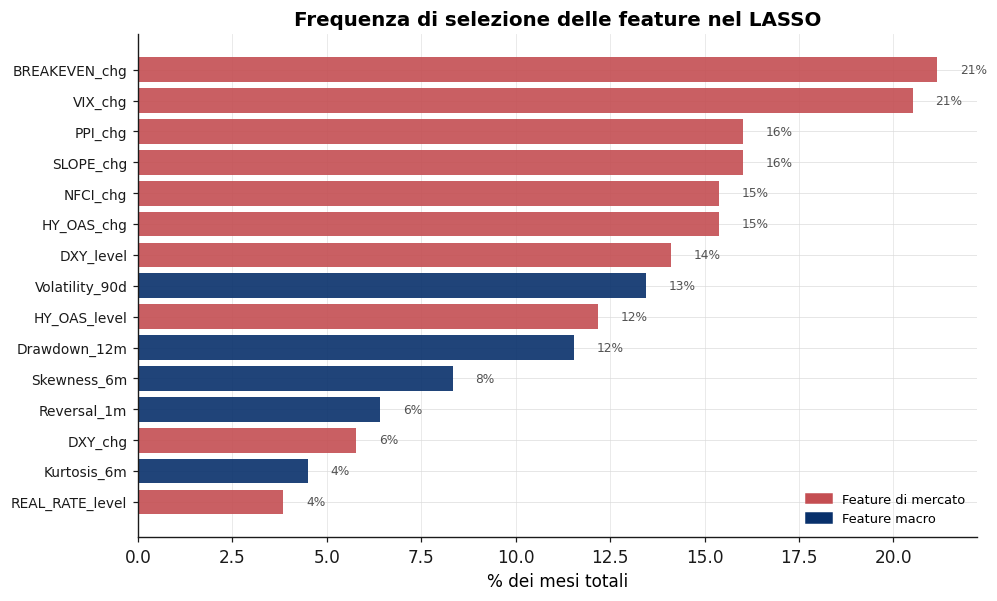

In [10]:
# =============================================================================
# GENERAZIONE DELLE VIEW — esecuzione Blocco 3
# =============================================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from lasso_views import LassoViewGenerator
from plots import PALETTE, apply_theme

# --- Esecuzione --------------------------------------------------------------
book = LassoViewGenerator(CONFIG).run(fs)

# --- Log tecnici di controllo -----------------------------------------------
print("Date con views:", len(book.views),
      "| mesi con view:", int((book.diagnostics["n_views"] > 0).sum()),
      "| views/mese:", round(book.diagnostics["n_views"].mean(), 2))
print("\nDiagnostica (coda):")
print(book.diagnostics.tail(6).round(5).to_string())

# --- Figura 1 ---------------------------
apply_theme()
freq = (book.coef_path != 0).mean().sort_values(ascending=False)
_asset_feats = set(fs.asset_monthly.columns)
_top = freq.head(15)[::-1] 
_colors = [PALETTE["accent"] if f in _asset_feats else PALETTE["stress"]
           for f in _top.index]

fig, ax = plt.subplots(figsize=(9.2, 5.6))
ax.barh(range(len(_top)), _top.values * 100, color=_colors, alpha=0.9)
ax.set_yticks(range(len(_top))); ax.set_yticklabels(_top.index, fontsize=9)
for i, v in enumerate(_top.values * 100):
    ax.text(v + 0.6, i, f"{v:.0f}%", va="center", fontsize=8, color=PALETTE["ink"], alpha=0.75)
ax.set_xlabel("% dei mesi totali")
ax.set_title("Frequenza di selezione delle feature nel LASSO")
ax.legend(handles=[Patch(color=PALETTE["stress"], label="Feature di mercato"),
                   Patch(color=PALETTE["accent"], label="Feature macro")],
          loc="lower right", fontsize=8.5)
fig.tight_layout(rect=[0, 0.05, 1, 1])   # spazio sotto per la legenda
ax.grid(True, axis="x", color=PALETTE["grid"], lw=0.6, alpha=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
save_fig(fig, "fig_01_lasso_selezione_feature")
plt.show()

In [11]:
%%writefile black_litterman.py
# =============================================================================
# BLACKLITTERMAN.PY — Blocco 4 · Modello di Black-Litterman
# =============================================================================
from __future__ import annotations
import logging
from dataclasses import dataclass, field
from typing import Dict, List, Optional
import numpy as np
import pandas as pd
from sklearn.covariance import LedoitWolf
from config import Config, CONFIG
from data_loader import MarketData
from lasso_views import ViewBook

logger = logging.getLogger(__name__)
_MONTH_END = "ME"
_DELTA_FLOOR = 1.0        # avversione minima ammessa
_DELTA_CAP = 20.0         # cap prudenziale sulla delta di mercato
_OMEGA_FLOOR = 1e-8       # pavimento numerico su Omega
_COV_MIN_MONTHS = 36      # storia minima per includere un asset nella covarianza

# ---------------------------------------------------------------------------
# Contenitori di output
# ---------------------------------------------------------------------------
@dataclass
class BLResult:
    # Risultato Black-Litterman per un singolo mese
    date: pd.Timestamp
    assets: List[str]
    pi: pd.Series                 # prior di equilibrio
    mu_bl: pd.Series              # attese posteriori
    sigma: pd.DataFrame           # covarianza prior
    sigma_bl: pd.DataFrame        # covarianza posteriori
    delta: float                  # avversione al rischio
    n_views: int
    w_implied: pd.Series          # pesi impliciti da mu_bl

@dataclass
class BLBook:
    # Raccolta dei risultati BL nel tempo
    results: Dict[pd.Timestamp, BLResult] = field(default_factory=dict)
    diagnostics: pd.DataFrame = field(default_factory=pd.DataFrame)

# ---------------------------------------------------------------------------
# Modello
# ---------------------------------------------------------------------------
class BlackLittermanModel:
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config
        self.bl = config.bl
        self.tau = float(self.bl.tau)
        self.cov_window = int(getattr(self.bl, "cov_window_months",
                                      config.risk.vol_estimation_window))
        self.min_cov_months = int(getattr(self.bl, "min_cov_months", _COV_MIN_MONTHS))
        # Ticker risk-free per l'eccesso nella stima del delta di mercato
        cash = config.tickers_in_group("cash")
        self.rf_ticker = getattr(self.bl, "risk_free_ticker", cash[0] if cash else None)

    # ---- Rendimenti mensili ----------------------------------------------
    @staticmethod
    def _monthly_log_returns(prices_eur: pd.DataFrame) -> pd.DataFrame:
        px = prices_eur.resample(_MONTH_END).last()
        return np.log(px / px.shift(1))

    @staticmethod
    def _monthly_log_returns_series(s: pd.Series) -> pd.Series:
        px = s.resample(_MONTH_END).last()
        return np.log(px / px.shift(1))

    # ---- Covarianza Ledoit-Wolf ------------------------------------------
    def _covariance(self, window_rets: pd.DataFrame) -> Optional[pd.DataFrame]:
        # Covarianza sugli asset con storia sufficiente nella finestra
        counts = window_rets.notna().sum()
        keep = counts[counts >= self.min_cov_months].index.tolist()
        if len(keep) < 2:
            return None
        sub = window_rets[keep].dropna()
        # Se il campione comune è troppo corto, elimina gli asset con meno storia
        while len(sub) < self.min_cov_months and len(keep) > 2:
            shortest = window_rets[keep].notna().sum().idxmin()
            keep.remove(shortest)
            sub = window_rets[keep].dropna()
        if len(sub) < self.min_cov_months or len(keep) < 2:
            return None
        lw = LedoitWolf().fit(sub.values)
        return pd.DataFrame(lw.covariance_, index=keep, columns=keep)

    # ---- Delta implicita dal mercato -------------------------------------
    def _delta(self, bench_ret: pd.Series, rf_ret: pd.Series,
               window: List[pd.Timestamp]) -> float:
        if self.bl.delta_mode == "fixed":
            return float(self.bl.delta_fixed)
        b = bench_ret.reindex(window).dropna()
        if len(b) < 12:
            return float(self.bl.delta_fixed)
        rf = rf_ret.reindex(b.index).fillna(0.0) if rf_ret is not None else 0.0
        excess = b - rf
        var = float(b.var(ddof=1))
        if not np.isfinite(var) or var <= 0:
            return float(self.bl.delta_fixed)
        d = float(excess.mean()) / var
        if not np.isfinite(d) or d <= _DELTA_FLOOR:
            return float(self.bl.delta_fixed)
        return float(min(d, _DELTA_CAP))

    # ---- Pesi strategici rinormalizzati ----------------------------------
    def _w_mkt(self, assets: List[str]) -> pd.Series:
        w = pd.Series({a: self.bl.strategic_weights.get(a, 0.0) for a in assets})
        s = w.sum()
        if s <= 0:
            w = pd.Series(1.0 / len(assets), index=assets)   # fallback equal-weight
        else:
            w = w / s
        return w

    # ---- Posterior (master formula) --------------------------------------
    def _posterior(self, pi: pd.Series, sigma: pd.DataFrame,
                   P: Optional[pd.DataFrame], Q_abs: Optional[pd.Series],
                   omega: Optional[pd.Series]):
        assets = list(pi.index)
        S = sigma.loc[assets, assets].values
        tauS_inv = np.linalg.inv(self.tau * S)
        pi_v = pi.values
        if P is None or P.shape[0] == 0:
            Minv = np.linalg.inv(tauS_inv)
            mu = pi_v.copy()
        else:
            Pm = P.loc[:, assets].values
            Om_inv = np.diag(1.0 / np.maximum(omega.values, _OMEGA_FLOOR))
            A = tauS_inv + Pm.T @ Om_inv @ Pm
            Minv = np.linalg.inv(A)
            mu = Minv @ (tauS_inv @ pi_v + Pm.T @ Om_inv @ Q_abs.values)
        mu_bl = pd.Series(mu, index=assets)
        sigma_bl = pd.DataFrame(S + Minv, index=assets, columns=assets)
        return mu_bl, sigma_bl

    # ---- Loop principale --------------------------------------------------
    def run(self, md: MarketData, view_book: ViewBook) -> BLBook:
        rets_m = self._monthly_log_returns(md.prices_eur)
        bench_m = self._monthly_log_returns_series(md.benchmark)
        rf_m = rets_m[self.rf_ticker] if self.rf_ticker in rets_m.columns else None
        months = list(rets_m.index)
        W = self.cov_window
        results: Dict[pd.Timestamp, BLResult] = {}
        diag = []
        # Mesi di decisione: quelli valutati dal LASSO (allineamento con le views)
        decision_months = (list(view_book.diagnostics.index)
                           if not view_book.diagnostics.empty else months)
        for t in decision_months:
            if t not in months:
                continue
            pos = months.index(t)
            window = months[max(0, pos - W + 1):pos + 1] 
            window_rets = rets_m.loc[window]
            sigma = self._covariance(window_rets)
            if sigma is None:
                continue
            assets = list(sigma.index)
            delta = self._delta(bench_m, rf_m, window)
            w_mkt = self._w_mkt(assets)
            pi = pd.Series(delta * (sigma.values @ w_mkt.values), index=assets)
            # View del LASSO per il mese t
            vs = view_book.views.get(t)
            P = Q_abs = omega = None
            n_views = 0
            if vs is not None and vs.selected:
                sel = [a for a in vs.selected if a in assets]
                if sel:
                    P = pd.DataFrame(0.0, index=sel, columns=assets)
                    for a in sel:
                        P.at[a, a] = 1.0
                    tilt = vs.Q.reindex(sel)
                    Q_abs = pi.reindex(sel) + tilt         # ancoraggio all'equilibrio
                    omega = vs.omega.reindex(sel)
                    n_views = len(sel)
            mu_bl, sigma_bl = self._posterior(pi, sigma, P, Q_abs, omega)
            # Pesi impliciti: senza view riproducono w_mkt
            try:
                w_impl = pd.Series(
                    np.linalg.solve(delta * sigma.values, mu_bl.values), index=assets)
            except np.linalg.LinAlgError:
                w_impl = pd.Series(np.nan, index=assets)
            results[t] = BLResult(date=t, assets=assets, pi=pi, mu_bl=mu_bl,
                                  sigma=sigma, sigma_bl=sigma_bl, delta=delta,
                                  n_views=n_views, w_implied=w_impl)
            diag.append({"date": t, "delta": delta, "n_assets": len(assets),
                         "n_views": n_views, "pi_mean": float(pi.mean()),
                         "mu_bl_mean": float(mu_bl.mean()),
                         "max_abs_tilt": float((mu_bl - pi).abs().max())})
        diagnostics = pd.DataFrame(diag).set_index("date") if diag else pd.DataFrame()
        logger.info("BL: %d mesi elaborati | delta medio=%.2f | mesi con views=%d",
                    len(results), diagnostics["delta"].mean() if not diagnostics.empty else 0.0,
                    int((diagnostics["n_views"] > 0).sum()) if not diagnostics.empty else 0)
        return BLBook(results=results, diagnostics=diagnostics)

if __name__ == "__main__":
    import argparse
    from pathlib import Path
    from data_loader import DataLoader
    from feature_engineering import FeatureEngineer
    from lasso_views import LassoViewGenerator
    logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", default="data")
    args = parser.parse_args()
    CONFIG.data.data_dir = Path(args.data_dir)
    CONFIG.data.fred_dir = Path(args.data_dir)
    md = DataLoader(CONFIG).load()
    fs = FeatureEngineer(CONFIG).build(md)
    book = LassoViewGenerator(CONFIG).run(fs)
    bl = BlackLittermanModel(CONFIG).run(md, book)
    print("\n=== DIAGNOSTICA BL (coda) ===")
    print(bl.diagnostics.tail(6).round(5).to_string())
    print("\ndelta medio:", round(bl.diagnostics["delta"].mean(), 3),
          "| mesi con views:", int((bl.diagnostics["n_views"] > 0).sum()))
    # Check
    no_view = [t for t, r in bl.results.items() if r.n_views == 0]
    if no_view:
        r = bl.results[no_view[len(no_view) // 2]]
        wm = BlackLittermanModel(CONFIG)._w_mkt(r.assets)
        err = float((r.w_implied - wm).abs().max())
        print(f"\nSanity (mese senza views {r.date.date()}): max|w_implied - w_mkt| = {err:.2e}")
    # Esempio con views
    with_view = [t for t, r in bl.results.items() if r.n_views > 0]
    if with_view:
        r = bl.results[with_view[len(with_view) // 2]]
        print(f"\n=== Mese con views {r.date.date()} (delta={r.delta:.2f}, {r.n_views} views) ===")
        tab = pd.DataFrame({"pi": r.pi, "mu_bl": r.mu_bl,
                            "tilt(mu_bl-pi)": r.mu_bl - r.pi}).round(5)
        print(tab.to_string())

Overwriting black_litterman.py


In [12]:
# =============================================================================
# BLACK-LITTERMAN — esecuzione e validazione Blocco 4
# =============================================================================
import pandas as pd
from black_litterman import BlackLittermanModel

bl = BlackLittermanModel(CONFIG).run(md, book)
d = bl.diagnostics

# --- Sintesi -----------------------------------------------------------------
_n_views_tot = int((d["n_views"] > 0).sum())
print("SINTESI BLACK-LITTERMAN")
print(f"  mesi elaborati: {len(d)}")
print(f"  delta (fisso): {d['delta'].mean():.2f}")
print(f"  mesi con view attive: {_n_views_tot} / {len(d)} ({100*_n_views_tot/len(d):.0f}%)")
print(f"  tilt max osservato: {d['max_abs_tilt'].max()*100*12:.2f}% annualizzato")

# --- Esempio: il mese in cui le view spostano di piu' le attese ------------
_r = max(bl.results.values(), key=lambda r: float((r.mu_bl - r.pi).abs().max()))
_tab = pd.DataFrame({
    "pi (%ann)":      (_r.pi * 100 * 12).round(2),
    "mu_BL (%ann)":   (_r.mu_bl * 100 * 12).round(2),
    "tilt (bps ann)": ((_r.mu_bl - _r.pi) * 1e4 * 12).round(1),
}).sort_values("tilt (bps ann)", key=abs, ascending=False)
print(f"\nESEMPIO — {_r.date.strftime('%b %Y')} (mese col tilt massimo, {_r.n_views} view):")
print(_tab.to_string())

# --- Validazione: reverse optimization coerente coi pesi strategici ---------
_nv = next(r for r in bl.results.values() if r.n_views == 0)   # un mese senza view
_wm = BlackLittermanModel(CONFIG)._w_mkt(_nv.assets)
_err = float((_nv.w_implied - _wm).abs().max())
print(f"\nCHECK COERENZA")
print(f" = {_err:.2e}   {'OK' if _err < 1e-8 else 'ATTENZIONE'}")

SINTESI BLACK-LITTERMAN
  mesi elaborati: 156
  delta (fisso): 4.50
  mesi con view attive: 25 / 156 (16%)
  tilt max osservato: 0.84% annualizzato

ESEMPIO — Oct 2022 (mese col tilt massimo, 5 view):
         pi (%ann)  mu_BL (%ann)  tilt (bps ann)
IQQN.DE       4.15          4.99            84.5
SXR1.DE       3.88          4.70            81.6
IQQE.DE       2.91          3.71            79.6
SJPA.L        2.39          3.18            79.5
SYBZ.DE       1.38          1.86            47.4
IEMB.L        2.30          2.66            36.4
SMEA.L        2.69          3.05            35.4
IHYG.L        1.85          2.05            20.6
XEON.DE       0.08         -0.06           -13.9
DBXP.DE       0.17          0.03           -13.8
IGLN.L        0.38          0.30            -7.7
SYBA.DE       0.79          0.84             5.1

CHECK COERENZA
 = 1.11e-16   OK


In [13]:
%%writefile regime_detection.py
# =============================================================================
# REGIMEDETECTION.PY — Blocco 5 · Rilevamento dei regimi via Random Forest
# =============================================================================
from __future__ import annotations
import logging
from dataclasses import dataclass, field
from typing import Dict, List, Optional
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from config import Config, CONFIG
from data_loader import MarketData
from feature_engineering import FeatureSet

logger = logging.getLogger(__name__)
_MONTH_END = "ME"
_TRADING_DAYS = 252
_PCT_MIN_PERIODS = 24        # osservazioni minime per una soglia a percentile sensata

# ---------------------------------------------------------------------------
# Contenitore di output
# ---------------------------------------------------------------------------
@dataclass
class RegimeBook:
    regimes: pd.Series = field(default_factory=lambda: pd.Series(dtype=object))       # 'normal'/'stress'
    prob_stress: pd.Series = field(default_factory=lambda: pd.Series(dtype=float))    # probabilità lisciata
    prob_raw: pd.Series = field(default_factory=lambda: pd.Series(dtype=float))       # probabilità grezza
    labels: pd.Series = field(default_factory=lambda: pd.Series(dtype=float))         # etichetta di stress (target)
    triggers: pd.DataFrame = field(default_factory=pd.DataFrame)                      # flag dei 4 trigger
    importances: pd.Series = field(default_factory=lambda: pd.Series(dtype=float))    # importanza media feature
    diagnostics: Dict[str, float] = field(default_factory=dict)

    def regime_at(self, date: pd.Timestamp, default: str = "normal") -> str:
        # Regime previsto per il mese richiesto (default se assente)
        if date in self.regimes.index and isinstance(self.regimes.loc[date], str):
            return self.regimes.loc[date]
        return default

# ---------------------------------------------------------------------------
# Rilevatore di regimi
# ---------------------------------------------------------------------------
class RegimeDetector:
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config
        self.rc = config.regime
        self.n_triggers_stress = int(self.rc.n_triggers_stress)
        self.feature_lag = int(self.rc.feature_lag_months)
        self.stress_threshold = float(self.rc.stress_prob_threshold)
        self.trigger_mode = str(getattr(self.rc, "trigger_mode", "level"))
        self.delta_h = int(getattr(self.rc, "delta_horizon_months", 1))
        self.delta_pct = float(getattr(self.rc, "delta_pct", 0.90))
        self.label_h = int(getattr(self.rc, "label_horizon_months", 1))

    # ---- Etichetta di stress -----------------------
    @staticmethod
    def _exp_high_flag(s: pd.Series, q: float) -> pd.Series:
        # True quando s supera il proprio q-esimo percentile espandente
        thr = s.expanding(min_periods=_PCT_MIN_PERIODS).quantile(q)
        return (s > thr) & thr.notna()

    def _exp_high_delta_flag(self, s: pd.Series, q: float) -> pd.Series:
        # True quando s supera la variazione della serie (delta)
        d = s - s.shift(self.delta_h)
        thr = d.expanding(min_periods=_PCT_MIN_PERIODS).quantile(q)
        return (d > thr) & thr.notna()

    def _high_flag(self, s: pd.Series, level_pct: float, use_delta: bool) -> pd.Series:
        if use_delta:
            return self._exp_high_delta_flag(s, self.delta_pct)
        return self._exp_high_flag(s, level_pct)

    def _market_indicators(self, md: MarketData, index: pd.DatetimeIndex):
        # Volatilità realizzata (60g) e drawdown a 12 mesi del benchmark
        bench = md.benchmark.dropna().astype(float)
        bret = np.log(bench / bench.shift(1))
        rvol_d = bret.rolling(self.rc.realized_vol_window,
                              min_periods=self.rc.realized_vol_window // 2).std() * np.sqrt(_TRADING_DAYS)
        rvol_m = rvol_d.resample(_MONTH_END).last().reindex(index)
        bpx_m = bench.resample(_MONTH_END).last()
        roll_max = bpx_m.rolling(self.rc.drawdown_window_months,
                                 min_periods=max(3, self.rc.drawdown_window_months // 2)).max()
        dd_m = (bpx_m / roll_max - 1.0).reindex(index)
        return rvol_m, dd_m

    def _build_labels(self, md: MarketData, fs: FeatureSet):
        # Costruisce i 4 trigger e l'etichetta di stress (>= n trigger attivi)
        idx = fs.macro_monthly.index
        rvol, dd = self._market_indicators(md, idx)
        vix = fs.macro_monthly.get("VIX_level", pd.Series(index=idx, dtype=float))
        hy = fs.macro_monthly.get("HY_OAS_level", pd.Series(index=idx, dtype=float))
        # Modalita' per-trigger
        mode = self.trigger_mode
        vol_delta = mode == "delta"
        macro_delta = mode in ("delta", "mixed")
        trig = pd.DataFrame(index=idx)
        trig["vol"] = self._high_flag(rvol, self.rc.realized_vol_pct, vol_delta)
        trig["drawdown"] = dd < self.rc.drawdown_threshold
        trig["vix"] = self._high_flag(vix, self.rc.vix_pct, macro_delta)
        trig["hy_oas"] = self._high_flag(hy, self.rc.hy_oas_pct, macro_delta)
        trig = trig.fillna(False)
        n_active = trig.sum(axis=1)
        labels_raw = (n_active >= self.n_triggers_stress).astype(int)
        # Orizzonte dell'etichetta
        if self.label_h > 1:
            rev = labels_raw[::-1]
            labels = rev.rolling(self.label_h, min_periods=self.label_h).max()[::-1]
        else:
            labels = labels_raw.astype(float)
        return labels, trig, rvol, dd

    # ---- Feature del RF laggate ------------------------
    def _build_features(self, md: MarketData, fs: FeatureSet,
                        rvol: pd.Series, dd: pd.Series) -> pd.DataFrame:
        feat = fs.macro_monthly.copy()
        feat["MKT_RVOL"] = rvol
        feat["MKT_DD"] = dd
        return feat.shift(self.feature_lag)      # solo info fino a t-1 (no look-ahead)

    # ---- Loop rolling: RF espandente, previsione OOS ----------------------
    def run(self, md: MarketData, fs: FeatureSet) -> RegimeBook:
        labels, triggers, rvol, dd = self._build_labels(md, fs)
        features = self._build_features(md, fs, rvol, dd)
        months = list(features.index)
        min_train = self.rc.min_train_months
        prob_raw = pd.Series(index=features.index, dtype=float)
        imp_accum = pd.Series(0.0, index=features.columns)
        imp_count = 0
        for pos, t in enumerate(months):
            if pos < min_train:
                continue
            # Training espandente
            train_end = max(0, pos - self.label_h + 1)
            train_months = months[:train_end]  
            Xtr = features.loc[train_months]
            ytr = labels.loc[train_months]
            mask = Xtr.notna().all(axis=1) & ytr.notna()
            Xtr, ytr = Xtr[mask], ytr[mask]
            if len(ytr) < min_train or ytr.nunique() < 2:
                continue
            xt = features.loc[[t]]
            if xt.isna().any(axis=1).iloc[0]:
                continue
            rf = RandomForestClassifier(
                n_estimators=self.rc.n_estimators, max_depth=self.rc.max_depth,
                min_samples_leaf=self.rc.min_samples_leaf,
                class_weight=self.rc.class_weight, random_state=self.cfg.seed, n_jobs=-1)
            rf.fit(Xtr.values, ytr.values)
            stress_col = list(rf.classes_).index(1) if 1 in rf.classes_ else None
            if stress_col is None:
                continue
            prob_raw.loc[t] = float(rf.predict_proba(xt.values)[0, stress_col])
            imp_accum += pd.Series(rf.feature_importances_, index=features.columns)
            imp_count += 1
        # Lisciamento della probabilità e classificazione a soglia
        prob_smooth = prob_raw.rolling(self.rc.prob_smoothing_window, min_periods=1).mean()
        regimes = prob_smooth.apply(
            lambda p: np.nan if pd.isna(p) else ("stress" if p > self.stress_threshold else "normal"))
        importances = (imp_accum / imp_count).sort_values(ascending=False) if imp_count else pd.Series(dtype=float)
        diagnostics = self._diagnostics(labels, prob_smooth, regimes)
        logger.info("Regimi: %d mesi OOS | stress previsti=%d | accuracy OOS=%.3f | freq stress reale=%.3f",
                    int(prob_raw.notna().sum()),
                    int((regimes == "stress").sum()),
                    diagnostics.get("accuracy", float("nan")),
                    diagnostics.get("stress_freq_true", float("nan")))
        return RegimeBook(regimes=regimes.dropna(), prob_stress=prob_smooth.dropna(),
                          prob_raw=prob_raw.dropna(), labels=labels, triggers=triggers,
                          importances=importances, diagnostics=diagnostics)

    # ---- Diagnostica ------------------------------------------------------
    @staticmethod
    def _diagnostics(labels: pd.Series, prob_smooth: pd.Series,
                     regimes: pd.Series) -> Dict[str, float]:
        # Accuracy, precision, recall e frequenze di stress su periodo OOS comune
        pred = regimes.dropna().map({"normal": 0, "stress": 1})
        common = pred.index.intersection(labels.index)
        y, yhat = labels.reindex(common), pred.reindex(common)
        out: Dict[str, float] = {}
        if len(common):
            out["accuracy"] = float((y == yhat).mean())
            tp = int(((y == 1) & (yhat == 1)).sum()); fp = int(((y == 0) & (yhat == 1)).sum())
            fn = int(((y == 1) & (yhat == 0)).sum())
            out["precision"] = float(tp / (tp + fp)) if (tp + fp) else float("nan")
            out["recall"] = float(tp / (tp + fn)) if (tp + fn) else float("nan")
            out["stress_freq_true"] = float(y.mean())
            out["stress_freq_pred"] = float(yhat.mean())
            out["n_oos"] = int(len(common))
        return out

if __name__ == "__main__":
    import argparse
    from pathlib import Path
    from data_loader import DataLoader
    from feature_engineering import FeatureEngineer
    logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", default="data")
    args = parser.parse_args()
    CONFIG.data.data_dir = Path(args.data_dir)
    CONFIG.data.fred_dir = Path(args.data_dir)
    md = DataLoader(CONFIG).load()
    fs = FeatureEngineer(CONFIG).build(md)
    rb = RegimeDetector(CONFIG).run(md, fs)
    print("\n=== DIAGNOSTICA REGIMI ===")
    for k, v in rb.diagnostics.items():
        print(f"  {k}: {round(v, 4)}")
    print("\nMesi in stress (previsti):", int((rb.regimes == 'stress').sum()),
          "su", len(rb.regimes))
    print("\n=== IMPORTANZA MEDIA FEATURE (top 10) ===")
    print(rb.importances.head(10).round(4).to_string())
    print("\n=== ULTIMI 6 MESI ===")
    tail = pd.DataFrame({"prob_stress": rb.prob_stress, "regime": rb.regimes,
                         "label_reale": rb.labels}).dropna().tail(6)
    print(tail.round(3).to_string())

Overwriting regime_detection.py


DIAGNOSTICA REGIME DETECTION
  accuracy: 0.736
  precision: 0.612
  recall: 0.667
  freq. stress reale: 34.9%
  freq. stress previsto: 38.0%
  mesi in stress: 49 / 129  (38%)


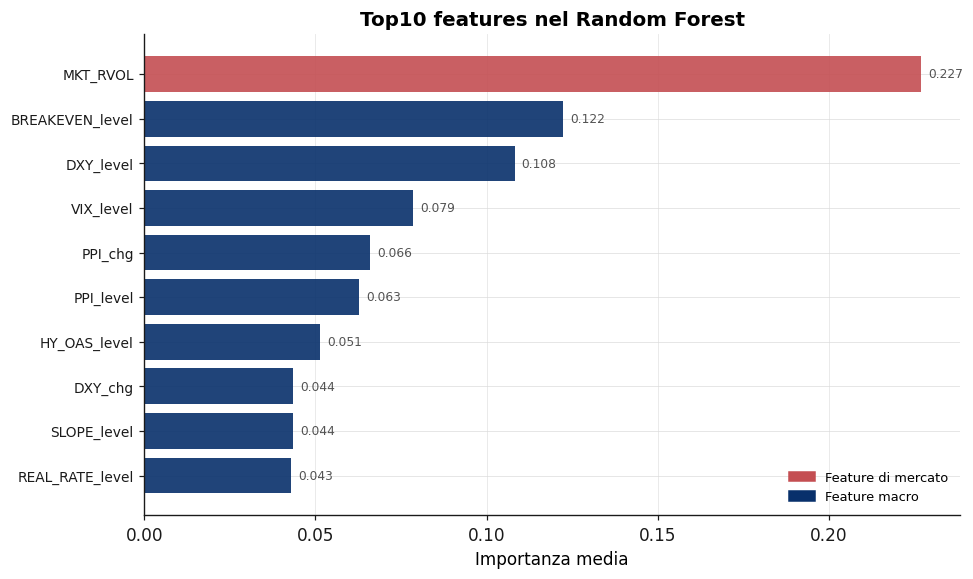

In [14]:
# =============================================================================
# REGIME DETECTION — esecuzione e importanza delle feature Blocco 5
# =============================================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from regime_detection import RegimeDetector
from plots import PALETTE, apply_theme

# --- Esecuzione --------------------------------------------------------------
rb = RegimeDetector(CONFIG).run(md, fs)

# --- Log tecnici di controllo -----------------------------------------------
_d = rb.diagnostics
_n_stress = int((rb.regimes == "stress").sum())
_n_tot = len(rb.regimes)
print("DIAGNOSTICA REGIME DETECTION")
print(f"  accuracy: {_d['accuracy']:.3f}")
print(f"  precision: {_d['precision']:.3f}")
print(f"  recall: {_d['recall']:.3f}")
print(f"  freq. stress reale: {_d['stress_freq_true']*100:.1f}%")
print(f"  freq. stress previsto: {_d['stress_freq_pred']*100:.1f}%")
print(f"  mesi in stress: {_n_stress} / {_n_tot}  ({100*_n_stress/_n_tot:.0f}%)")

# --- Figura 2 ---------------------
apply_theme()
_imp = rb.importances.head(10)[::-1]
_mkt = {"MKT_RVOL", "MKT_DD"}   # feature derivate dal mercato (cuore del segnale di stress)
_colors = [PALETTE["stress"] if f in _mkt else PALETTE["accent"] for f in _imp.index]

fig, ax = plt.subplots(figsize=(9.0, 5.4))
ax.barh(range(len(_imp)), _imp.values, color=_colors, alpha=0.9)
ax.set_yticks(range(len(_imp))); ax.set_yticklabels(_imp.index, fontsize=9)
for i, v in enumerate(_imp.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8, color=PALETTE["ink"], alpha=0.75)
ax.set_xlabel("Importanza media")
ax.set_title("Top10 features nel Random Forest")
ax.legend(handles=[Patch(color=PALETTE["stress"], label="Feature di mercato"),
                   Patch(color=PALETTE["accent"], label="Feature macro")],
          loc="lower right", fontsize=8.5)
ax.grid(True, axis="x", color=PALETTE["grid"], lw=0.6, alpha=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
save_fig(fig, "fig_02_regime_importanze")
plt.show()

In [15]:
%%writefile constraints.py
# =============================================================================
# CONSTRAINTS.PY — Blocco 6 · Vincoli di portafoglio per regime
# =============================================================================
from __future__ import annotations
import logging
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import numpy as np
from config import Config, CONFIG

logger = logging.getLogger(__name__)
_TOL = 1e-6      # tolleranza numerica
_GROUPS = ("defensive", "govt", "cash", "equity", "credit", "gold")

# ---------------------------------------------------------------------------
# Strutture dati
# ---------------------------------------------------------------------------
@dataclass
class GroupConstraint:
    # Vincolo aggregato su un gruppo di asset
    name: str
    members: List[int]       
    lower: Optional[float]
    upper: Optional[float]

@dataclass
class ConstraintSet:
    # Insieme dei vincoli per un singolo mese
    assets: List[str]
    regime: str
    lb: np.ndarray                  # bound inferiori per-asset
    ub: np.ndarray                  # bound superiori per-asset
    groups: List[GroupConstraint]
    fully_invested: bool
    long_only: bool
    feasible: bool
    reason: Optional[str] = None
    relaxations: List[str] = field(default_factory=list)  # floor di gruppo rilassati

    def check_weights(self, w, tol: float = 1e-4) -> List[str]:
        # Validatore a posteriori
        w = np.asarray(w, dtype=float)
        v: List[str] = []
        if self.long_only and (w < -tol).any():
            v.append("pesi negativi (viola long-only)")
        if (w > self.ub + tol).any():
            v.append("single_asset_cap superato")
        if self.fully_invested and abs(w.sum() - 1.0) > 1e-3:
            v.append(f"somma pesi {w.sum():.4f} != 1")
        for g in self.groups:
            s = float(w[g.members].sum())
            if g.upper is not None and s > g.upper + tol:
                v.append(f"gruppo '{g.name}' {s:.3f} > upper {g.upper}")
            if g.lower is not None and s < g.lower - tol:
                v.append(f"gruppo '{g.name}' {s:.3f} < lower {g.lower}")
        return v

# ---------------------------------------------------------------------------
# Builder
# ---------------------------------------------------------------------------
class ConstraintBuilder:
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config
        self.cc = config.constraints
        # Mappa gruppo -> ticker
        self._group_members: Dict[str, set] = {
            g: set(config.tickers_in_group(g)) for g in _GROUPS}
        # Mappa ticker -> sotto-gruppo
        self._sub_group: Dict[str, str] = {a.ticker: a.sub_group for a in config.universe}

    def _regime_key(self, regime: str) -> str:
        # Normalizza il regime in caso di input non previsti
        return regime if regime in self.cc.single_asset_cap else "normal"

    # ---- Costruzione ------------------------------------------------------
    def build(self, assets: List[str], regime: str = "normal",
              relax: bool = True) -> ConstraintSet:
        rk = self._regime_key(regime)
        n = len(assets)
        cap = float(self.cc.single_asset_cap[rk])
        override = self.cc.asset_cap_override.get(rk, {})
        lb = np.zeros(n) if self.cc.long_only else np.full(n, -np.inf)
        # Cap per-asset con deroga per sotto-gruppo
        ub = np.array([override.get(self._sub_group.get(a), cap) for a in assets], dtype=float)
        groups: List[GroupConstraint] = []
        relaxations: List[str] = []
        # Costruisce i vincoli di gruppo sull'universo effettivamente presente
        for gname, (glo, ghi) in self.cc.group_limits[rk].items():
            members = [i for i, a in enumerate(assets)
                       if a in self._group_members.get(gname, set())]
            if not members:
                continue
            eff_lo = glo
            if relax and glo is not None:
                max_reach = float(ub[members].sum())
                if max_reach < glo - _TOL:
                    eff_lo = round(max_reach, 6)
                    relaxations.append(
                        f"{gname}: floor {glo:.2f} -> {eff_lo:.2f} ({len(members)} asset, max {max_reach:.2f})")
            groups.append(GroupConstraint(gname, members, eff_lo, ghi))
        feasible, reason = self._feasibility(assets, ub, groups, rk)
        cs = ConstraintSet(assets=list(assets), regime=rk, lb=lb, ub=ub, groups=groups,
                           fully_invested=self.cc.fully_invested,
                           long_only=self.cc.long_only, feasible=feasible, reason=reason,
                           relaxations=relaxations)
        if relaxations:
            logger.info("Vincoli rilassati (regime=%s, %d asset): %s", rk, n, "; ".join(relaxations))
        if not feasible:
            logger.warning("Vincoli infeasible (regime=%s, %d asset): %s", rk, n, reason)
        return cs

    # ---- Fattibilità ------------------------------------------------------
    def _feasibility(self, assets: List[str], ub: np.ndarray,
                     groups: List[GroupConstraint],
                     rk: str) -> Tuple[bool, Optional[str]]:
        # Verifica le condizioni necessarie perche' esista un peso ammissibile
        n = len(assets)
        reasons: List[str] = []
        if self.cc.fully_invested:
            # Condizione 1) i cap devono poter sommare ad 1
            if ub.sum() < 1.0 - _TOL:
                reasons.append(f"somma dei cap ({ub.sum():.2f}) < 1: impossibile essere fully invested")
            # Condizione 2) ogni lower di gruppo dev'essere raggiungibile coi cap dei suoi membri
            for g in groups:
                if g.lower is not None:
                    max_reach = float(ub[g.members].sum())
                    if max_reach < g.lower - _TOL:
                        reasons.append(
                            f"gruppo '{g.name}': massimo raggiungibile {max_reach:.2f} < lower {g.lower:.2f} "
                            f"({len(g.members)} asset)")
            # Condizione 3) la somma dei lower di gruppo non puo' eccedere 1
            low_sum = sum(g.lower for g in groups if g.lower is not None)
            if low_sum > 1.0 + _TOL:
                reasons.append(f"somma dei lower di gruppo ({low_sum:.2f}) > 1")
            # Condizione 4) gli upper di gruppo devono lasciare spazio per arrivare a 1
            covered = set()
            upper_budget = 0.0
            capped_all = True
            for g in groups:
                if g.upper is not None:
                    upper_budget += g.upper
                    covered.update(g.members)
            if len(covered) == n and capped_all and upper_budget < 1.0 - _TOL:
                reasons.append(f"somma degli upper di gruppo ({upper_budget:.2f}) < 1 con tutti gli asset vincolati")
        return (len(reasons) == 0), ("; ".join(reasons) if reasons else None)

Overwriting constraints.py


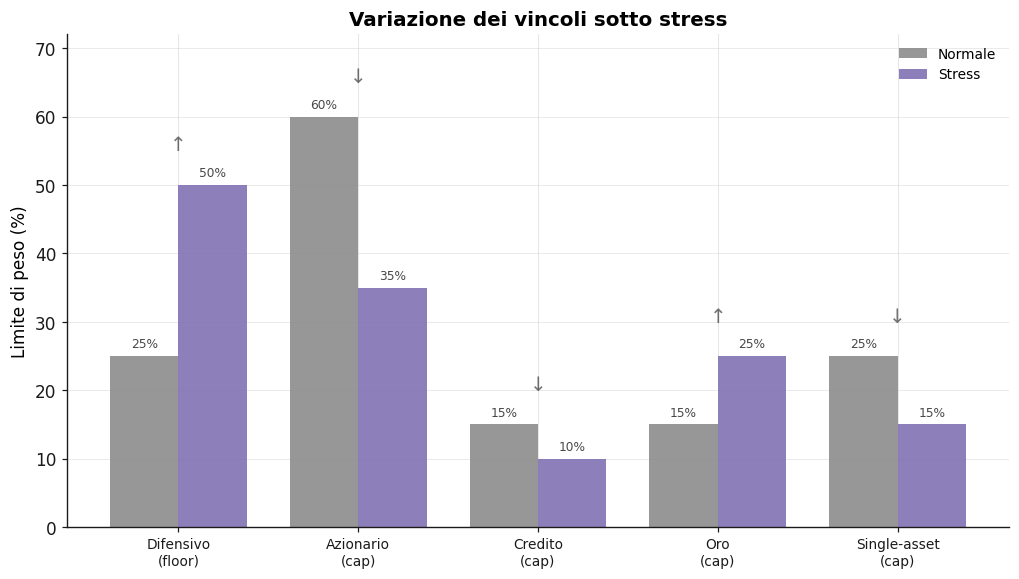

In [16]:
# =============================================================================
# VINCOLI — verifica di fattibilità e figura del de-risking per regime Blocco 6
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from constraints import ConstraintBuilder
from plots import PALETTE, apply_theme

# --- Figura 3 -------------------
apply_theme()
_cc, _gl = CONFIG.constraints, CONFIG.constraints.group_limits
# (etichetta, tipo di limite, valore normale, valore stress)
_levers = [
    ("Difensivo",    "floor", _gl["normal"]["defensive"][0], _gl["stress"]["defensive"][0]),
    ("Azionario",    "cap",   _gl["normal"]["equity"][1],    _gl["stress"]["equity"][1]),
    ("Credito",      "cap",   _gl["normal"]["credit"][1],    _gl["stress"]["credit"][1]),
    ("Oro",          "cap",   _gl["normal"]["gold"][1],      _gl["stress"]["gold"][1]),
    ("Single-asset", "cap",   _cc.single_asset_cap["normal"], _cc.single_asset_cap["stress"]),
]
_labels = [f"{name}\n({typ})" for name, typ, _, _ in _levers]
_norm = np.array([v * 100 for _, _, v, _ in _levers])
_strs = np.array([v * 100 for _, _, _, v in _levers])

_x = np.arange(len(_levers)); _w = 0.38
fig, ax = plt.subplots(figsize=(9.4, 5.4))
_b1 = ax.bar(_x - _w / 2, _norm, _w, label="Normale", color=PALETTE["equal_weight"], alpha=0.9)
_b2 = ax.bar(_x + _w / 2, _strs, _w, label="Stress",  color=PALETTE["full"], alpha=0.9)
for _b in list(_b1) + list(_b2):
    ax.text(_b.get_x() + _b.get_width() / 2, _b.get_height() + 0.8, f"{_b.get_height():.0f}%",
            ha="center", va="bottom", fontsize=8, color=PALETTE["ink"], alpha=0.8)
for _i, (_, _, _vn, _vs) in enumerate(_levers):
    _arrow = "↑" if _vs > _vn else ("↓" if _vs < _vn else "=")
    ax.annotate(_arrow, (_x[_i], max(_norm[_i], _strs[_i]) + 5), ha="center",
                fontsize=13, color=PALETTE["ink"], alpha=0.6)
ax.set_xticks(_x); ax.set_xticklabels(_labels, fontsize=9)
ax.set_ylabel("Limite di peso (%)")
ax.set_ylim(0, max(_strs.max(), _norm.max()) + 12)
ax.set_title("Variazione dei vincoli sotto stress")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, axis="y", color=PALETTE["grid"], lw=0.6, alpha=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
save_fig(fig, "fig_03_vincoli_regime")
plt.show()

In [17]:
%%writefile optimizer.py
# =============================================================================
# OPTIMIZER.PY — Blocco 7 · Ottimizzatore di portafoglio media-varianza
# =============================================================================
from __future__ import annotations
import logging
import math
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
import cvxpy as cp
from config import Config, CONFIG
from black_litterman import BLBook
from regime_detection import RegimeBook
from constraints import ConstraintBuilder, ConstraintSet

logger = logging.getLogger(__name__)
_MONTHS_PER_YEAR = 12
# Bracket e tolleranze per la calibrazione di gamma
_GAMMA_MIN = 1e-3
_GAMMA_MAX = 1e3
_MAX_ITER = 40
_VOL_TOL = 1e-4         # tolleranza sulla vol annualizzata

# ---------------------------------------------------------------------------
# Contenitori di output
# ---------------------------------------------------------------------------
@dataclass
class OptimizeResult:
    date: pd.Timestamp
    assets: List[str]
    weights: pd.Series
    regime: str
    status: str                 # optimal | vol_below_target | vol_above_target | strategic_projected | strategic_raw
    ex_ante_vol: float          # volatilità annualizzata ex-ante del portafoglio scelto
    gamma: float                # coefficiente di avversione calibrato
    target_hit: bool
    n_views: int

@dataclass
class OptimizerBook:
    results: Dict[pd.Timestamp, OptimizeResult] = field(default_factory=dict)
    weights: pd.DataFrame = field(default_factory=pd.DataFrame)
    diagnostics: pd.DataFrame = field(default_factory=pd.DataFrame)

# ---------------------------------------------------------------------------
# Ottimizzatore
# ---------------------------------------------------------------------------
class PortfolioOptimizer:
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config
        self.builder = ConstraintBuilder(config)
        self.target_vol = float(config.risk.target_vol_annual)
        self._solver = self._pick_solver(config.optimizer.solver)

    @staticmethod
    def _pick_solver(preferred: str) -> str:
        # Primo solver disponibile tra il preferito e i fallback
        available = cp.installed_solvers()
        for s in (preferred, "ECOS", "CLARABEL", "SCS"):
            if s in available:
                return s
        return available[0]

    # ---- Vincoli base ----------------------------------------------------
    def _base_constraints(self, w: cp.Variable, cs: ConstraintSet) -> list:
        # Traduce il ConstraintSet in vincoli cvxpy
        cons = [w <= cs.ub]
        if cs.long_only:
            cons.append(w >= 0)
        if cs.fully_invested:
            cons.append(cp.sum(w) == 1)
        for g in cs.groups:
            expr = cp.sum(w[g.members])
            if g.lower is not None:
                cons.append(expr >= g.lower)
            if g.upper is not None:
                cons.append(expr <= g.upper)
        return cons

    def _solve(self, objective, constraints) -> Optional[np.ndarray]:
        # Risolve il problema e ripulisce numericamente i pesi
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=self._solver)
        except Exception:
            try:
                prob.solve(solver="SCS")
            except Exception:
                return None
        if prob.status not in ("optimal", "optimal_inaccurate"):
            return None
        w = prob.variables()[0].value
        if w is None:
            return None
        w = np.clip(np.asarray(w, dtype=float), 0.0, None)
        s = w.sum()
        return w / s if s > 1e-9 else None

    # ---- Media-varianza a gamma dato --------------------------------------
    def _mv(self, mu, Sigma, cs, gamma: float) -> Optional[np.ndarray]:
        w = cp.Variable(len(cs.assets))
        S = cp.psd_wrap(Sigma)
        cons = self._base_constraints(w, cs)
        obj = cp.Maximize(mu @ w - (gamma / 2.0) * cp.quad_form(w, S))
        return self._solve(obj, cons)

    def _pvol(self, w: np.ndarray, Sigma: np.ndarray) -> float:
        # Volatilità annualizzata ex-ante
        return float(np.sqrt(max(float(w @ Sigma @ w), 0.0)) * np.sqrt(_MONTHS_PER_YEAR))

    # ---- Fallback strategici ---------------------------------------------
    def _project_strategic(self, cs) -> Optional[np.ndarray]:
        # Proietta i pesi strategici sull'insieme ammissibile
        w_strat = self._strategic_vector(cs.assets)
        w = cp.Variable(len(cs.assets))
        cons = self._base_constraints(w, cs)
        obj = cp.Minimize(cp.sum_squares(w - w_strat))
        return self._solve(obj, cons)

    def _strategic_vector(self, assets: List[str]) -> np.ndarray:
        sw = self.cfg.bl.strategic_weights
        w = np.array([sw.get(a, 0.0) for a in assets], dtype=float)
        s = w.sum()
        return w / s if s > 0 else np.full(len(assets), 1.0 / len(assets))

    def _strategic_raw(self, cs) -> np.ndarray:
        # Pesi strategici troncati ai cap
        w = np.clip(self._strategic_vector(cs.assets), 0.0, cs.ub)
        s = w.sum()
        return w / s if s > 1e-9 else np.full(len(cs.assets), 1.0 / len(cs.assets))

    # ---- Ottimizzazione di un mese con calibrazione di gamma --------------
    def optimize_month(self, mu: np.ndarray, Sigma: np.ndarray,
                       cs: ConstraintSet) -> Tuple[np.ndarray, str, float]:
        if not cs.feasible:
            return self._strategic_raw(cs), "strategic_raw", float("nan")
        target = self.target_vol
        # Estremi del bracket: gamma_min -> vol massima; gamma_max -> vol minima
        w_lo = self._mv(mu, Sigma, cs, _GAMMA_MIN)
        w_hi = self._mv(mu, Sigma, cs, _GAMMA_MAX)
        if w_lo is None or w_hi is None:
            w = self._project_strategic(cs)
            if w is not None:
                return w, "strategic_projected", float("nan")
            return self._strategic_raw(cs), "strategic_raw", float("nan")
        vol_lo = self._pvol(w_lo, Sigma)        
        vol_hi = self._pvol(w_hi, Sigma)         
        # Mese calmo: neanche col massimo rischio si arriva al target
        if vol_lo <= target + _VOL_TOL:
            return w_lo, "vol_below_target", _GAMMA_MIN
        # Crisi: neanche il min-variance scende al target
        if vol_hi >= target - _VOL_TOL:
            return w_hi, "vol_above_target", _GAMMA_MAX
        # Bisezione su gamma per centrare il target
        lo, hi = _GAMMA_MIN, _GAMMA_MAX
        w_star, g_star, best = w_hi, _GAMMA_MAX, abs(vol_hi - target)
        for _ in range(_MAX_ITER):
            g = math.sqrt(lo * hi)          # media geometrica
            w = self._mv(mu, Sigma, cs, g)
            if w is None:
                break
            v = self._pvol(w, Sigma)
            if abs(v - target) < best:
                w_star, g_star, best = w, g, abs(v - target)
            if abs(v - target) <= _VOL_TOL:
                break
            if v > target:          # troppo rischioso -> piu' avversione
                lo = g
            else:                   # troppo prudente -> meno avversione
                hi = g
        return w_star, "optimal", g_star

    # ---- Loop principale --------------------------------------------------
    def run(self, bl_book: BLBook, regime_book: RegimeBook) -> OptimizerBook:
        results: Dict[pd.Timestamp, OptimizeResult] = {}
        wrows: Dict[pd.Timestamp, pd.Series] = {}
        diag = []
        for t in sorted(bl_book.results):
            br = bl_book.results[t]
            assets = br.assets
            mu = br.mu_bl.reindex(assets).to_numpy(dtype=float)
            Sigma = br.sigma.loc[assets, assets].to_numpy(dtype=float)
            Sigma = (Sigma + Sigma.T) / 2.0
            regime = regime_book.regime_at(t) if regime_book is not None else "normal"
            cs = self.builder.build(assets, regime)
            w, status, gamma = self.optimize_month(mu, Sigma, cs)
            wser = pd.Series(w, index=assets)
            ex_ante_vol = self._pvol(w, Sigma)
            target_hit = abs(ex_ante_vol - self.target_vol) <= 1e-3
            results[t] = OptimizeResult(date=t, assets=assets, weights=wser, regime=regime,
                                        status=status, ex_ante_vol=ex_ante_vol, gamma=gamma,
                                        target_hit=target_hit, n_views=br.n_views)
            wrows[t] = wser
            diag.append({"date": t, "regime": regime, "status": status,
                         "ex_ante_vol": ex_ante_vol, "gamma": gamma,
                         "target_hit": target_hit, "n_views": br.n_views,
                         "n_assets": len(assets)})
        weights = pd.DataFrame(wrows).T.reindex(columns=self.cfg.tickers)
        weights.index.name = "date"
        diagnostics = pd.DataFrame(diag).set_index("date") if diag else pd.DataFrame()
        if not diagnostics.empty:
            logger.info("Optimizer: %d mesi | optimal=%d | vol media=%.3f | target centrato in %d mesi",
                        len(results), int((diagnostics["status"] == "optimal").sum()),
                        diagnostics["ex_ante_vol"].mean(), int(diagnostics["target_hit"].sum()))
        return OptimizerBook(results=results, weights=weights, diagnostics=diagnostics)

if __name__ == "__main__":
    import argparse
    from pathlib import Path
    from data_loader import DataLoader
    from feature_engineering import FeatureEngineer
    from lasso_views import LassoViewGenerator
    from black_litterman import BlackLittermanModel
    from regime_detection import RegimeDetector
    logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", default="data")
    args = parser.parse_args()
    CONFIG.data.data_dir = Path(args.data_dir)
    CONFIG.data.fred_dir = Path(args.data_dir)
    md = DataLoader(CONFIG).load()
    fs = FeatureEngineer(CONFIG).build(md)
    book = LassoViewGenerator(CONFIG).run(fs)
    bl = BlackLittermanModel(CONFIG).run(md, book)
    rb = RegimeDetector(CONFIG).run(md, fs)
    opt = PortfolioOptimizer(CONFIG).run(bl, rb)
    d = opt.diagnostics
    print("\n=== DIAGNOSTICA OTTIMIZZATORE (coda) ===")
    print(d.tail(8).round(4).to_string())
    print("\nStati:", d["status"].value_counts().to_dict())
    print("Vol ex-ante media:", round(d["ex_ante_vol"].mean(), 4),
          "| target centrato:", int(d["target_hit"].sum()), "su", len(d))
    print("Vol media per regime:")
    print(d.groupby("regime")["ex_ante_vol"].mean().round(4).to_string())
    last = max(opt.results); r = opt.results[last]
    print(f"\nPesi a {last.date()} (regime {r.regime}, vol {r.ex_ante_vol:.3f}, gamma {r.gamma:.3g}):")
    print(r.weights[r.weights > 1e-4].round(4).to_string())

Overwriting optimizer.py


In [18]:
# =============================================================================
# OTTIMIZZATORE — diagnostica di controllo Blocco 7
# =============================================================================
from optimizer import PortfolioOptimizer

opt = PortfolioOptimizer(CONFIG).run(bl, rb)
d = opt.diagnostics
_n = len(d)

_opt = int((d["status"] == "optimal").sum())              
_below = int((d["status"] == "vol_below_target").sum())
_vn = d.loc[d["regime"] == "normal", "ex_ante_vol"].mean()
_vs = d.loc[d["regime"] == "stress", "ex_ante_vol"].mean()
_tgt = CONFIG.risk.target_vol_annual * 100

print("DIAGNOSTICA OTTIMIZZATORE")
print(f"  vol ex-ante media: {d['ex_ante_vol'].mean()*100:.2f}%")
print(f"  target raggiunto: {_opt}/{_n} mesi ({100*_opt/_n:.0f}%)")
print(f"  target irraggiungibile: {_below}/{_n} mesi ({100*_below/_n:.0f}%) → vol naturale sotto il target")
print(f"  vol media regime normale: {_vn*100:.2f}%")
print(f"  vol media regime stress: {_vs*100:.2f}%")

DIAGNOSTICA OTTIMIZZATORE
  vol ex-ante media: 8.91%
  target raggiunto: 78/156 mesi (50%)
  target irraggiungibile: 78/156 mesi (50%) → vol naturale sotto il target
  vol media regime normale: 9.76%
  vol media regime stress: 7.07%


In [19]:
%%writefile backtest.py
# =============================================================================
# BACKTEST.PY — Blocco 8 · Backtest out-of-sample e confronto tra ottimizzatori
# =============================================================================
from __future__ import annotations
import logging
from dataclasses import dataclass, field
from typing import Dict, List, Optional
import numpy as np
import pandas as pd
from config import Config, CONFIG, RISK_FREE_TICKER
from data_loader import MarketData
from black_litterman import BLBook
from regime_detection import RegimeBook
from constraints import ConstraintBuilder, ConstraintSet
from optimizer import PortfolioOptimizer

logger = logging.getLogger(__name__)
_MONTHS_PER_YEAR = 12
_MONTH_END = "ME"

# ---------------------------------------------------------------------------
# Specifica di una variante
# ---------------------------------------------------------------------------
@dataclass(frozen=True)
class VariantSpec:
    # Definisce un ottimizzatore alternativo: cosa cambia rispetto al framework
    name: str
    mu_source: str          # 'sample' | 'pi' | 'bl' | 'none'
    sigma_source: str       # 'lw' (Ledoit-Wolf) | 'sample'
    use_regimes: bool
    gamma_mode: str         # 'calibrated' | 'fixed' | 'equal_weight'
    design: str             # 'A' | 'B'
    unconstrained: bool = False   # True = solo long-only + pieno investimento (baseline "nuda")

NAKED_VARIANTS: List[VariantSpec] = [
    # Baseline non vincolate per la horse-race (Cap. 4): solo long-only + pieno
    # investimento. Documentano l'instabilita' dei metodi standard senza la
    # struttura di vincoli, che e' il contributo del framework.
    VariantSpec("markowitz_nudo",  "sample", "sample", False, "fixed", "B", unconstrained=True),
    VariantSpec("bl_classic_nudo", "pi",     "lw",     False, "fixed", "B", unconstrained=True),
]

DEFAULT_VARIANTS: List[VariantSpec] = [
    # Cinque strategie, usate sia per entrambe le tipologie di confronti
    # Markowitz -> + prior BL -> + views LASSO -> + regimi (full); benchmark 1/N
    VariantSpec("markowitz",     "sample", "sample", False, "fixed",        "AB"),
    VariantSpec("bl_classic",    "pi",     "lw",     False, "fixed",        "AB"),
    VariantSpec("bl_views",      "bl",     "lw",     False, "fixed",        "A"),
    VariantSpec("full",          "bl",     "lw",     True,  "fixed",        "AB"),
    VariantSpec("equal_weight", "none", "lw", False, "equal_weight", "B"),
]

# ---------------------------------------------------------------------------
# Contenitori di output
# ---------------------------------------------------------------------------
@dataclass
class BacktestResult:
    name: str
    weights: pd.DataFrame          # pesi decisi a fine mese t
    returns: pd.Series             # rendimenti realizzati in t+1
    gross_returns: pd.Series       # rendimenti lordi
    turnover: pd.Series
    ex_ante_vol: pd.Series
    metrics: Dict[str, float] = field(default_factory=dict)

@dataclass
class BacktestBook:
    results: Dict[str, BacktestResult] = field(default_factory=dict)
    summary: pd.DataFrame = field(default_factory=pd.DataFrame)
    summary_A: pd.DataFrame = field(default_factory=pd.DataFrame)
    summary_B: pd.DataFrame = field(default_factory=pd.DataFrame)

# ---------------------------------------------------------------------------
# Generatore dei pesi per variante
# ---------------------------------------------------------------------------
class VariantGenerator:
    # Produce i pesi mensili di una variante riusando il motore del blocco precedente
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config
        self.opt = PortfolioOptimizer(config)
        self.builder = ConstraintBuilder(config)
        self.gamma_fixed = float(config.optimizer.gamma)

    @staticmethod
    def _naked_constraints(assets: List[str]) -> ConstraintSet:
        # Vincoli minimi: long-only + pieno investimento, nessun cap ne' limite
        # di gruppo. Rappresenta le baseline "come in letteratura" (Markowitz e
        # Black-Litterman classico non vincolati), usate solo nella horse-race.
        n = len(assets)
        return ConstraintSet(assets=list(assets), regime="none",
                             lb=np.zeros(n), ub=np.ones(n), groups=[],
                             fully_invested=True, long_only=True,
                             feasible=True, reason=None)

    @staticmethod
    def _window(rets_m: pd.DataFrame, t: pd.Timestamp, window: int) -> Optional[List]:
        # Finestra rolling di stima che termina in t (incluso)
        months = list(rets_m.index)
        if t not in months:
            return None
        pos = months.index(t)
        return months[max(0, pos - window + 1):pos + 1]

    @classmethod
    def _sample_mu(cls, rets_m: pd.DataFrame, t: pd.Timestamp, assets: List[str],
                   window: int) -> Optional[np.ndarray]:
        # Media campionaria rolling sui log-rendimenti
        win = cls._window(rets_m, t, window)
        if win is None:
            return None
        mu = rets_m.loc[win, assets].mean()
        if mu.isna().any():
            return None
        return mu.to_numpy(dtype=float)

    @classmethod
    def _sample_sigma(cls, rets_m: pd.DataFrame, t: pd.Timestamp, assets: List[str],
                      window: int) -> Optional[np.ndarray]:
        # Covarianza campionaria (senza shrinkage)
        win = cls._window(rets_m, t, window)
        if win is None:
            return None
        sub = rets_m.loc[win, assets].dropna()
        if len(sub) <= len(assets):
            return None
        S = sub.cov().to_numpy(dtype=float)
        if not np.all(np.isfinite(S)):
            return None
        return (S + S.T) / 2.0

    def run(self, spec: VariantSpec, bl_book: BLBook, regime_book: RegimeBook,
            rets_m: pd.DataFrame) -> pd.DataFrame:
        rows: Dict[pd.Timestamp, pd.Series] = {}
        vols: Dict[pd.Timestamp, float] = {}
        cov_window = self.cfg.risk.vol_estimation_window
        for t in sorted(bl_book.results):
            br = bl_book.results[t]
            assets = br.assets
            # Covarianza: Ledoit-Wolf o campionaria
            if spec.sigma_source == "lw":
                Sigma = br.sigma.loc[assets, assets].to_numpy(dtype=float)
                Sigma = (Sigma + Sigma.T) / 2.0
            elif spec.sigma_source == "sample":
                Sigma = self._sample_sigma(rets_m, t, assets, cov_window)
                if Sigma is None:
                    continue
            else:
                raise ValueError(f"sigma_source sconosciuto: {spec.sigma_source}")
            # --- Equipesato ------------
            if spec.gamma_mode == "equal_weight":
                w = np.full(len(assets), 1.0 / len(assets))
                rows[t] = pd.Series(w, index=assets)
                vols[t] = self.opt._pvol(w, Sigma)
                continue
            # --- Vettore delle attese mu -------------------------------------
            if spec.mu_source == "bl":
                mu = br.mu_bl.reindex(assets).to_numpy(dtype=float)
            elif spec.mu_source == "pi":
                mu = br.pi.reindex(assets).to_numpy(dtype=float)
            elif spec.mu_source == "sample":
                mu = self._sample_mu(rets_m, t, assets, cov_window)
                if mu is None:
                    continue
            else:
                raise ValueError(f"mu_source sconosciuto: {spec.mu_source}")
            # --- Vincoli: regime del mese o regime unico ---------------------
            if spec.unconstrained:
                cs = self._naked_constraints(assets)
            else:
                regime = regime_book.regime_at(t) if spec.use_regimes else "normal"
                cs = self.builder.build(assets, regime)
            # --- Soluzione ---------------------------------------------------
            if spec.gamma_mode == "calibrated":
                w, _status, _g = self.opt.optimize_month(mu, Sigma, cs)
            else:                                    # gamma fisso
                w = self.opt._mv(mu, Sigma, cs, self.gamma_fixed)
                if w is None:
                    w = self.opt._strategic_raw(cs)
            rows[t] = pd.Series(w, index=assets)
            vols[t] = self.opt._pvol(np.asarray(w), Sigma)
        weights = pd.DataFrame(rows).T.reindex(columns=self.cfg.tickers)
        weights.index.name = "date"
        weights.attrs["ex_ante_vol"] = pd.Series(vols).sort_index()
        return weights

# ---------------------------------------------------------------------------
# Backtester
# ---------------------------------------------------------------------------
class Backtester:
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config
        self.cost_bps = float(config.backtest.transaction_costs_bps)
        self.rf_ticker = RISK_FREE_TICKER

    # ---- Rendimenti semplici mensili -------------------------------------
    @staticmethod
    def _monthly_simple_returns(prices_eur: pd.DataFrame) -> pd.DataFrame:
        px = prices_eur.resample(_MONTH_END).last()
        return px.pct_change()

    # ---- Valutazione di una serie di pesi ---------------------------------
    def evaluate(self, name: str, weights: pd.DataFrame,
                 simple_rets: pd.DataFrame, rf: pd.Series) -> BacktestResult:
        w = weights.fillna(0.0)
        months = [t for t in w.index if t in simple_rets.index]
        gross, net, turn = {}, {}, {}
        prev: Optional[pd.Series] = None
        prev_date: Optional[pd.Timestamp] = None
        for t in months:
            pos = simple_rets.index.get_loc(t)
            wt = w.loc[t]
            # Turnover: confronto coi pesi precedenti derivati (drift) col mercato
            if prev is None:
                tn = 1.0
            else:
                pos_prev = simple_rets.index.get_loc(prev_date)
                if pos == pos_prev + 1:
                    r_now = simple_rets.loc[t].reindex(prev.index)
                    m = r_now.notna() & (prev.abs() > 0)
                    r_p_prev = float((prev[m] * r_now[m]).sum())
                    denom = 1.0 + r_p_prev
                    w_drift = (prev * (1.0 + r_now.fillna(0.0)) / denom
                               if abs(denom) > 1e-12 else prev)
                else:
                    w_drift = prev
                tn = float((wt - w_drift).abs().sum() / 2.0)
            cost = tn * self.cost_bps / 1e4
            turn[t] = tn
            # Rendimento realizzato: media pesata dei rendimenti semplici di t+1
            if pos + 1 < len(simple_rets.index):
                t_next = simple_rets.index[pos + 1]
                r_next = simple_rets.loc[t_next].reindex(wt.index)
                mask = r_next.notna() & (wt.abs() > 0)
                r_p = float((wt[mask] * r_next[mask]).sum())
                gross[t_next] = r_p
                net[t_next] = r_p - cost                  # costo pagato al ribilanciamento
            prev, prev_date = wt, t
        gross_s = pd.Series(gross).sort_index()
        net_s = pd.Series(net).sort_index()
        turn_s = pd.Series(turn).sort_index()
        ex_ante = weights.attrs.get("ex_ante_vol", pd.Series(dtype=float))
        metrics = self._metrics(net_s, rf, turn_s)
        return BacktestResult(name=name, weights=w, returns=net_s, gross_returns=gross_s,
                              turnover=turn_s, ex_ante_vol=ex_ante, metrics=metrics)

    # ---- Metriche ---------------------------------------------------------
    def _metrics(self, r: pd.Series, rf: pd.Series, turn: pd.Series) -> Dict[str, float]:
        # Rendimento/vol annualizzati, Sharpe in eccesso su rf, max drawdown
        if r.empty:
            return {}
        n = len(r)
        rf_a = rf.reindex(r.index).fillna(0.0)
        excess = r - rf_a
        cum = float((1.0 + r).prod())
        ann_ret = cum ** (_MONTHS_PER_YEAR / n) - 1.0
        ann_vol = float(r.std(ddof=1)) * np.sqrt(_MONTHS_PER_YEAR)
        sharpe = (float(excess.mean()) / float(excess.std(ddof=1))
                  * np.sqrt(_MONTHS_PER_YEAR)) if excess.std(ddof=1) > 0 else np.nan
        wealth = (1.0 + r).cumprod()
        max_dd = float((wealth / wealth.cummax() - 1.0).min())
        return {"ann_return": ann_ret, "ann_vol": ann_vol, "sharpe": sharpe,
                "max_dd": max_dd,
                "turnover_avg": float(turn.mean()) if not turn.empty else np.nan,
                "n_months": n}

    # ---- Loop su tutte le varianti ----------------------------------------
    def run(self, md: MarketData, bl_book: BLBook, regime_book: RegimeBook,
            variants: Optional[List[VariantSpec]] = None) -> BacktestBook:
        variants = variants or DEFAULT_VARIANTS
        simple_rets = self._monthly_simple_returns(md.prices_eur)
        log_rets = np.log(md.prices_eur.resample(_MONTH_END).last()).diff()
        rf = (simple_rets[self.rf_ticker] if self.rf_ticker in simple_rets.columns
              else pd.Series(0.0, index=simple_rets.index))
        gen = VariantGenerator(self.cfg)
        results: Dict[str, BacktestResult] = {}
        for spec in variants:
            w = gen.run(spec, bl_book, regime_book, log_rets)
            if w.empty:
                logger.warning("Variante %s: nessun peso generato.", spec.name)
                continue
            res = self.evaluate(spec.name, w, simple_rets, rf)
            res.metrics["design"] = spec.design
            results[spec.name] = res
            logger.info("%-14s | ret %.2f%% | vol %.2f%% | Sharpe %.2f | turnover %.1f%%",
                        spec.name, 100 * res.metrics["ann_return"],
                        100 * res.metrics["ann_vol"], res.metrics["sharpe"],
                        100 * res.metrics["turnover_avg"])
        summary = pd.DataFrame({k: v.metrics for k, v in results.items()}).T
        cols = ["ann_return", "ann_vol", "sharpe", "max_dd", "turnover_avg", "n_months"]
        summary = summary.reindex(columns=cols + ["design"])

        def _sub(order: List[str]) -> pd.DataFrame:
            keep = [n for n in order if n in summary.index]
            return summary.loc[keep, cols]

        summary_A = _sub(["markowitz", "bl_classic", "bl_views", "full"])
        summary_B = _sub(["equal_weight", "markowitz", "bl_classic", "full"])
        return BacktestBook(results=results, summary=summary,
                            summary_A=summary_A, summary_B=summary_B)

    # ---- Diagnostica di concentrazione (per la horse-race) ----------------
    @staticmethod
    def concentration(weights: pd.DataFrame) -> Dict[str, float]:
        # Numero effettivo di posizioni (1/HHI) e peso massimo, medi nel tempo
        w = weights.fillna(0.0).to_numpy(dtype=float)
        hhi = (w ** 2).sum(axis=1)
        eff = np.divide(1.0, hhi, out=np.full_like(hhi, np.nan), where=hhi > 0)
        wmax = np.nanmax(np.where(w > 0, w, np.nan), axis=1)
        return {"n_eff": float(np.nanmean(eff)), "w_max": float(np.nanmean(wmax))}

    # ---- Horse-race: framework vincolato vs baseline nude -----------------
    def horse_race(self, md: MarketData, bl_book: BLBook, regime_book: RegimeBook,
                   constrained: Optional[List[str]] = None) -> pd.DataFrame:
        # Tabella di confronto "come in letteratura": esegue le baseline nude e
        # le affianca alle varianti vincolate gia' calcolate, aggiungendo le
        # colonne di stabilita' (n_eff, w_max) che rendono leggibile il trade-off.
        constrained = constrained or ["full", "bl_classic", "equal_weight"]
        book = self.run(md, bl_book, regime_book)                 # varianti standard
        naked = self.run(md, bl_book, regime_book, variants=NAKED_VARIANTS)
        rows = {}
        cols = ["ann_return", "ann_vol", "sharpe", "max_dd", "turnover_avg"]
        for nm in constrained:
            if nm in book.results:
                r = book.results[nm]
                rows[nm] = {**{c: r.metrics.get(c) for c in cols},
                            **self.concentration(r.weights), "vincoli": "si"}
        for nm, r in naked.results.items():
            rows[nm] = {**{c: r.metrics.get(c) for c in cols},
                        **self.concentration(r.weights), "vincoli": "no"}
        order = constrained + list(naked.results.keys())
        df = pd.DataFrame(rows).T.reindex(index=[o for o in order if o in rows])
        return df.reindex(columns=cols + ["n_eff", "w_max", "vincoli"])

# ---------------------------------------------------------------------------
# Formattazione delle tabelle
# ---------------------------------------------------------------------------
_PCT_COLS = ["ann_return", "ann_vol", "max_dd", "turnover_avg"]

# ---------------------------------------------------------------------------
# Robustezza: sensibilità del framework alla scelta dei pesi strategici
# ---------------------------------------------------------------------------
def _internal_shares(config: Config) -> Dict[str, Dict[str, float]]:
    # Quote interne di ciascun asset entro la sua classe nei pesi strategici base
    sw = config.bl.strategic_weights
    by_cls: Dict[str, Dict[str, float]] = {}
    for a in config.universe:
        by_cls.setdefault(a.asset_class, {})[a.ticker] = sw[a.ticker]
    shares: Dict[str, Dict[str, float]] = {}
    for cls, d in by_cls.items():
        tot = sum(d.values())
        shares[cls] = {t: (w / tot if tot > 0 else 0.0) for t, w in d.items()}
    return shares

def strategic_from_macro(config: Config, macro: Dict[str, float]) -> Dict[str, float]:
    # Ricostruisce i pesi per-asset da un'allocazione macro (safe, risky, real)
    shares = _internal_shares(config)
    w: Dict[str, float] = {}
    for cls, sh in shares.items():
        for t, s in sh.items():
            w[t] = macro.get(cls, 0.0) * s
    return w

# Allocazioni macro alternative per l'analisi di robustezza del prior
DEFAULT_PRIOR_ALTERNATIVES: Dict[str, Dict[str, float]] = {
    "base 40/50/10":       {"safe": 0.40, "risky": 0.50, "real": 0.10},
    "prudente 50/40/10":   {"safe": 0.50, "risky": 0.40, "real": 0.10},
    "aggressivo 30/60/10": {"safe": 0.30, "risky": 0.60, "real": 0.10},
}

def prior_sensitivity(md: MarketData, view_book, regime_book,
                      config: Config = CONFIG,
                      alternatives: Optional[Dict[str, Dict[str, float]]] = None
                      ) -> pd.DataFrame:
    # Rilancia il framework 'full' variando l'allocazione strategica di riferimento
    import copy
    from black_litterman import BlackLittermanModel
    alternatives = alternatives or DEFAULT_PRIOR_ALTERNATIVES
    rows: Dict[str, Dict[str, float]] = {}
    for name, macro in alternatives.items():
        cfg = copy.deepcopy(config)
        cfg.bl.strategic_weights = strategic_from_macro(config, macro)
        cfg.validate()                                      # somma=1 e coerenza
        bl_p = BlackLittermanModel(cfg).run(md, view_book)
        bt_p = Backtester(cfg).run(md, bl_p, regime_book)
        m = bt_p.results["full"].metrics
        rows[name] = {k: m.get(k) for k in
                      ["ann_return", "ann_vol", "sharpe", "max_dd", "turnover_avg"]}
    return pd.DataFrame(rows).T

def format_summary(df: pd.DataFrame) -> pd.DataFrame:
    # Converte in percentuale le colonne che lo richiedono e arrotonda
    out = df.copy()
    out[_PCT_COLS] = (out[_PCT_COLS].astype(float) * 100).round(2)
    out["sharpe"] = out["sharpe"].astype(float).round(3)
    out["n_months"] = out["n_months"].astype(int)
    return out

if __name__ == "__main__":
    import argparse
    from pathlib import Path
    from data_loader import DataLoader
    from feature_engineering import FeatureEngineer
    from lasso_views import LassoViewGenerator
    from black_litterman import BlackLittermanModel
    from regime_detection import RegimeDetector
    logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", default="data")
    args = parser.parse_args()
    CONFIG.data.data_dir = Path(args.data_dir)
    CONFIG.data.fred_dir = Path(args.data_dir)
    md = DataLoader(CONFIG).load()
    fs = FeatureEngineer(CONFIG).build(md)
    book = LassoViewGenerator(CONFIG).run(fs)
    bl = BlackLittermanModel(CONFIG).run(md, book)
    rb = RegimeDetector(CONFIG).run(md, fs)
    bt = Backtester(CONFIG).run(md, bl, rb)
    print("\n=== DISEGNO A — attribuzione (forma naturale, gamma fisso; valori in %) ===")
    print(format_summary(bt.summary_A).to_string())
    print("\n=== DISEGNO B — horse race (forme naturali; valori in %) ===")
    print(format_summary(bt.summary_B).to_string())

Overwriting backtest.py


In [20]:
# =============================================================================
# RISULTATI PRINCIPALI — confronto tra strategie Blocco 8
# =============================================================================
import pandas as pd
from backtest import Backtester, format_summary
bt = Backtester(CONFIG).run(md, bl, rb)
_COLS = {"ann_return": "Rend.%", "ann_vol": "Vol.%", "sharpe": "Sharpe",
         "max_dd": "MaxDD%", "turnover_avg": "Turn.%"}
_ROWS = {"markowitz": "Markowitz", "bl_classic": "Black-Litterman",
         "bl_views": "BL + views LASSO", "full": "Framework completo",
         "equal_weight": "Equipesato (1/N)"}

# --- CONFRONTO A: attribuzione come base + delta di ogni layer ---------------
_ladder = ["markowitz", "bl_classic", "bl_views", "full"] 
_ladder = [k for k in _ladder if k in bt.summary_A.index]
_A = format_summary(bt.summary_A).loc[_ladder, list(_COLS)]
_steps = ["Markowitz (base)", "+ prior BL", "+ views LASSO", "+ regimi (full)"][:len(_ladder)]
_rows, _prev = [], None
for k in _ladder:
    _cur = _A.loc[k]
    _rows.append(_cur.copy() if _prev is None else (_cur - _prev))
    _prev = _cur
_D = pd.DataFrame(_rows); _D.index = _steps; _D.columns = list(_COLS.values())
def _fmt(_r, _delta):
    return {c: (f"{_r[c]:+.3f}" if c == "Sharpe" else f"{_r[c]:+.2f}") if _delta
            else (f"{_r[c]:.3f}" if c == "Sharpe" else f"{_r[c]:.2f}") for c in _D.columns}
_dispA = pd.DataFrame([_fmt(_D.iloc[i], i > 0) for i in range(len(_D))], index=_D.index)
print("CONFRONTO A — attribuzione: base + effetto incrementale di ogni layer")
print(_dispA.to_string())
print("→ ogni layer sposta pochissimo lo Sharpe\n")

# --- CONFRONTO B: horse race (valori assoluti) ------------------------------
_orderB = [k for k in ["equal_weight", "markowitz", "bl_classic", "full"] if k in bt.summary_B.index]
_B = format_summary(bt.summary_B).loc[_orderB, list(_COLS)].rename(index=_ROWS)
print("CONFRONTO B — horse race: framework completo vs benchmark")
print(_B.to_string())

CONFRONTO A — attribuzione: base + effetto incrementale di ogni layer
                 Rend.%  Vol.%  Sharpe  MaxDD% Turn.%
Markowitz (base)   8.57   8.48   0.962  -11.45   7.60
+ prior BL        -2.06  -1.89  -0.038   +2.08  -5.69
+ views LASSO     +0.07  +0.06  +0.003   +0.00  +1.32
+ regimi (full)   -0.44  -0.21  -0.035   +0.00  +0.88
→ ogni layer sposta pochissimo lo Sharpe

CONFRONTO B — horse race: framework completo vs benchmark
                    ann_return  ann_vol  sharpe  max_dd  turnover_avg
Equipesato (1/N)          6.48     7.11   0.858  -10.39          1.92
Markowitz                 8.57     8.48   0.962  -11.45          7.60
Black-Litterman           6.51     6.59   0.924   -9.37          1.91
Framework completo        6.14     6.44   0.892   -9.37          4.11


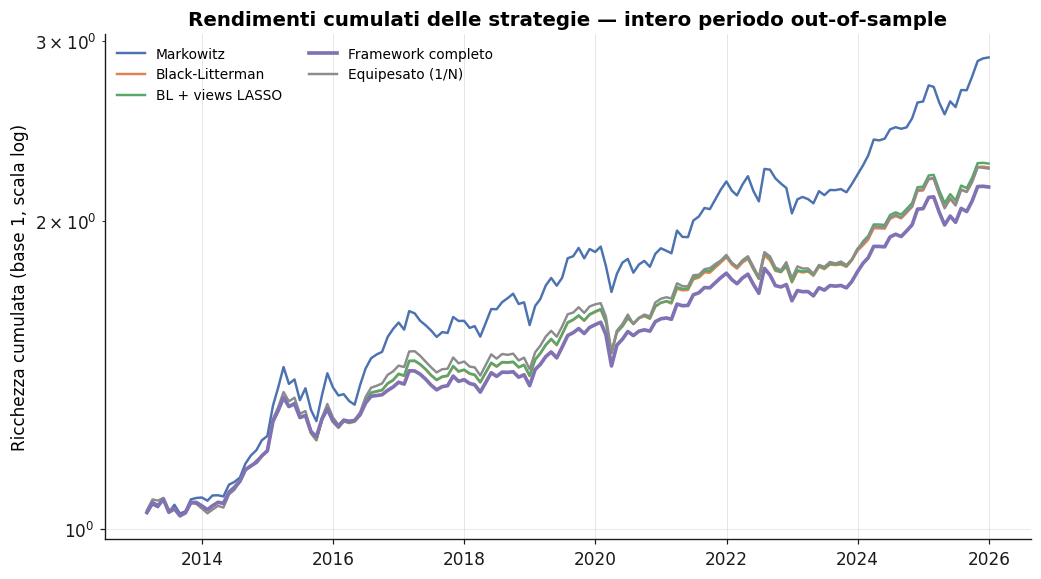

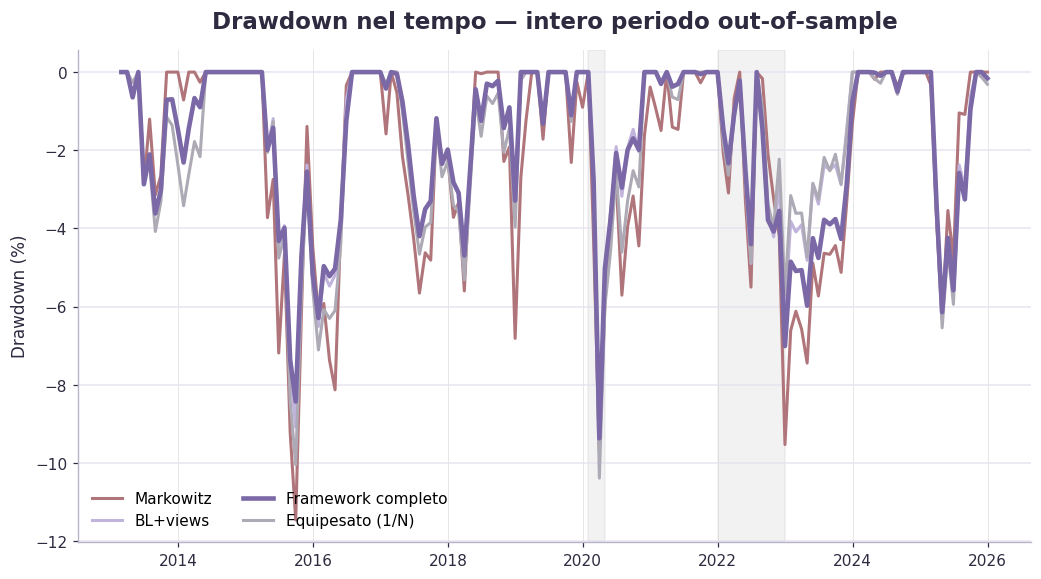

In [21]:
# =============================================================================
# RENDIMENTI CUMULATI — confronto strategie sull'intero periodo out-of-sample
# =============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from plots import PALETTE, LABELS, apply_theme

apply_theme()

STRATS = ["markowitz", "bl_classic", "bl_views", "full", "equal_weight"]
wealth = {s: (1.0 + bt.results[s].returns.dropna()).cumprod() for s in STRATS}

fig, ax = plt.subplots(figsize=(9.6, 5.4))
for s in STRATS:
    ax.plot(wealth[s].index, wealth[s].values,
            lw=2.4 if s == "full" else 1.6,
            color=PALETTE.get(s, PALETTE["ink"]),
            label=LABELS.get(s, s),
            zorder=5 if s == "full" else 3)
ax.set_yscale("log")
ax.set_ylabel("Ricchezza cumulata (base 1, scala log)")
ax.set_title("Rendimenti cumulati delle strategie — intero periodo out-of-sample")
ax.legend(loc="upper left", ncol=2, fontsize=9)
ax.grid(True, axis="y", color=PALETTE["grid"], lw=0.6, alpha=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
save_fig(fig, "fig_04_01_equity_lines")
plt.show()

# =============================================================================
# DRAWDOWN NEL TEMPO — profondità e durata delle fasi di perdita
# =============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

PALETTE = {
    "markowitz":    "#B0757A",
    "bl_views":     "#C0B3DC",
    "full":         "#7B68A6",
    "equal_weight": "#ADAAB5",
    "ink":          "#2E2A3F",
    "grid":         "#E7E2F0",
}
LABELS = {
    "markowitz": "Markowitz", "bl_views": "BL+views",
    "full": "Framework completo", "equal_weight": "Equipesato (1/N)",
}
STRATS = ["markowitz", "bl_views", "full", "equal_weight"]

def drawdown_series(r):
    wealth = (1.0 + r.dropna()).cumprod()
    return wealth / wealth.cummax() - 1.0

dd = {s: drawdown_series(bt.results[s].returns) for s in STRATS}

fig, ax = plt.subplots(figsize=(9.6, 5.4))
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-30"),
           color=PALETTE["ink"], alpha=0.06, zorder=0)
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
           color=PALETTE["ink"], alpha=0.06, zorder=0)
for s in STRATS:
    ax.plot(dd[s].index, dd[s].values * 100,
            lw=3.0 if s == "full" else 2.0,
            color=PALETTE[s], label=LABELS[s],
            zorder=5 if s == "full" else 3)
ax.set_ylabel("Drawdown (%)", fontsize=11, color=PALETTE["ink"])
ax.set_title("Drawdown nel tempo — intero periodo out-of-sample", fontsize=15,
              fontweight="bold", color=PALETTE["ink"], pad=14)
ax.legend(loc="lower left", ncol=2, fontsize=10, frameon=False)
ax.grid(True, axis="y", color=PALETTE["grid"], lw=1.0, alpha=0.9)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#B9B3C9")
ax.spines["bottom"].set_color("#B9B3C9")
ax.tick_params(colors=PALETTE["ink"], labelsize=10)
fig.tight_layout()
save_fig(fig, "fig_04_02_drawdown")
plt.show()

In [22]:
%%writefile diagnostics.py
# =============================================================================
# DIAGNOSTICS.PY — Blocco 9 · Diagnostica statistica del confronto tra strategie
# =============================================================================
from __future__ import annotations
import logging
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
from config import Config, CONFIG

logger = logging.getLogger(__name__)
_MONTHS_PER_YEAR = 12
_SEED = 42

# Finestre di crisi per l'analisi per sottoperiodi
CRISIS_WINDOWS: Dict[str, Tuple[str, str]] = {
    "COVID 2020": ("2020-02-01", "2020-04-30"),
    "Inflazione/tassi 2022": ("2022-01-01", "2022-12-31"),
}

# ---------------------------------------------------------------------------
# Test di Ledoit-Wolf (2008) sulla differenza di Sharpe
# ---------------------------------------------------------------------------
@dataclass
class SharpeTestResult:
    name_1: str
    name_2: str
    sharpe_1: float          # annualizzato
    sharpe_2: float
    diff: float              # sharpe_1 - sharpe_2 (annualizzato)
    se: float                # errore standard HAC della differenza (annualizzato)
    p_hac: float             # p-value asintotico
    p_bootstrap: float       # p-value bootstrap studentizzato
    n_obs: int

def _hac_covariance(V: np.ndarray, lag: Optional[int] = None) -> np.ndarray:
    # Covarianza HAC (Newey-West) con kernel di Bartlett e lag automatico
    T, k = V.shape
    if lag is None:
        lag = int(np.floor(4.0 * (T / 100.0) ** (2.0 / 9.0)))
    lag = max(0, min(lag, T - 1))
    S = (V.T @ V) / T                                   # autocovarianza di ordine 0
    for j in range(1, lag + 1):
        w = 1.0 - j / (lag + 1.0)                   
        G = (V[j:].T @ V[:-j]) / T
        S += w * (G + G.T)
    return S

def _sharpe_stats(r1: np.ndarray, r2: np.ndarray) -> Tuple[float, float, float, float]:
    # Sharpe delle due serie, differenza e suo errore standard HAC
    T = len(r1)
    a, b = float(r1.mean()), float(r2.mean())
    c, d = float((r1 ** 2).mean()), float((r2 ** 2).mean())
    var1, var2 = c - a ** 2, d - b ** 2
    if var1 <= 0 or var2 <= 0:
        return np.nan, np.nan, np.nan, np.nan
    s1, s2 = np.sqrt(var1), np.sqrt(var2)
    sr1, sr2 = a / s1, b / s2
    diff = sr1 - sr2

    # Gradiente di f rispetto a (a, b, c, d)
    grad = np.array([
        c / var1 ** 1.5,
        -d / var2 ** 1.5,
        -a / (2.0 * var1 ** 1.5),
        b / (2.0 * var2 ** 1.5),
    ])
    V = np.column_stack([r1 - a, r2 - b, r1 ** 2 - c, r2 ** 2 - d])
    Psi = _hac_covariance(V)
    var_diff = float(grad @ Psi @ grad) / T
    se = np.sqrt(var_diff) if var_diff > 0 else np.nan
    return sr1, sr2, diff, se

def _circular_block_bootstrap_idx(T: int, block: int, rng: np.random.Generator) -> np.ndarray:
    # Indici di un ricampionamento circolare a blocchi
    n_blocks = int(np.ceil(T / block))
    starts = rng.integers(0, T, size=n_blocks)
    idx = np.concatenate([(np.arange(s, s + block) % T) for s in starts])
    return idx[:T]

def sharpe_difference_test(r1: pd.Series, r2: pd.Series, name_1: str = "1",
                           name_2: str = "2", n_boot: int = 4999,
                           block: int = 5, seed: int = _SEED,
                           rf: "pd.Series | float | None" = None) -> SharpeTestResult:
    common = r1.index.intersection(r2.index)
    x = r1.reindex(common).to_numpy(dtype=float)
    y = r2.reindex(common).to_numpy(dtype=float)
    # Rendimenti in ECCESSO su rf
    if rf is not None:
        rf_v = (rf.reindex(common).fillna(0.0).to_numpy(dtype=float)
                if isinstance(rf, pd.Series) else float(rf))
        x = x - rf_v
        y = y - rf_v
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    T = len(x)
    sr1, sr2, diff, se = _sharpe_stats(x, y)
    if not np.isfinite(se) or se <= 0:
        return SharpeTestResult(name_1, name_2, np.nan, np.nan, np.nan, np.nan,
                                np.nan, np.nan, T)
    from scipy import stats as _st
    t_obs = diff / se
    p_hac = float(2.0 * (1.0 - _st.norm.cdf(abs(t_obs))))

    # --- Bootstrap circolare a blocchi, studentizzato ---------------------
    rng = np.random.default_rng(seed)
    count = 0
    valid = 0
    for _ in range(n_boot):
        idx = _circular_block_bootstrap_idx(T, block, rng)
        xb, yb = x[idx], y[idx]
        _, _, diff_b, se_b = _sharpe_stats(xb, yb)
        if not np.isfinite(se_b) or se_b <= 0:
            continue
        valid += 1
        # Statistica centrata sulla stima campionaria (H0 imposta nel bootstrap)
        if abs((diff_b - diff) / se_b) >= abs(t_obs):
            count += 1
    p_boot = (count + 1) / (valid + 1) if valid > 0 else np.nan
    k = np.sqrt(_MONTHS_PER_YEAR)                    
    return SharpeTestResult(name_1=name_1, name_2=name_2,
                            sharpe_1=sr1 * k, sharpe_2=sr2 * k,
                            diff=diff * k, se=se * k,
                            p_hac=p_hac, p_bootstrap=p_boot, n_obs=T)

# ---------------------------------------------------------------------------
# Probabilistic Sharpe Ratio
# ---------------------------------------------------------------------------
def probabilistic_sharpe_ratio(returns, sr_benchmark: float = 0.0) -> Tuple[float, float]:
    # Probabilità che lo Sharpe vero superi il benchmark, corretta per skew/kurtosi
    from scipy import stats as _st
    r = np.asarray(returns, float); r = r[np.isfinite(r)]
    n = len(r)
    if n < 3:
        return np.nan, np.nan
    mu, sd = r.mean(), r.std(ddof=1)
    if sd <= 0:
        return np.nan, np.nan
    sr = mu / sd                                       # Sharpe mensile
    g = _st.skew(r, bias=False)
    kurt = _st.kurtosis(r, fisher=False, bias=False)   # kurtosis NON in eccesso
    var_sr = (1.0 - g*sr + (kurt - 1.0)/4.0 * sr**2) / (n - 1.0)
    if not np.isfinite(var_sr) or var_sr <= 0:
        return sr*np.sqrt(_MONTHS_PER_YEAR), np.nan
    sr_b = sr_benchmark / np.sqrt(_MONTHS_PER_YEAR)
    psr = float(_st.norm.cdf((sr - sr_b) / np.sqrt(var_sr)))
    return sr*np.sqrt(_MONTHS_PER_YEAR), psr

# ---------------------------------------------------------------------------
# Rischio di coda: VaR, Expected Shortfall, Modified VaR
# ---------------------------------------------------------------------------
def var_historical(returns, alpha: float = 0.99) -> float:
    # VaR storico (quantile empirico della coda sinistra)
    r = np.asarray(returns, float); r = r[np.isfinite(r)]
    if len(r) < 5:
        return np.nan
    return float(-np.quantile(r, 1.0 - alpha))

def expected_shortfall(returns, alpha: float = 0.975) -> float:
    # Perdita attesa condizionata a superare il VaR (media della coda)
    r = np.asarray(returns, float); r = r[np.isfinite(r)]
    if len(r) < 5:
        return np.nan
    q = np.quantile(r, 1.0 - alpha)
    tail = r[r <= q]
    return float(-tail.mean()) if len(tail) else np.nan

def var_modified(returns, alpha: float = 0.99) -> float:
    # VaR di Cornish-Fisher: corregge il VaR normale per skew e kurtosi
    from scipy import stats as _st
    r = np.asarray(returns, float); r = r[np.isfinite(r)]
    if len(r) < 5:
        return np.nan
    mu, sd = r.mean(), r.std(ddof=1)
    S = _st.skew(r, bias=False)
    K = _st.kurtosis(r, fisher=True, bias=False)        # kurtosi in eccesso
    z = _st.norm.ppf(1.0 - alpha)
    zcf = (z + (z**2 - 1)*S/6.0 + (z**3 - 3*z)*K/24.0 - (2*z**3 - 5*z)*S**2/36.0)
    return float(-(mu + sd*zcf))

# ---------------------------------------------------------------------------
# Distribuzione del drawdown via block bootstrap
# ---------------------------------------------------------------------------
def _max_dd_and_tuw(r: np.ndarray) -> Tuple[float, int]:
    # Max drawdown e Time-under-Water (mesi consecutivi sotto il picco)
    w = np.cumprod(1.0 + r)
    dd = w / np.maximum.accumulate(w) - 1.0
    mdd = float(dd.min())
    under = dd < 0
    longest = cur = 0
    for u in under:
        cur = cur + 1 if u else 0
        longest = max(longest, cur)
    return mdd, longest

def drawdown_distribution(returns, n_boot: int = 2000, block: int = 5,
                          seed: int = _SEED) -> Dict[str, float]:
    # Distribuzione bootstrap di MDD e TuW e percentile del valore osservato
    r = np.asarray(returns, float); r = r[np.isfinite(r)]
    T = len(r)
    if T < 12:
        return {}
    mdd_obs, tuw_obs = _max_dd_and_tuw(r)
    rng = np.random.default_rng(seed)
    mdds = np.empty(n_boot); tuws = np.empty(n_boot)
    for b in range(n_boot):
        rb = r[_circular_block_bootstrap_idx(T, block, rng)]
        mdds[b], tuws[b] = _max_dd_and_tuw(rb)
    p = lambda a, q: float(np.percentile(a, q))
    return {
        "mdd_obs": mdd_obs * 100,
        "mdd_median": p(mdds, 50) * 100,
        "mdd_p05": p(mdds, 5) * 100,       
        "mdd_p95": p(mdds, 95) * 100,       
        "tuw_obs": float(tuw_obs),
        "tuw_median": p(tuws, 50),
        "tuw_p95": p(tuws, 95),
        "obs_percentile": float((mdds <= mdd_obs).mean()) * 100,
    }

# ---------------------------------------------------------------------------
# Contenitore e orchestrazione della diagnostica
# ---------------------------------------------------------------------------
@dataclass
class DiagnosticsBook:
    sharpe_tests: pd.DataFrame = field(default_factory=pd.DataFrame)
    subperiods: pd.DataFrame = field(default_factory=pd.DataFrame)
    by_regime: pd.DataFrame = field(default_factory=pd.DataFrame)
    crisis: pd.DataFrame = field(default_factory=pd.DataFrame)
    psr: pd.DataFrame = field(default_factory=pd.DataFrame)
    tail_risk: pd.DataFrame = field(default_factory=pd.DataFrame)
    drawdown_dist: pd.DataFrame = field(default_factory=pd.DataFrame)
    stress_tail: pd.DataFrame = field(default_factory=pd.DataFrame)
    recovery: pd.DataFrame = field(default_factory=pd.DataFrame)

class PerformanceDiagnostics:
    def __init__(self, config: Config = CONFIG) -> None:
        self.cfg = config

    # ---- Metriche su un sottoinsieme di mesi ------------------------------
    @staticmethod
    def _stats(r: pd.Series, rf: pd.Series) -> Dict[str, float]:
        # Rendimento/vol annualizzati, Sharpe in eccesso e max drawdown su r
        if len(r) < 2:
            return {"ann_return": np.nan, "ann_vol": np.nan, "sharpe": np.nan,
                    "max_dd": np.nan, "n_months": len(r)}
        ex = r - rf.reindex(r.index).fillna(0.0)
        n = len(r)
        cum = float((1.0 + r).prod())
        wealth = (1.0 + r).cumprod()
        sd = float(ex.std(ddof=1))
        return {
            "ann_return": cum ** (_MONTHS_PER_YEAR / n) - 1.0,
            "ann_vol": float(r.std(ddof=1)) * np.sqrt(_MONTHS_PER_YEAR),
            "sharpe": (float(ex.mean()) / sd * np.sqrt(_MONTHS_PER_YEAR)) if sd > 0 else np.nan,
            "max_dd": float((wealth / wealth.cummax() - 1.0).min()),
            "n_months": n,
        }

    # ---- 1b. Probabilistic Sharpe Ratio (affidabilita' del singolo Sharpe) ---
    def psr_table(self, book, rf: pd.Series, sr_benchmarks=(0.0, 0.5)) -> pd.DataFrame:
        from scipy import stats as _st
        rows = []
        for name, res in book.results.items():
            r = res.returns
            ex = r - rf.reindex(r.index).fillna(0.0)
            sr_ann, _ = probabilistic_sharpe_ratio(ex, 0.0)
            row = {"strategia": name, "sharpe": sr_ann,
                   "skew": float(_st.skew(ex.dropna(), bias=False)),
                   "kurtosi": float(_st.kurtosis(ex.dropna(), fisher=True, bias=False)),
                   "n_mesi": int(ex.notna().sum())}
            for b in sr_benchmarks:
                _, psr = probabilistic_sharpe_ratio(ex, b)
                row[f"PSR(>{b:g})"] = psr
            rows.append(row)
        return pd.DataFrame(rows).set_index("strategia") if rows else pd.DataFrame()

    # ---- 1c. Rischio di coda: VaR 99%, ES 97.5%, Modified VaR ------
    def tail_risk_table(self, book) -> pd.DataFrame:
        rows = []
        for name, res in book.results.items():
            r = res.returns.dropna()
            vh = var_historical(r, 0.99)
            es = expected_shortfall(r, 0.975)
            vm = var_modified(r, 0.99)
            rows.append({"strategia": name,
                         "VaR99_hist": vh * 100 if np.isfinite(vh) else np.nan,
                         "ES97.5": es * 100 if np.isfinite(es) else np.nan,
                         "VaR99_mod": vm * 100 if np.isfinite(vm) else np.nan,
                         "coda(mod-hist)": (vm - vh) * 100 if np.isfinite(vm) and np.isfinite(vh) else np.nan})
        return pd.DataFrame(rows).set_index("strategia") if rows else pd.DataFrame()

    # ---- 1d. Distribuzione bootstrap del drawdown ---------------------------
    def drawdown_dist_table(self, book, n_boot: int = 2000) -> pd.DataFrame:
        rows = []
        for name, res in book.results.items():
            d = drawdown_distribution(res.returns.dropna(), n_boot=n_boot)
            if not d:
                continue
            rows.append({"strategia": name,
                         "MDD_oss": d["mdd_obs"], "MDD_mediana": d["mdd_median"],
                         "MDD_p05(peggio)": d["mdd_p05"], "MDD_p95(meglio)": d["mdd_p95"],
                         "TuW_oss(mesi)": d["tuw_obs"], "TuW_p95": d["tuw_p95"],
                         "pctile_oss": d["obs_percentile"]})
        return pd.DataFrame(rows).set_index("strategia") if rows else pd.DataFrame()

    # ---- 1. Test di significativita' --------------------------------------
    def sharpe_tests(self, book, rf: pd.Series, pairs: List[Tuple[str, str]],
                     n_boot: int = 4999) -> pd.DataFrame:
        # Test sulla differenza di Sharpe per ogni coppia (su rendimenti in eccesso)
        rows = []
        for a, b in pairs:
            if a not in book.results or b not in book.results:
                continue
            ra = book.results[a].returns
            rb = book.results[b].returns
            ex_a = ra - rf.reindex(ra.index).fillna(0.0)
            ex_b = rb - rf.reindex(rb.index).fillna(0.0)
            res = sharpe_difference_test(ex_a, ex_b, a, b, n_boot=n_boot)
            rows.append({
                "strategia_1": res.name_1, "strategia_2": res.name_2,
                "sharpe_1": res.sharpe_1, "sharpe_2": res.sharpe_2,
                "differenza": res.diff, "se": res.se,
                "p_hac": res.p_hac, "p_bootstrap": res.p_bootstrap,
                "n_obs": res.n_obs,
            })
        return pd.DataFrame(rows)

    # ---- 2. Sottoperiodi ---------------------------------------------------
    def subperiods(self, book, rf: pd.Series) -> pd.DataFrame:
        # Rendimento annualizzato per anno solare e strategia
        rows = {}
        for name, res in book.results.items():
            r = res.returns
            for year, grp in r.groupby(r.index.year):
                rows.setdefault(name, {})[str(year)] = self._stats(grp, rf)["ann_return"]
        df = pd.DataFrame(rows).T
        return df.reindex(columns=sorted(df.columns))

    def crisis_windows(self, book, rf: pd.Series,
                       windows: Optional[Dict[str, Tuple[str, str]]] = None) -> pd.DataFrame:
        # Rendimento cumulato e max drawdown in ciascuna finestra di crisi
        windows = windows or CRISIS_WINDOWS
        rows = {}
        for name, res in book.results.items():
            r = res.returns
            for label, (lo, hi) in windows.items():
                sub = r.loc[(r.index >= lo) & (r.index <= hi)]
                if sub.empty:
                    continue
                cum = float((1.0 + sub).prod() - 1.0) 
                dd = float(((1 + sub).cumprod() / (1 + sub).cumprod().cummax() - 1).min())
                rows.setdefault(name, {})[f"{label} rend."] = cum
                rows.setdefault(name, {})[f"{label} maxDD"] = dd
        return pd.DataFrame(rows).T

    # ---- 3. Condizionamento ai regimi -------------------------------------
    def by_regime(self, book, rf: pd.Series, regime_book) -> pd.DataFrame:
        # Metriche separate per regime, allineando il regime deciso a t col rendimento t+1
        regimes = regime_book.regimes
        rows = []
        for name, res in book.results.items():
            r = res.returns                              
            # regime deciso a t -> shift in avanti di un mese
            reg_shift = regimes.copy()
            reg_shift.index = pd.Index([d for d in regimes.index])
            mapping = {}
            months = list(r.index)
            for t_dec, reg in regimes.items():
                nxt = [m for m in months if m > t_dec]
                if nxt:
                    mapping[nxt[0]] = reg
            reg_aligned = pd.Series(mapping).reindex(r.index)
            for reg in ("normal", "stress"):
                sub = r[reg_aligned == reg]
                if len(sub) < 2:
                    continue
                st = self._stats(sub, rf)
                rows.append({"strategia": name, "regime": reg, **st})
        return pd.DataFrame(rows).set_index(["strategia", "regime"]) if rows else pd.DataFrame()

    # ---- 4. Analisi di coda condizionata al regime di stress --------------
    def stress_tail(self, book, rf: pd.Series, regime_book,
        alpha_var: float = 0.05, alpha_es: float = 0.025) -> pd.DataFrame:
        # Metriche di coda calcolate SOLO sui mesi di stress (regime deciso a t
        # allineato col rendimento t+1). Serve a documentare il beneficio del
        # de-risking la' dove dovrebbe manifestarsi: perdita massima, coda
        # sinistra (VaR/CVaR storici) e mese peggiore.
        # VaR storico al 95% ed Expected Shortfall (CVaR) al 97,5%, coerenti
        # con le soglie adottate in tail_risk_table (§4.2).
        regimes = regime_book.regimes
        rows = []
        for name, res in book.results.items():
            r = res.returns
            # allineamento regime(t) -> rendimento(t+1), come in by_regime
            months = list(r.index)
            mapping = {}
            for t_dec, reg in regimes.items():
                nxt = [m for m in months if m > t_dec]
                if nxt:
                    mapping[nxt[0]] = reg
            reg_aligned = pd.Series(mapping).reindex(r.index)
            sub = r[reg_aligned == "stress"].dropna()
            if len(sub) < 3:
                continue
            wealth = (1.0 + sub).cumprod()
            var = float(np.quantile(sub.values, alpha_var))       # VaR storico al 95%
            es_thresh = float(np.quantile(sub.values, alpha_es))  # soglia al 97,5% per l'ES
            tail_es = sub[sub <= es_thresh]
            cvar = float(tail_es.mean()) if len(tail_es) else es_thresh  # Expected Shortfall al 97,5%
            ex = sub - rf.reindex(sub.index).fillna(0.0)
            sd = float(ex.std(ddof=1))
            rows.append({
                "strategia": name,
                "n_stress": int(len(sub)),
                "rend_medio": float(sub.mean()),
                "sharpe_stress": (float(ex.mean()) / sd * np.sqrt(_MONTHS_PER_YEAR)) if sd > 0 else np.nan,
                "max_dd_stress": float((wealth / wealth.cummax() - 1.0).min()),
                f"VaR_{int((1-alpha_var)*100)}": var,
                f"CVaR_{int((1-alpha_es)*100)}": cvar,
                "mese_peggiore": float(sub.min()),
                "hit_rate": float((sub > 0).mean()),
            })
        return pd.DataFrame(rows).set_index("strategia") if rows else pd.DataFrame()

    # ---- 5. Tempo di recupero dopo il drawdown massimo --------------------
    def recovery_analysis(self, book) -> pd.DataFrame:
        # Per ciascuna strategia: profondita' del max drawdown, durata della
        # discesa (picco->valle) e tempo di recupero (valle->nuovo massimo).
        # Il de-risking dovrebbe accorciare discesa e recupero: qui si verifica.
        rows = []
        for name, res in book.results.items():
            r = res.returns.dropna()
            if len(r) < 3:
                continue
            wealth = (1.0 + r).cumprod()
            peak = wealth.cummax()
            dd = wealth / peak - 1.0
            trough = dd.idxmin()                       # data del minimo
            depth = float(dd.min())
            # picco che precede il valle
            pk_val = float(peak.loc[trough])
            pre = wealth.loc[:trough]
            peak_date = pre[pre >= pk_val - 1e-12].index[0]
            # recupero: primo mese dopo il valle in cui si torna al picco
            post = wealth.loc[trough:]
            rec = post[post >= pk_val - 1e-12]
            rec_date = rec.index[0] if len(rec) else None
            months_to_trough = sum(1 for m in wealth.index if peak_date < m <= trough)
            months_to_recover = (sum(1 for m in wealth.index if trough < m <= rec_date)
                                 if rec_date is not None else np.nan)
            rows.append({
                "strategia": name,
                "max_dd": depth,
                "data_picco": peak_date.strftime("%Y-%m"),
                "data_valle": trough.strftime("%Y-%m"),
                "mesi_discesa": int(months_to_trough),
                "mesi_recupero": (int(months_to_recover)
                                  if months_to_recover == months_to_recover else np.nan),
                "recuperato": rec_date is not None,
            })
        return pd.DataFrame(rows).set_index("strategia") if rows else pd.DataFrame()

    # ---- Esecuzione completa ----------------------------------------------
    def run(self, book, md, regime_book, pairs: Optional[List[Tuple[str, str]]] = None,
            n_boot: int = 4999) -> DiagnosticsBook:
        # Costruisce rf da XEON ed esegue tutte le diagnostiche in un unico book
        from config import RISK_FREE_TICKER
        px = md.prices_eur.resample("ME").last()
        simple = px.pct_change()
        rf = (simple[RISK_FREE_TICKER] if RISK_FREE_TICKER in simple.columns
              else pd.Series(0.0, index=simple.index))
        pairs = pairs or [
            # Confronto A — ogni gradino della scala di attribuzione
            ("bl_classic", "markowitz"),
            ("bl_views", "bl_classic"),
            ("full", "bl_views"),
            # Confronto B — framework vs benchmark
            ("full", "equal_weight"),
            ("full", "markowitz"),
            ("full", "bl_classic"),
        ]
        return DiagnosticsBook(
            sharpe_tests=self.sharpe_tests(book, rf, pairs, n_boot=n_boot),
            subperiods=self.subperiods(book, rf),
            crisis=self.crisis_windows(book, rf),
            by_regime=self.by_regime(book, rf, regime_book),
            psr=self.psr_table(book, rf),
            tail_risk=self.tail_risk_table(book),
            drawdown_dist=self.drawdown_dist_table(book, n_boot=n_boot),
            stress_tail=self.stress_tail(book, rf, regime_book),
            recovery=self.recovery_analysis(book),
        )

if __name__ == "__main__":
    import argparse
    from pathlib import Path
    from data_loader import DataLoader
    from feature_engineering import FeatureEngineer
    from lasso_views import LassoViewGenerator
    from black_litterman import BlackLittermanModel
    from regime_detection import RegimeDetector
    from backtest import Backtester
    logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", default="data")
    args = parser.parse_args()
    CONFIG.data.data_dir = Path(args.data_dir)
    CONFIG.data.fred_dir = Path(args.data_dir)
    md = DataLoader(CONFIG).load()
    fs = FeatureEngineer(CONFIG).build(md)
    vb = LassoViewGenerator(CONFIG).run(fs)
    bl = BlackLittermanModel(CONFIG).run(md, vb)
    rb = RegimeDetector(CONFIG).run(md, fs)
    bt = Backtester(CONFIG).run(md, bl, rb)
    dg = PerformanceDiagnostics(CONFIG).run(bt, md, rb)
    print("\n=== TEST DI LEDOIT-WOLF SULLE DIFFERENZE DI SHARPE ===")
    print(dg.sharpe_tests.round(4).to_string(index=False))
    print("\n=== PROBABILISTIC SHARPE RATIO (affidabilita' del singolo Sharpe) ===")
    print(dg.psr.round(3).to_string())
    print("\n=== RISCHIO DI CODA (mensile, %; VaR 99% / ES 97.5% - livelli FRTB) ===")
    print(dg.tail_risk.round(2).to_string())
    print("\n=== DISTRIBUZIONE DEL DRAWDOWN (block bootstrap, %) ===")
    print(dg.drawdown_dist.round(2).to_string())
    print("\n=== RENDIMENTI PER ANNO SOLARE (%) ===")
    print((dg.subperiods * 100).round(2).to_string())
    print("\n=== FINESTRE DI CRISI (%) ===")
    print((dg.crisis * 100).round(2).to_string())
    print("\n=== PERFORMANCE CONDIZIONATA AL REGIME ===")
    print(dg.by_regime.round(4).to_string())

Overwriting diagnostics.py


PERFORMANCE PER REGIME


Rend.  Vol.  Sharpe  MaxDD
strategia          regime                            
Markowitz          normal   7.67  7.71    0.89  -9.71
                   stress   6.26  9.86    0.66  -9.53
Black-Litterman    normal   5.17  6.18    0.72  -9.37
                   stress   5.20  7.11    0.74  -7.99
BL+views           normal   5.32  6.19    0.74  -9.37
                   stress   5.16  7.27    0.72  -7.99
Framework completo normal   5.31  6.19    0.74  -9.37
                   stress   3.83  6.58    0.59  -7.10
Equipesato (1/N)   normal   4.69  6.60    0.61 -10.39
                   stress   5.58  7.70    0.73  -8.89

TEST DI SIGNIFICATIVITA' (bootstrap a blocchi)


,Diff. Sharpe,p-value
Confronto,,
Black-Litterman vs Markowitz,-0.039,0.67
BL+views vs Black-Litterman,0.003,0.80
Framework completo vs BL+views,-0.035,0.19
Framework completo vs Equipesato (1/N),0.034,0.47
Framework completo vs Markowitz,-0.071,0.43
Framework completo vs Black-Litterman,-0.032,0.28


→ tutti i p-value >> 0.05: nessuna differenza è statisticamente distinguibile

RISCHIO DI CODA MENSILE


,VaR 99%,ES 97.5%,ModVaR 99%,coda(mod-hist)
strategia,,,,
Markowitz,5.26,5.25,5.24,-0.02
Black-Litterman,3.68,4.39,4.73,1.06
BL+views,3.69,4.40,4.75,1.06
Framework completo,3.55,4.32,4.70,1.15
Equipesato (1/N),3.98,4.81,5.25,1.27



FINESTRE DI CRISI


,COVID 2020 rend.,COVID 2020 maxDD,Inflazione/tassi 2022 rend.,Inflazione/tassi 2022 maxDD
Markowitz,-6.0,-5.7,-6.9,-9.5
Black-Litterman,-5.0,-6.8,-5.5,-5.9
BL+views,-5.0,-6.8,-5.5,-6.2
Framework completo,-5.0,-6.8,-6.0,-7.0
Equipesato (1/N),-6.0,-7.6,-5.1,-5.7


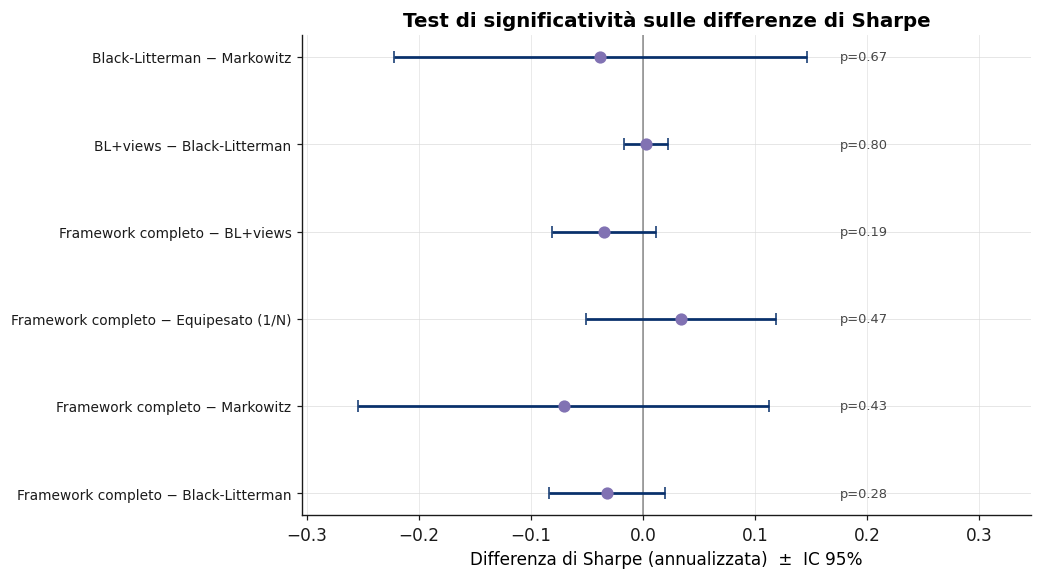

In [23]:
# =============================================================================
# DIAGNOSTICA STATISTICA — significatività e rischio Blocco 9
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from diagnostics import PerformanceDiagnostics
from plots import PALETTE, apply_theme

dg = PerformanceDiagnostics(CONFIG).run(bt, md, rb)

_ROWS = {"markowitz": "Markowitz", "bl_classic": "Black-Litterman", "bl_views": "BL+views",
         "full": "Framework completo", "equal_weight": "Equipesato (1/N)"}

# --- Performance per regime -------------------------------------------------
print("PERFORMANCE PER REGIME")
_reg = dg.by_regime.rename(index=_ROWS)[["ann_return", "ann_vol", "sharpe", "max_dd"]]
_reg.columns = ["Rend.", "Vol.", "Sharpe", "MaxDD"]
display(_reg.assign(**{c: _reg[c] * 100 for c in ["Rend.", "Vol.", "MaxDD"]}).round(2))

# --- Test di significatività --------------------------
_st = dg.sharpe_tests.copy()
_sig = pd.DataFrame({
    "Confronto": _st["strategia_1"].map(_ROWS) + " vs " + _st["strategia_2"].map(_ROWS),
    "Diff. Sharpe": _st["differenza"].round(3),
    "p-value": _st["p_bootstrap"].round(2),
}).set_index("Confronto")
print("TEST DI SIGNIFICATIVITA' (bootstrap a blocchi)")
display(_sig)
print("→ tutti i p-value >> 0.05: nessuna differenza è statisticamente distinguibile\n")

# --- Rischio di coda -------------------------------------------
print("RISCHIO DI CODA MENSILE")
_tail = dg.tail_risk.rename(index=_ROWS).rename(columns={
    "VaR99_hist": "VaR 99%", "ES97.5": "ES 97.5%", "VaR99_mod": "ModVaR 99%",
    "extra-coda": "extra-coda (ModVar-VaR)"})
display(_tail.round(2))

# --- Finestre di crisi ------------------------------------------------------
print("\nFINESTRE DI CRISI")
display((dg.crisis.rename(index=_ROWS) * 100).round(1))

# --- Figura 4 -------------------------
apply_theme()
_stf = dg.sharpe_tests.dropna(subset=["differenza", "se"]).reset_index(drop=True)
_labels = [f"{_ROWS.get(a, a)} − {_ROWS.get(b, b)}"
           for a, b in zip(_stf["strategia_1"], _stf["strategia_2"])]
_diff = _stf["differenza"].values
_ci = 1.96 * _stf["se"].values
_pb = _stf["p_bootstrap"].values
_y = np.arange(len(_stf))[::-1]

fig, ax = plt.subplots(figsize=(9.6, 5.4))
ax.axvline(0, color=PALETTE["ink"], lw=1.0, alpha=0.5, zorder=1)
ax.errorbar(_diff, _y, xerr=_ci, fmt="o", ms=7, color=PALETTE["full"],
            ecolor=PALETTE["accent"], elinewidth=1.8, capsize=4, zorder=3)
for _i, (_d, _p) in enumerate(zip(_diff, _pb)):
    ax.text(max(_diff + _ci) + 0.03, _y[_i], f"p={_p:.2f}", va="center",
            fontsize=8.5, color=PALETTE["ink"], alpha=0.8)
ax.set_yticks(_y); ax.set_yticklabels(_labels, fontsize=9)
ax.set_xlabel("Differenza di Sharpe (annualizzata)  ±  IC 95%")
ax.set_title("Test di significatività sulle differenze di Sharpe")
ax.set_xlim(min(_diff - _ci) - 0.05, max(_diff + _ci) + 0.20)
ax.grid(True, axis="x", color=PALETTE["grid"], lw=0.6, alpha=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
save_fig(fig, "fig_04_significativita_sharpe")
plt.show()

In [24]:
# =============================================================================
# CONFRONTO CON IL BENCHMARK MSCI ACWI
# =============================================================================
import numpy as np
import pandas as pd
from config import RISK_FREE_TICKER
 
_MPY = 12
_full_res = bt.results["full"]
_r_full = _full_res.returns
 
# rendimenti mensili del benchmark, allineati alle stesse date di rendimento
# realizzato usate per le strategie (stesso schema di data_loader/backtest:
# prezzo mensile di fine mese -> pct_change)
_bench_px = md.benchmark.resample("ME").last()
_bench = _bench_px.pct_change().reindex(_r_full.index).dropna()
_port = _r_full.reindex(_bench.index)
 
_rf_full = md.prices_eur.resample("ME").last().pct_change()[RISK_FREE_TICKER]
_rf = _rf_full.reindex(_bench.index).fillna(0.0)
 
def _metrics_simple(r: pd.Series, rf: pd.Series) -> dict:
    ann_ret = float((1.0 + r).prod()) ** (_MPY / len(r)) - 1.0
    ann_vol = float(r.std(ddof=1)) * np.sqrt(_MPY)
    ex = r - rf
    sharpe = (float(ex.mean()) / float(ex.std(ddof=1)) * np.sqrt(_MPY)
              if ex.std(ddof=1) > 0 else np.nan)
    wealth = (1.0 + r).cumprod()
    max_dd = float((wealth / wealth.cummax() - 1.0).min())
    return {"ann_return": ann_ret, "ann_vol": ann_vol, "sharpe": sharpe, "max_dd": max_dd}
 
# --- allineamento regime(t) -> rendimento(t+1), stesso schema di stress_tail
_months = list(_bench.index)
_mapping = {}
for t_dec, reg in rb.regimes.items():
    nxt = [m for m in _months if m > t_dec]
    if nxt:
        _mapping[nxt[0]] = reg
_reg_aligned = pd.Series(_mapping).reindex(_bench.index)
_stress = _reg_aligned == "stress"
 
def _max_dd(r: pd.Series) -> float:
    wealth = (1.0 + r).cumprod()
    return float((wealth / wealth.cummax() - 1.0).min())
 
_m_full = _metrics_simple(_port, _rf)
_m_bench = _metrics_simple(_bench, _rf)
 
# --- Tabella 4.8 -------------------------------------------------------------
_tab48 = pd.DataFrame({
    "Framework completo": {
        "Rend.%": _m_full["ann_return"] * 100, "Vol.%": _m_full["ann_vol"] * 100,
        "Sharpe": _m_full["sharpe"], "MaxDD%": _m_full["max_dd"] * 100,
        "MaxDD stress%": _max_dd(_port[_stress]) * 100,
    },
    "MSCI ACWI": {
        "Rend.%": _m_bench["ann_return"] * 100, "Vol.%": _m_bench["ann_vol"] * 100,
        "Sharpe": _m_bench["sharpe"], "MaxDD%": _m_bench["max_dd"] * 100,
        "MaxDD stress%": _max_dd(_bench[_stress]) * 100,
    },
}).T
print("FRAMEWORK vs MSCI ACWI")
display(_tab48.round(2))
 
# --- Tabella 4.9: beta, capture ratio, information ratio ---------------------
_cov = np.cov(_port.values, _bench.values, ddof=1)
_beta = _cov[0, 1] / _cov[1, 1]
 
_up, _down = _bench > 0, _bench < 0
_up_capture = float(_port[_up].mean() / _bench[_up].mean())
_down_capture = float(_port[_down].mean() / _bench[_down].mean())
 
_active = _port - _bench
_te = float(_active.std(ddof=1)) * np.sqrt(_MPY)
_ir = (float(_active.mean()) / float(_active.std(ddof=1)) * np.sqrt(_MPY)
       if _active.std(ddof=1) > 0 else np.nan)
 
_tab49 = pd.Series({
    "Beta": _beta,
    "Up-capture %": _up_capture * 100,
    "Down-capture %": _down_capture * 100,
    "Tracking error %": _te * 100,
    "Information ratio": _ir,
})
print("\nFRAMEWORK vs MSCI ACWI — metriche relative")
display(_tab49.round(3))

FRAMEWORK vs MSCI ACWI


,Rend.%,Vol.%,Sharpe,MaxDD%,MaxDD stress%
Framework completo,6.14,6.44,0.89,-9.37,-7.10
MSCI ACWI,13.04,13.67,0.93,-19.08,-12.37



FRAMEWORK vs MSCI ACWI — metriche relative


Beta                  0.420
Up-capture %         41.100
Down-capture %       35.601
Tracking error %      8.459
Information ratio    -0.834
dtype: float64

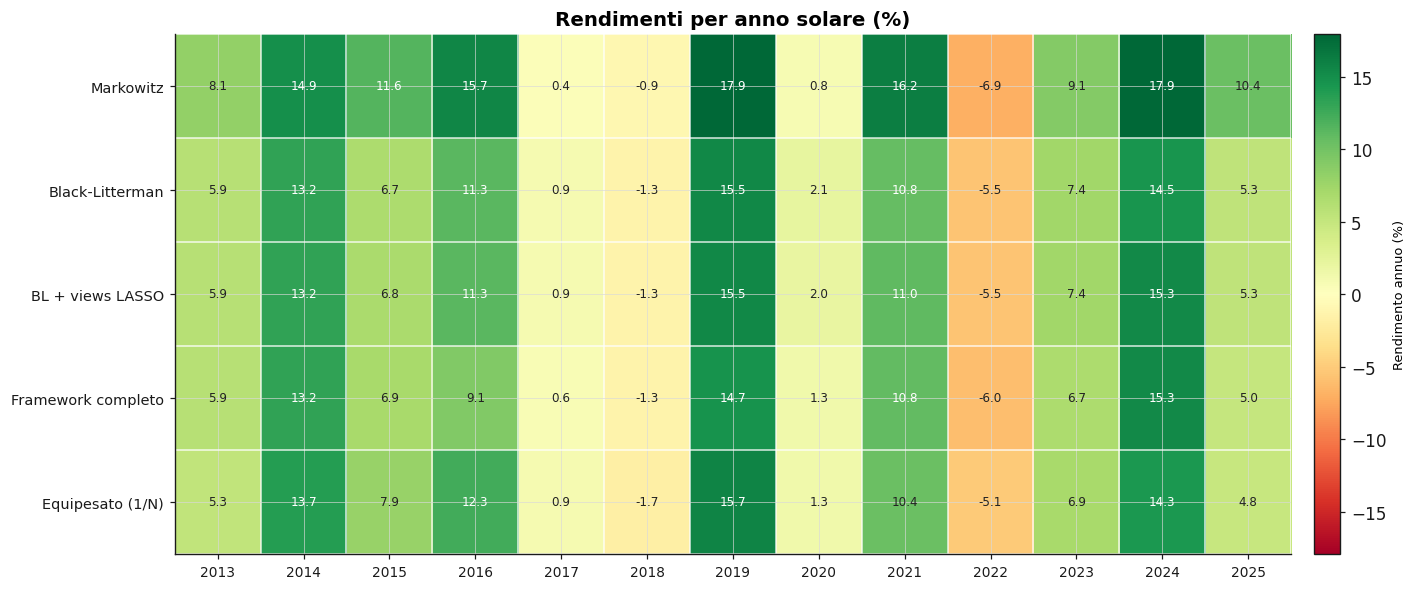

In [25]:
# =============================================================================
# RENDIMENTI ANNUALI — heatmap per strategia e anno Blocco 9
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from plots import LABELS, apply_theme

apply_theme()
_sub = dg.subperiods * 100   # in %
_order = [s for s in ["markowitz", "bl_classic", "bl_views", "full", "equal_weight"]
          if s in _sub.index]
_sub = _sub.loc[_order]
_vals = _sub.values.astype(float)
_vmax = np.nanmax(np.abs(_vals))
_norm = TwoSlopeNorm(vmin=-_vmax, vcenter=0.0, vmax=_vmax)

fig, ax = plt.subplots(figsize=(min(1.0 * _sub.shape[1] + 3, 13), 0.7 * _sub.shape[0] + 2))
_im = ax.imshow(_vals, cmap="RdYlGn", norm=_norm, aspect="auto")
ax.set_xticks(range(_sub.shape[1])); ax.set_xticklabels(_sub.columns, fontsize=9)
ax.set_yticks(range(_sub.shape[0]))
ax.set_yticklabels([LABELS.get(s, s) for s in _sub.index], fontsize=9.5)
for _i in range(_sub.shape[0]):
    for _j in range(_sub.shape[1]):
        _v = _vals[_i, _j]
        if np.isfinite(_v):
            ax.text(_j, _i, f"{_v:.1f}", ha="center", va="center", fontsize=7.8,
                    color="#222" if abs(_v) < 0.6 * _vmax else "white")
ax.set_title("Rendimenti per anno solare (%)")
_cbar = fig.colorbar(_im, ax=ax, fraction=0.025, pad=0.02)
_cbar.set_label("Rendimento annuo (%)", fontsize=8.5)
# griglia bianca tra le celle
ax.set_xticks(np.arange(-.5, _sub.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, _sub.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", lw=1.2)
ax.tick_params(which="minor", length=0)
fig.tight_layout()
save_fig(fig, "fig_05_rendimenti_annuali_heatmap")
plt.show()

In [26]:
# =============================================================================
# ROBUSTEZZA DEL REGIME — sensibilità alla modalità dei trigger Blocco 9
# =============================================================================
import copy
import pandas as pd
from regime_detection import RegimeDetector

_rows = []
for _mode in ("level", "delta", "mixed"):
    _cfg = copy.deepcopy(CONFIG)
    _cfg.regime.trigger_mode = _mode
    _rbm = RegimeDetector(_cfg).run(md, fs)
    _d = _rbm.diagnostics
    _p = _d.get("precision", float("nan"))
    _r = _d.get("recall", float("nan"))
    _f1 = (2 * _p * _r / (_p + _r)) if (_p + _r) > 0 else float("nan")
    _rows.append((_mode, int((_rbm.regimes == "stress").sum()),
                  _d.get("accuracy", float("nan")), _p, _r, _f1))

print("SENSIBILITÀ ALLA MODALITÀ DEI TRIGGER (regime detector)")
_sens = pd.DataFrame(
    _rows, columns=["modalità", "n. mesi stress", "accuracy", "precision", "recall", "F1"]
).set_index("modalità")
_sens = _sens.rename(index={"level": "level  ← scelta"})
display(_sens.round(3))

SENSIBILITÀ ALLA MODALITÀ DEI TRIGGER (regime detector)


,n. mesi stress,accuracy,precision,recall,F1
modalità,,,,,
level ← scelta,49,0.736,0.612,0.667,0.638
delta,9,0.744,0.222,0.071,0.108
mixed,40,0.690,0.475,0.500,0.487


In [27]:
diag = PerformanceDiagnostics(CONFIG)
simple = md.prices_eur.resample('ME').last().pct_change()
rf = simple["XEON.DE"]

print("Coda in stress (49 mesi):")
display(diag.stress_tail(bt, rf, rb).round(4))

print("\nRecupero dal max drawdown:")
display(diag.recovery_analysis(bt).round(4))

Coda in stress (49 mesi):


,n_stress,rend_medio,sharpe_stress,max_dd_stress,VaR_95,CVaR_97,mese_peggiore,hit_rate
strategia,,,,,,,,
markowitz,49,0.0055,0.6557,-0.0953,-0.0406,-0.0517,-0.0557,0.5510
bl_classic,49,0.0044,0.7360,-0.0799,-0.0314,-0.0369,-0.0386,0.6327
bl_views,49,0.0044,0.7159,-0.0799,-0.0314,-0.0370,-0.0386,0.6327
full,49,0.0033,0.5886,-0.0710,-0.0283,-0.0355,-0.0358,0.6122
equal_weight,49,0.0048,0.7323,-0.0889,-0.0331,-0.0397,-0.0439,0.6327



Recupero dal max drawdown:


,max_dd,data_picco,data_valle,mesi_discesa,mesi_recupero,recuperato
strategia,,,,,,
markowitz,-0.1145,2015-03,2015-09,6,10,True
bl_classic,-0.0937,2020-01,2020-03,2,8,True
bl_views,-0.0937,2020-01,2020-03,2,8,True
full,-0.0937,2020-01,2020-03,2,8,True
equal_weight,-0.1039,2020-01,2020-03,2,8,True


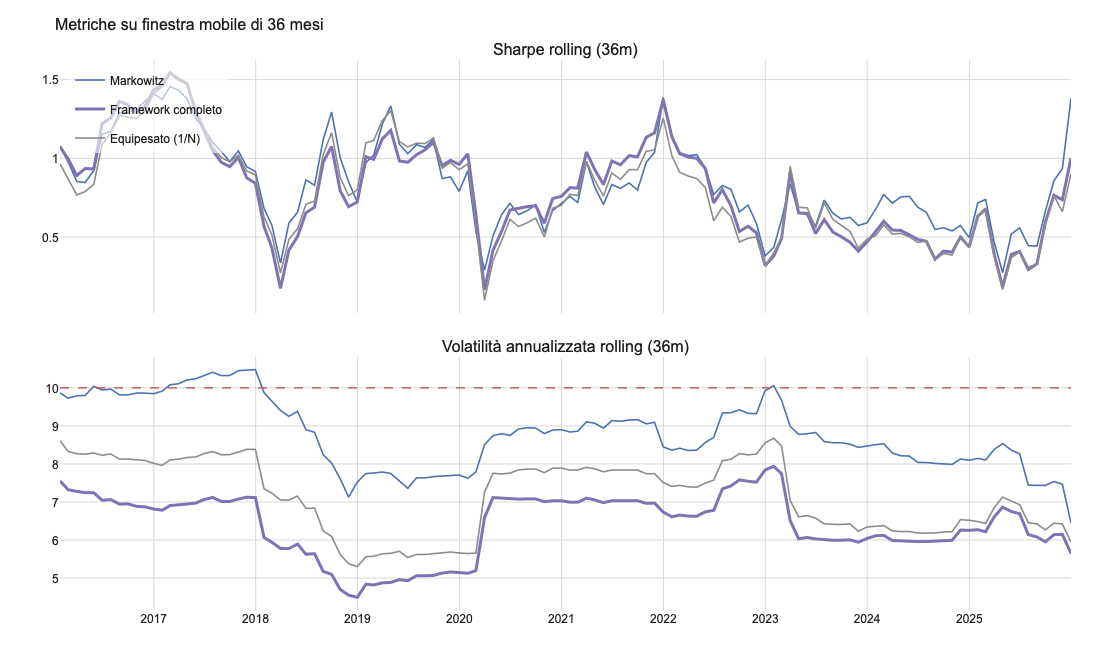

In [28]:
# =============================================================================
# GRAFICI INTERATTIVI — dashboard di visualizzazione
# =============================================================================
from plots import Charts
ch = Charts(bt, md=md, rb=rb, outdir="figures")
ch.rolling_metrics(interactive=True).show()

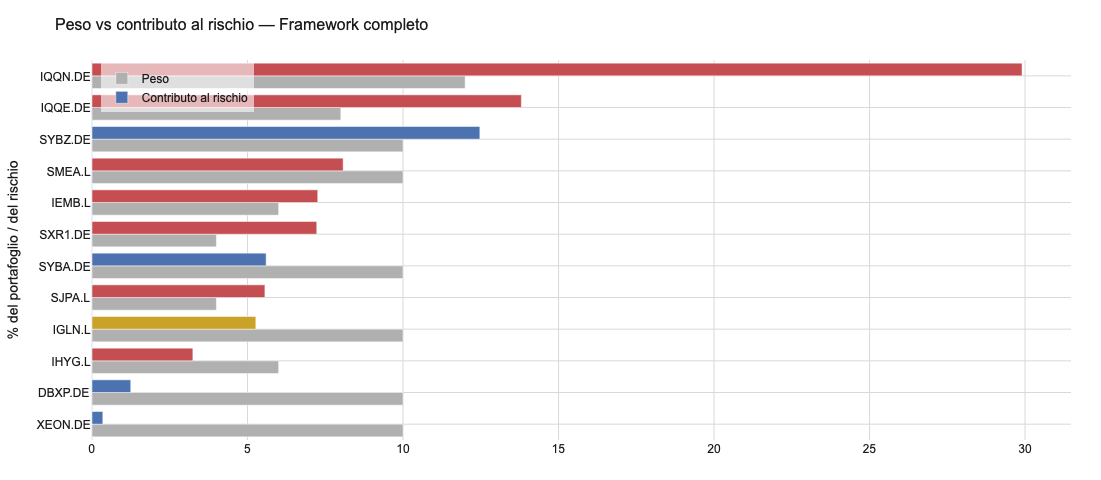

In [29]:
ch.risk_contribution(interactive=True).show()

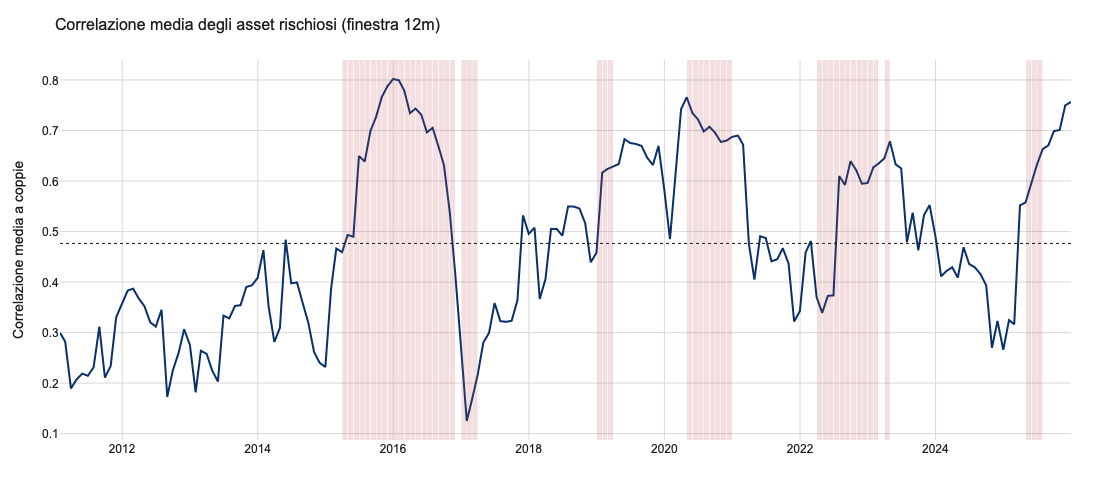

In [30]:
ch.rolling_correlation(interactive=True).show()

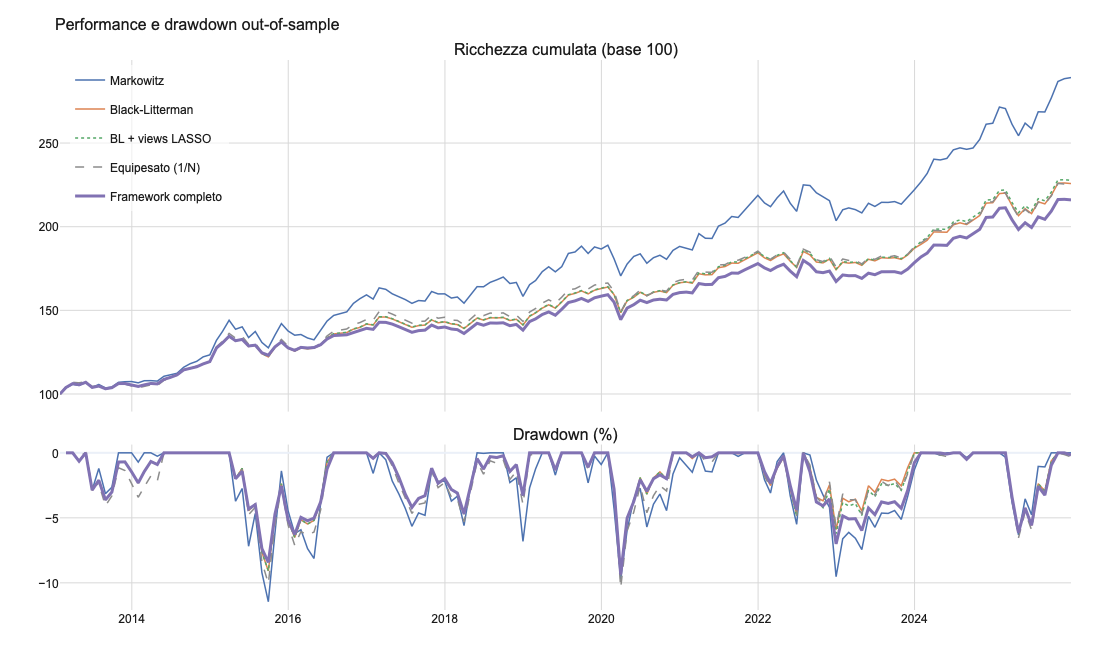

In [31]:
ch.performance_dashboard(interactive=True).show()

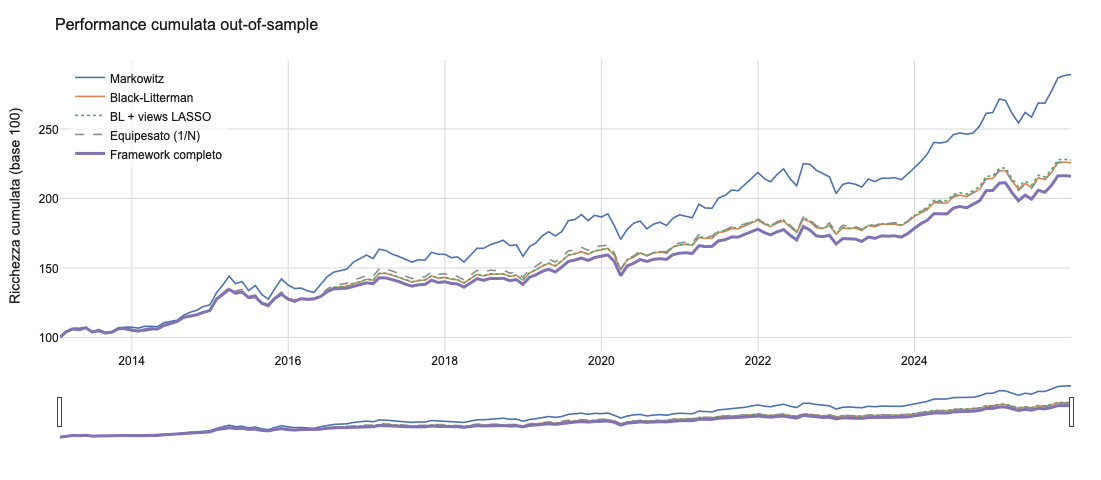

In [32]:
ch.equity_lines(interactive=True).show()

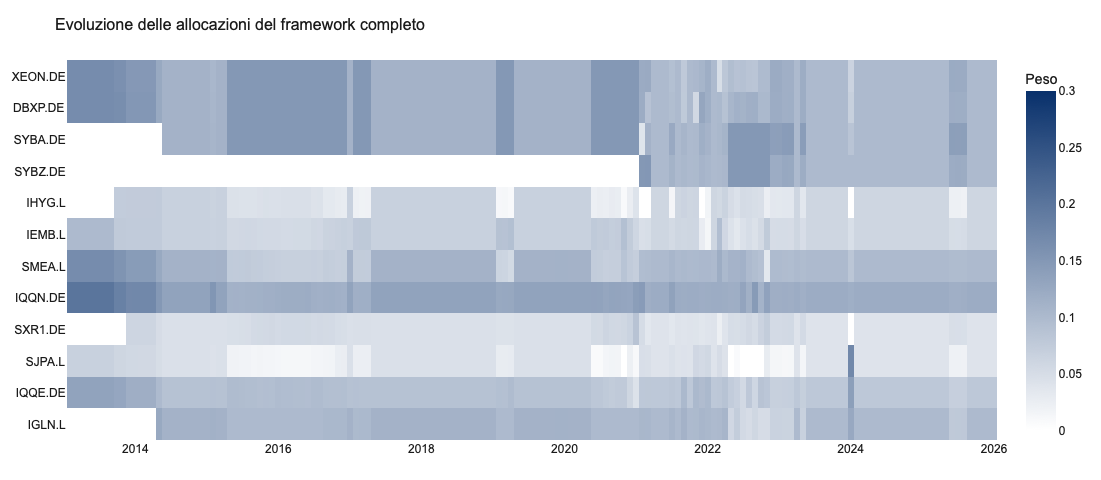

In [33]:
ch.allocations_heatmap(interactive=True).show()

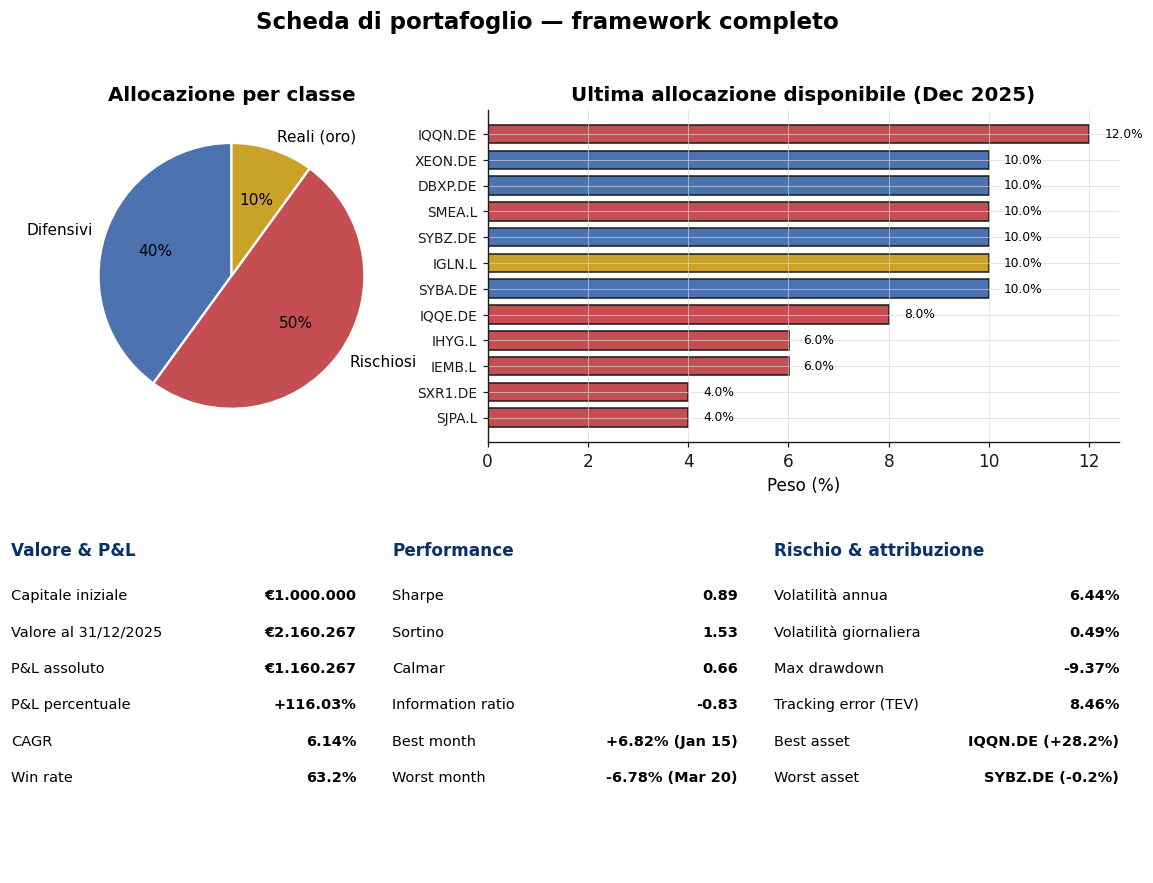

In [34]:
_ = ch.allocation_snapshot("full")

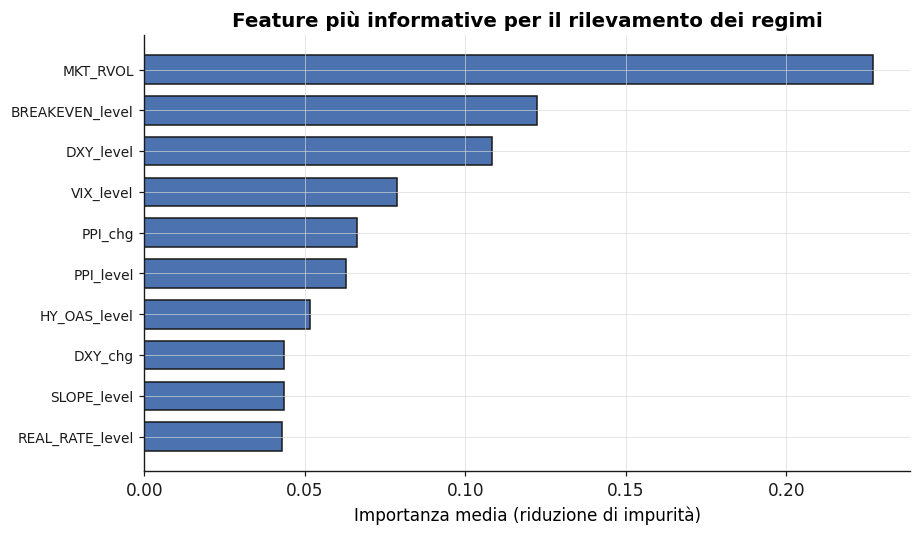

In [35]:
_ = ch.feature_importance(top=10)

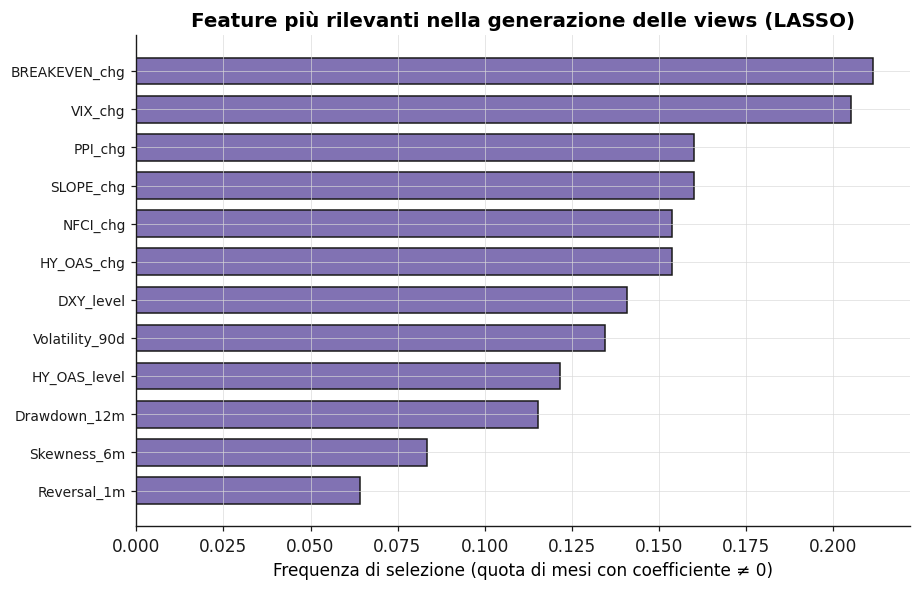

                freq_selezione  coef_medio  impatto_medio
BREAKEVEN_chg           0.2115     -0.0025         0.0025
VIX_chg                 0.2051     -0.0041         0.0041
PPI_chg                 0.1603     -0.0001         0.0005
SLOPE_chg               0.1603      0.0014         0.0014
NFCI_chg                0.1538     -0.0012         0.0012
HY_OAS_chg              0.1538     -0.0044         0.0044
DXY_level               0.1410      0.0001         0.0020
Volatility_90d          0.1346      0.0011         0.0011
HY_OAS_level            0.1218      0.0035         0.0035
Drawdown_12m            0.1154     -0.0005         0.0005
Skewness_6m             0.0833      0.0005         0.0005
Reversal_1m             0.0641     -0.0010         0.0010


In [36]:
# =============================================================================
# DRIVER DELLE VIEWS — feature più rilevanti nel LASSO pooled cross-sezionale
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
from plots import apply_theme, PALETTE
apply_theme()

cp = book.coef_path                                   # (156 mesi × 27 feature)
drivers = (pd.DataFrame({
        "freq_selezione":  (cp != 0).mean(),          # quota di mesi con coef ≠ 0
        "coef_medio":       cp.where(cp != 0).mean(),  # coefficiente medio (con segno)
        "impatto_medio":    cp.abs().where(cp != 0).mean(),
    })
    .sort_values("freq_selezione", ascending=False))

TOP = 12
_top = drivers.head(TOP).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(range(len(_top)), _top["freq_selezione"].values,
        color=PALETTE.get("full", "#8172B3"), edgecolor=PALETTE["ink"], height=0.7)
ax.set_yticks(range(len(_top))); ax.set_yticklabels(_top.index, fontsize=9)
ax.set_xlabel("Frequenza di selezione (quota di mesi con coefficiente ≠ 0)")
ax.set_title("Feature più rilevanti nella generazione delle views (LASSO)")
ax.grid(True, axis="x")
fig.tight_layout()
fig.savefig("figures/lasso_view_drivers.png", dpi=200, bbox_inches="tight")
plt.show()

print(drivers.head(TOP).round(4).to_string())

In [37]:
# =============================================================================
# VALIDAZIONE INCROCIATA — Black-Litterman interno vs PyPortfolioOpt
# =============================================================================
from config import CONFIG
import numpy as np, pandas as pd
from pypfopt.black_litterman import BlackLittermanModel as PPBL
from black_litterman import BlackLittermanModel

def valida_bl_pypfopt(model, seed, P_row, Q_val, tau=0.05, delta=2.5):
    # Genera un caso sintetico e confronta mu_BL e Sigma_BL delle due implementazioni
    assets = ["A", "B", "C", "D", "E"]; k = 5
    rng = np.random.default_rng(seed)
    X = pd.DataFrame(rng.normal(0.006, 0.03, (200, 5)), columns=assets)
    S = X.cov(); w = pd.Series([1 / k] * k, index=assets)
    pi = pd.Series(delta * (S.values @ w.values), index=assets) 
    P = pd.DataFrame([P_row], columns=assets); Q = pd.Series([Q_val])
    Om = pd.Series(np.diag(P.values @ (tau * S.values) @ P.values.T), index=[0])
    # --- PyPortfolioOpt: input passati direttamente --------------------------
    pp = PPBL(S, pi=pi, P=P.values, Q=Q.values.reshape(-1, 1),
              omega=np.diag(Om.values), tau=tau)
    mu_pp, cov_pp = pp.bl_returns(), pp.bl_cov()
    # --- Nostro_posterior con gli STESSI input ------------------------------
    tb = model.tau; model.tau = tau
    mu_mio, cov_mio = model._posterior(pi, S, P, Q, Om); model.tau = tb
    return (float(np.max(np.abs(mu_pp.values - mu_mio.values))),
            float(np.max(np.abs(cov_pp.values - cov_mio.values))))

model = BlackLittermanModel(CONFIG)
casi = [("vista assoluta A",   [1, 0, 0, 0, 0],  0.012),
        ("vista assoluta B",   [0, 1, 0, 0, 0],  0.004),
        ("vista relativa A-C", [1, 0, -1, 0, 0], 0.008),
        ("vista relativa D-E", [0, 0, 0, 1, -1], -0.003)]

print("Validazione Black-Litterman: _posterior interno vs PyPortfolioOpt")
for i, (nome, Pr, Qv) in enumerate(casi):
    dmu, dcov = valida_bl_pypfopt(model, i, Pr, Qv)
    ok = max(dmu, dcov) < 1e-8
    print(f"  {nome:20} Δ mu_BL = {dmu:.1e} | Δ Sigma_BL = {dcov:.1e}  {'✓' if ok else '✗'}")

Validazione Black-Litterman: _posterior interno vs PyPortfolioOpt
  vista assoluta A     Δ mu_BL = 8.7e-19 | Δ Sigma_BL = 6.8e-21  ✓
  vista assoluta B     Δ mu_BL = 4.3e-19 | Δ Sigma_BL = 1.4e-20  ✓
  vista relativa A-C   Δ mu_BL = 4.3e-19 | Δ Sigma_BL = 2.7e-20  ✓
  vista relativa D-E   Δ mu_BL = 2.2e-19 | Δ Sigma_BL = 1.4e-20  ✓


In [38]:
# =============================================================================
# DIAGNOSTICA DEL BLOCCO VIEWS (LASSO)
# =============================================================================
import numpy as np, pandas as pd

def lasso_selection_report(book):
    # Raccoglie in un dizionario tutte le metriche diagnostiche sul ViewBook.
    cp = book.coef_path
    out = {}
    # Frequenza con cui ciascuna feature entra nel modello.
    out["feature_frequency"] = (cp != 0).mean().sort_values(ascending=False)
    # Sparsita': quante feature attive per mese.
    n_active = (cp != 0).sum(axis=1)
    out["active_features_per_month"] = pd.Series({
        "media": n_active.mean(), "mediana": n_active.median(),
        "min": n_active.min(), "max": n_active.max(),
        "mesi_con_0_feature": int((n_active == 0).sum()), "n_mesi": len(n_active)})
    # Frequenza di view ATTIVA per asset (quante volte l'asset e' selezionato).
    asset_hits = {}
    for t, vs in book.views.items():
        for a in vs.assets:
            asset_hits.setdefault(a, {"attive": 0, "totale": 0})["totale"] += 1
        for a in vs.selected:
            asset_hits[a]["attive"] += 1
    rows = [{"asset": a, "%_view_attive": 100 * d["attive"] / d["totale"] if d["totale"] else 0,
             "n_attive": d["attive"], "n_mesi_disp": d["totale"]}
            for a, d in asset_hits.items()]
    out["asset_view_frequency"] = pd.DataFrame(rows).set_index("asset").sort_values(
        "%_view_attive", ascending=False)
    # Instabilita': quante feature cambiano stato (dentro/fuori) da un mese all'altro.
    active = (cp != 0).astype(int)
    churn = active.diff().abs().sum(axis=1).dropna()
    out["selection_instability"] = pd.Series({
        "feature_cambiate_per_mese_media": churn.mean(), "su_feature_totali": cp.shape[1]})
    # Copertura: in quanti mesi il LASSO esprime almeno una view.
    nviews = pd.Series({t: len(vs.selected) for t, vs in book.views.items()})
    out["months_with_views"] = pd.Series({
        "mesi_con_>=1_view": int((nviews > 0).sum()), "n_mesi": len(nviews),
        "%_mesi_con_view": 100 * (nviews > 0).mean(), "media_view_per_mese": nviews.mean()})
    return out

r = lasso_selection_report(book)

_spa = r["active_features_per_month"]
_cov = r["months_with_views"]
_ins = r["selection_instability"]
_n = int(_spa["n_mesi"])
_zero = int(_spa["mesi_con_0_feature"])
_covm = int(_cov["mesi_con_>=1_view"])

print("DIAGNOSTICA DEL BLOCCO VIEWS (LASSO)\n")

print("Sparsità della selezione (feature attive per mese)")
print(f"  media: {_spa['media']:.2f}")
print(f"  mediana: {_spa['mediana']:.0f}")
print(f"  intervallo (min–max): {_spa['min']:.0f} – {_spa['max']:.0f}")
print(f"  mesi senza feature: {_zero}/{_n}  ({100*_zero/_n:.0f}%)")

print("\nCopertura (mesi con almeno una view attiva)")
print(f"  mesi con view: {_covm}/{_n}  ({100*_covm/_n:.0f}%)")
print(f"  view medie per mese: {_cov['media_view_per_mese']:.2f}")

print("\nInstabilità della selezione")
print(f"  feature che cambiano stato ogni mese: {_ins['feature_cambiate_per_mese_media']:.2f} su {int(_ins['su_feature_totali'])} totali")

print("\nFrequenza di view attiva per asset")
_av = r["asset_view_frequency"].rename(columns={
    "%_view_attive": "% mesi", "n_attive": "n. view", "n_mesi_disp": "mesi disp."})
display(_av.round(1))

DIAGNOSTICA DEL BLOCCO VIEWS (LASSO)

Sparsità della selezione (feature attive per mese)
  media: 2.06
  mediana: 1
  intervallo (min–max): 0 – 18
  mesi senza feature: 76/156  (49%)

Copertura (mesi con almeno una view attiva)
  mesi con view: 25/156  (16%)
  view medie per mese: 0.71

Instabilità della selezione
  feature che cambiano stato ogni mese: 1.84 su 27 totali

Frequenza di view attiva per asset


,% mesi,n. view,mesi disp.
asset,,,
XEON.DE,10.3,16,156
DBXP.DE,10.3,16,156
SYBZ.DE,9.5,8,84
IQQE.DE,9.0,14,156
IQQN.DE,6.4,10,156
SJPA.L,5.8,9,156
IGLN.L,5.8,9,156
IHYG.L,5.1,8,156
SMEA.L,3.8,6,156


VARIAZIONE METRICHE A SECONDA DELLO SCENARIO DI VOLATILITY TARGETING
SHARPE RATIO


,Naturale,vol 7%,vol 10%,vol 12%
Markowitz,0.962,0.965,0.875,0.859
Black-Litterman,0.924,0.925,0.713,0.644
BL + views LASSO,0.927,0.928,0.717,0.644
Framework completo,0.892,0.852,0.694,0.638



VOLATILITÀ REALIZZATA (%)


,Naturale,vol 7%,vol 10%,vol 12%
Markowitz,8.48,7.59,9.18,9.27
Black-Litterman,6.59,7.72,10.52,11.06
BL + views LASSO,6.65,7.74,10.54,11.06
Framework completo,6.44,7.57,9.58,9.92



MAX DRAWDOWN (%)


,Naturale,vol 7%,vol 10%,vol 12%
Markowitz,-11.45,-9.63,-13.27,-13.27
Black-Litterman,-9.37,-11.21,-15.78,-15.75
BL + views LASSO,-9.37,-11.21,-15.78,-15.75
Framework completo,-9.37,-10.67,-14.69,-15.63


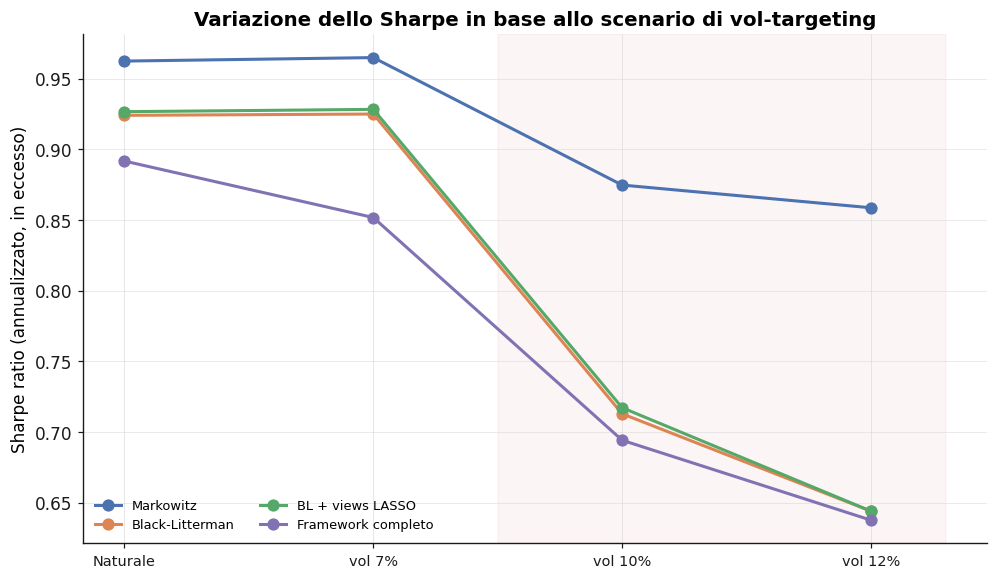

In [39]:
# =============================================================================
# ROBUSTEZZA — effetto del vol-targeting sul confronto tra modelli 
# =============================================================================
import copy
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from backtest import Backtester, VariantSpec
from plots import PALETTE, LABELS, apply_theme

warnings.filterwarnings("ignore", message="Solution may be inaccurate")

_MODELS = [
    ("markowitz",  "sample", "sample", False),
    ("bl_classic", "pi",     "lw",     False),
    ("bl_views",   "bl",     "lw",     False),
    ("full",       "bl",     "lw",     True),
]

def _run_variants(gamma_mode, target_vol=None):
    cfg = copy.deepcopy(CONFIG)
    if target_vol is not None:
        cfg.risk.target_vol_annual = target_vol
    specs = [VariantSpec(n, mu, sg, rg, gamma_mode, "A") for (n, mu, sg, rg) in _MODELS]
    bt_v = Backtester(cfg).run(md, bl, rb, variants=specs)
    return {n: bt_v.results[n].metrics for (n, _, _, _) in _MODELS}

_scenari = {
    "Naturale": _run_variants("fixed"),
    "vol 7%":   _run_variants("calibrated", 0.07),
    "vol 10%":  _run_variants("calibrated", 0.10),
    "vol 12%":  _run_variants("calibrated", 0.12),
}
_names = [m[0] for m in _MODELS]

def _tabella(metric, scale=1.0):
    return pd.DataFrame(
        {sc: {n: vals[n][metric] * scale for n in _names} for sc, vals in _scenari.items()}
    ).loc[_names].rename(index=LABELS)

# --- Tabelle di riferimento (righe leggibili) -------------------------------
print("VARIAZIONE METRICHE A SECONDA DELLO SCENARIO DI VOLATILITY TARGETING")
print("SHARPE RATIO")
display(_tabella("sharpe").round(3))
print("\nVOLATILITÀ REALIZZATA (%)")
display(_tabella("ann_vol", 100).round(2))
print("\nMAX DRAWDOWN (%)")
display(_tabella("max_dd", 100).round(2))

# --- Interpretazione data-driven --------------------------------------------
_sh = _tabella("sharpe")
_drop_mkt = _sh.loc[LABELS["markowitz"], "Naturale"] - _sh.loc[LABELS["markowitz"], "vol 12%"]
_drop_bl = _sh.loc[LABELS["bl_classic"], "Naturale"] - _sh.loc[LABELS["bl_classic"], "vol 12%"]
# --- Figura 12 ---------------------------
apply_theme()
_x = np.arange(_sh.shape[1])
fig, ax = plt.subplots(figsize=(9.2, 5.4))
for _lbl in _sh.index:
    _key = next((k for k, v in LABELS.items() if v == _lbl), _lbl)
    ax.plot(_x, _sh.loc[_lbl].values, marker="o", ms=7, lw=2.0,
            color=PALETTE.get(_key, PALETTE["ink"]), label=_lbl)
ax.axvspan(1.5, len(_x) - 0.7, color=PALETTE["stress"], alpha=0.05, zorder=0)
ax.set_xticks(_x); ax.set_xticklabels(_sh.columns, fontsize=9.5)
ax.set_ylabel("Sharpe ratio (annualizzato, in eccesso)")
ax.set_title("Variazione dello Sharpe in base allo scenario di vol-targeting")
ax.legend(loc="lower left", ncol=2, fontsize=8.5)
ax.grid(True, axis="y", color=PALETTE["grid"], lw=0.6, alpha=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
save_fig(fig, "fig_12_voltarget_confronto")
plt.show()

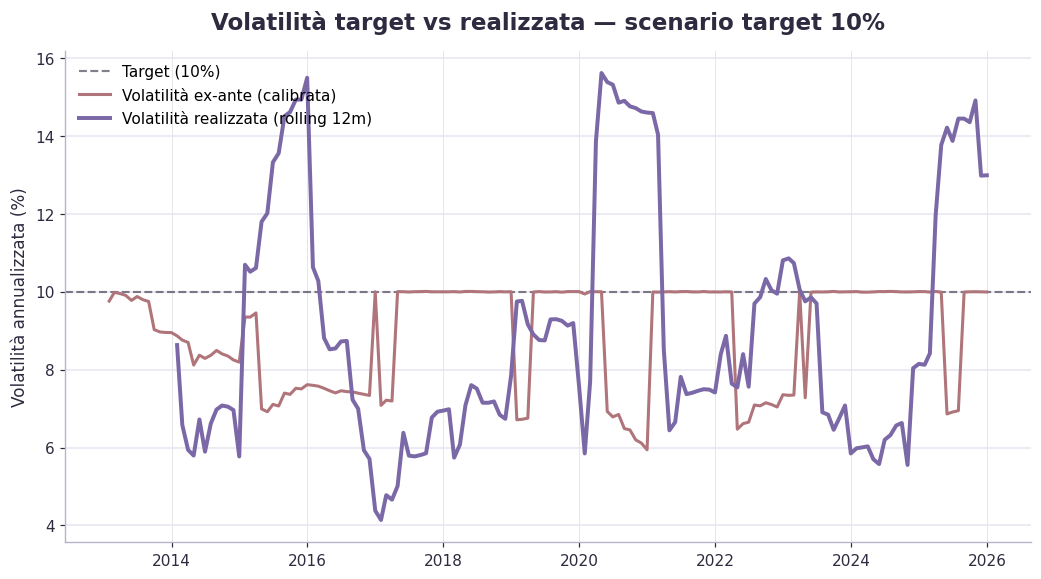

In [40]:
# =============================================================================
# VOLATILITÀ TARGET VS REALIZZATA — verifica di calibrazione (scenario 10%)
# =============================================================================
import copy
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from backtest import VariantSpec, VariantGenerator, Backtester

PALETTE = {"full": "#7B68A6", "accent": "#B0757A", "ink": "#2E2A3F", "grid": "#E7E2F0"}

TARGET = 0.10
cfg = copy.deepcopy(CONFIG)
cfg.risk.target_vol_annual = TARGET

spec = VariantSpec("full_target10", "bl", "lw", True, "calibrated", "A")
gen = VariantGenerator(cfg)
log_rets = np.log(md.prices_eur.resample("ME").last()).diff()
w = gen.run(spec, bl, rb, log_rets)

bt_t = Backtester(cfg)
simple_rets = bt_t._monthly_simple_returns(md.prices_eur)
rf = simple_rets["XEON.DE"]
res = bt_t.evaluate("full_target10", w, simple_rets, rf)

ex_ante = res.ex_ante_vol * 100                                   # vol ex-ante attesa, %
realized = (res.returns.rolling(12).std() * np.sqrt(12) * 100)    # vol realizzata rolling 12m, %

fig, ax = plt.subplots(figsize=(9.6, 5.4))
ax.axhline(TARGET * 100, color=PALETTE["ink"], lw=1.4, ls="--", alpha=0.6,
           label=f"Target ({TARGET*100:.0f}%)")
ax.plot(ex_ante.index, ex_ante.values, color=PALETTE["accent"], lw=2.0,
        label="Volatilità ex-ante (calibrata)")
ax.plot(realized.index, realized.values, color=PALETTE["full"], lw=2.6,
        label="Volatilità realizzata (rolling 12m)")
ax.set_ylabel("Volatilità annualizzata (%)", fontsize=11, color=PALETTE["ink"])
ax.set_title("Volatilità target vs realizzata — scenario target 10%", fontsize=15,
              fontweight="bold", color=PALETTE["ink"], pad=14)
ax.legend(loc="upper left", fontsize=10, frameon=False)
ax.grid(True, axis="y", color=PALETTE["grid"], lw=1.0, alpha=0.9)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#B9B3C9")
ax.spines["bottom"].set_color("#B9B3C9")
ax.tick_params(colors=PALETTE["ink"], labelsize=10)
fig.tight_layout()
save_fig(fig, "fig_04_03_vol_target_vs_realizzata")
plt.show()

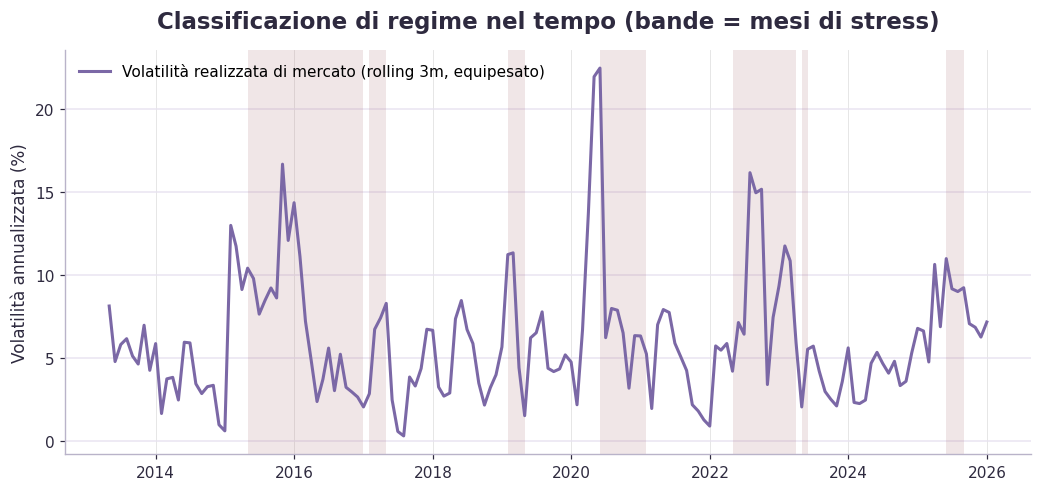

In [41]:
# =============================================================================
# CLASSIFICAZIONE DI REGIME NEL TEMPO — normale vs stress, con volatilità di sfondo
# =============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

PALETTE = {"full": "#7B68A6", "ink": "#2E2A3F", "grid": "#E7E2F0", "stress_band": "#B0757A"}

regimes = rb.regimes.sort_index()                      # Series: data decisione -> "normal"/"stress"

# vol di mercato di sfondo: realizzata rolling 3m dell'equipesato, come proxy del
# contesto di rischio che il modello osserva
mkt_vol = (bt.results["equal_weight"].returns.rolling(3).std() * np.sqrt(12) * 100)

fig, ax = plt.subplots(figsize=(9.6, 4.6))

# bande di stress: individua i tratti contigui e li disegna come rettangoli
is_stress = (regimes == "stress")
months = list(regimes.index)
start = None
for i, t in enumerate(months):
    if is_stress[t] and start is None:
        start = t
    if start is not None and (not is_stress[t] or i == len(months) - 1):
        end = t if not is_stress[t] else months[min(i + 1, len(months) - 1)]
        ax.axvspan(start, end, color=PALETTE["stress_band"], alpha=0.18, lw=0)
        start = None

ax.plot(mkt_vol.index, mkt_vol.values, color=PALETTE["full"], lw=2.0,
        label="Volatilità realizzata di mercato (rolling 3m, equipesato)")
ax.set_ylabel("Volatilità annualizzata (%)", fontsize=11, color=PALETTE["ink"])
ax.set_title("Classificazione di regime nel tempo (bande = mesi di stress)", fontsize=15,
              fontweight="bold", color=PALETTE["ink"], pad=14)
ax.legend(loc="upper left", fontsize=10, frameon=False)
ax.grid(True, axis="y", color=PALETTE["grid"], lw=1.0, alpha=0.9)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#B9B3C9")
ax.spines["bottom"].set_color("#B9B3C9")
ax.tick_params(colors=PALETTE["ink"], labelsize=10)
fig.tight_layout()
save_fig(fig, "fig_04_05_regime_timeline")
plt.show()

ANALISI IN SOTTOPERIODI DI STRESS
SHARPE (in eccesso)


,Markowitz,Black-Litterman,BL + views LASSO,Framework completo,Equipesato (1/N)
2013-2015,1.34,1.29,1.30,1.34,1.23
2016-2019,1.14,1.34,1.34,1.24,1.28
2020-2022,0.62,0.55,0.55,0.50,0.48
2023-2025,1.40,1.06,1.09,1.04,0.94
Intero periodo,0.96,0.92,0.93,0.89,0.86



Classifica completa framework
  2013-2015        Markowitz #2/5   vincitore: Framework completo
  2016-2019        Markowitz #5/5   vincitore: BL + views LASSO
  2020-2022        Markowitz #1/5   vincitore: Markowitz
  2023-2025        Markowitz #1/5   vincitore: Markowitz
  Intero periodo   Markowitz #1/5   vincitore: Markowitz


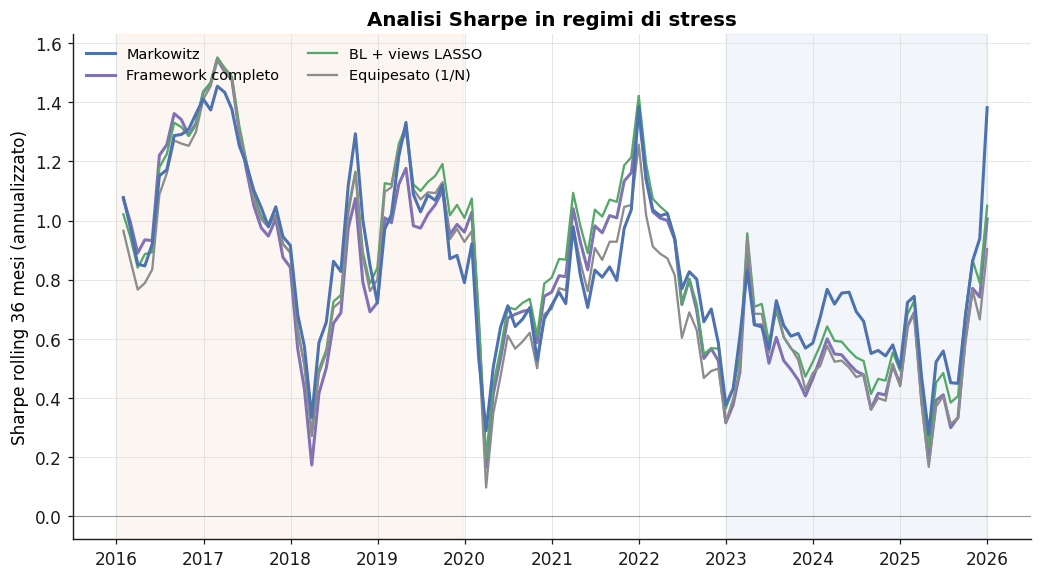

In [42]:
# =============================================================================
# STABILITA' SOTTO-CAMPIONE
# =============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from plots import PALETTE, LABELS, apply_theme

apply_theme()

RF_TICKER = "XEON.DE"
rf = md.prices_eur[RF_TICKER].resample("ME").last().pct_change()
STRATS = [s for s in ["markowitz", "bl_classic", "bl_views", "full", "equal_weight"]
          if s in bt.results]
R = {s: bt.results[s].returns for s in STRATS}

def sharpe_excess(r, ann=12):
    e = (r - rf.reindex(r.index)).dropna()
    return e.mean() / e.std(ddof=1) * np.sqrt(ann) if e.std(ddof=1) > 0 else np.nan

# --- tabella Sharpe per sotto-periodo ----------------------------------------
PERIODS = {
    "2013-2015": ("2013-01", "2015-12"),
    "2016-2019": ("2016-01", "2019-12"),
    "2020-2022": ("2020-01", "2022-12"),
    "2023-2025": ("2023-01", "2025-12"),
}
rows = {}
for pname, (a, b) in PERIODS.items():
    rows[pname] = {s: sharpe_excess(R[s][(R[s].index >= a) & (R[s].index <= b)]) for s in STRATS}
rows["Intero periodo"] = {s: sharpe_excess(R[s]) for s in STRATS}
sub = pd.DataFrame(rows).T[STRATS]

print("ANALISI IN SOTTOPERIODI DI STRESS")
print("SHARPE (in eccesso)")
display(sub.round(2).rename(columns=LABELS))

print("\nClassifica completa framework")
for p in sub.index:
    _rank = int(sub.loc[p].rank(ascending=False)["markowitz"])
    _win = LABELS.get(sub.loc[p].idxmax(), sub.loc[p].idxmax())
    print(f"  {p:16s} Markowitz #{_rank}/{len(STRATS)}   vincitore: {_win}")

# --- messaggio-chiave data-driven -------------------------------------------
_best = int((sub.drop("Intero periodo").rank(axis=1, ascending=False)["markowitz"] == 1).sum())
_worst = int((sub.drop("Intero periodo").rank(axis=1, ascending=False)["markowitz"] == len(STRATS)).sum())

# --- Figura 13 ---------------------------------------------------
def rolling_sharpe(r, win=36, ann=12):
    e = (r - rf.reindex(r.index)).dropna()
    return (e.rolling(win).mean() / e.rolling(win).std(ddof=1) * np.sqrt(ann)).dropna()

fig, ax = plt.subplots(figsize=(9.6, 5.4))
for s in [x for x in ["markowitz", "full", "bl_views", "equal_weight"] if x in R]:
    rs = rolling_sharpe(R[s])
    ax.plot(rs.index, rs.values, lw=2.0 if s in ("markowitz", "full") else 1.5,
            color=PALETTE.get(s, PALETTE["ink"]), label=LABELS.get(s, s),
            zorder=5 if s == "markowitz" else 4)
ax.axvspan(pd.Timestamp("2016-01-01"), pd.Timestamp("2019-12-31"),
           color=PALETTE["bl_classic"], alpha=0.07, zorder=0)
ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2025-12-31"),
           color=PALETTE["markowitz"], alpha=0.07, zorder=0)
ax.axhline(0, color=PALETTE["ink"], lw=0.7, alpha=0.4)
ax.set_ylabel("Sharpe rolling 36 mesi (annualizzato)")
ax.set_title("Analisi Sharpe in regimi di stress")
ax.legend(loc="upper left", ncol=2)
fig.tight_layout()
save_fig(fig, "fig_13_rolling_sharpe_subsample")
plt.show()

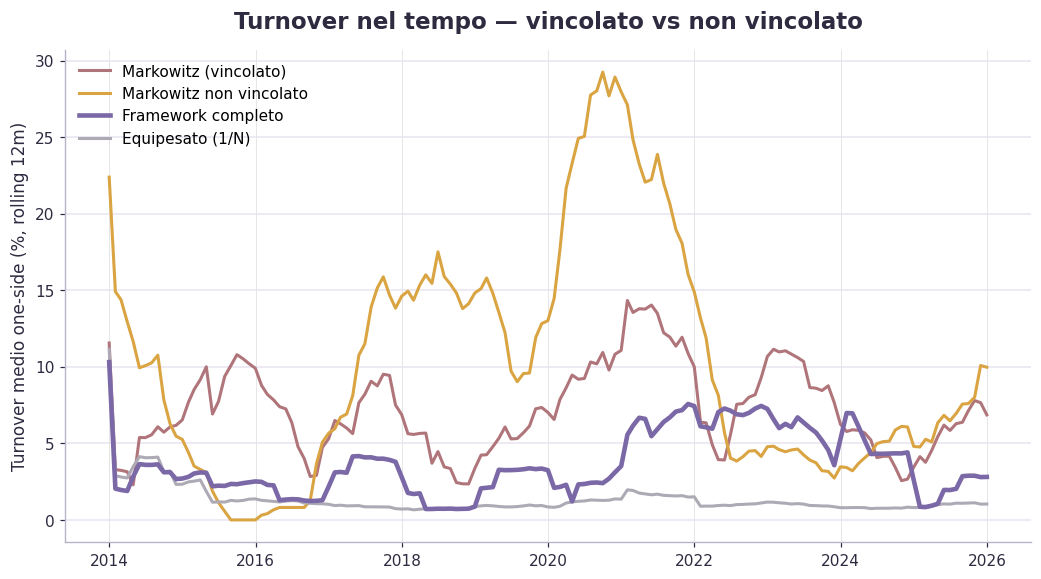

In [43]:
# =============================================================================
# TURNOVER NEL TEMPO — stabilità delle allocazioni, vincolato vs non vincolato
# =============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from backtest import NAKED_VARIANTS, VariantGenerator, Backtester

PALETTE = {
    "markowitz":       "#B0757A",
    "markowitz_nudo":  "#D9A441",
    "full":            "#7B68A6",
    "equal_weight":    "#ADAAB5",
    "ink":             "#2E2A3F",
    "grid":            "#E7E2F0",
}
LABELS = {
    "markowitz": "Markowitz (vincolato)", "markowitz_nudo": "Markowitz non vincolato",
    "full": "Framework completo", "equal_weight": "Equipesato (1/N)",
}

bt_naked = Backtester(CONFIG).run(md, bl, rb, variants=NAKED_VARIANTS)

turn = {
    "markowitz":      bt.results["markowitz"].turnover,
    "markowitz_nudo": bt_naked.results["markowitz_nudo"].turnover,
    "full":           bt.results["full"].turnover,
    "equal_weight":   bt.results["equal_weight"].turnover,
}
STRATS = ["markowitz", "markowitz_nudo", "full", "equal_weight"]

fig, ax = plt.subplots(figsize=(9.6, 5.4))
for s in STRATS:
    roll = (turn[s] * 100).rolling(12).mean()
    ax.plot(roll.index, roll.values,
            lw=3.0 if s == "full" else 2.0,
            color=PALETTE[s], label=LABELS[s],
            zorder=5 if s == "full" else 3)
ax.set_ylabel("Turnover medio one-side (%, rolling 12m)", fontsize=11, color=PALETTE["ink"])
ax.set_title("Turnover nel tempo — vincolato vs non vincolato", fontsize=15,
              fontweight="bold", color=PALETTE["ink"], pad=14)
ax.legend(loc="upper left", fontsize=10, frameon=False)
ax.grid(True, axis="y", color=PALETTE["grid"], lw=1.0, alpha=0.9)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#B9B3C9")
ax.spines["bottom"].set_color("#B9B3C9")
ax.tick_params(colors=PALETTE["ink"], labelsize=10)
fig.tight_layout()
save_fig(fig, "fig_04_04_turnover")
plt.show()

In [44]:
# =============================================================================
# CONFRONTO VINCOLATO vs NON VINCOLATO
# =============================================================================
from backtest import Backtester
 
# constrained include esplicitamente "markowitz": il default del metodo
# (["full", "bl_classic", "equal_weight"]) non basta perché la Tabella 4.11
# nel testo confronta anche il Markowitz vincolato con la sua versione nuda.
_hr = Backtester(CONFIG).horse_race(md, bl, rb, constrained=["markowitz", "bl_classic", "full"])
 
_ROWS_HR = {
    "markowitz":        "Markowitz (vincolato)",
    "markowitz_nudo":   "Markowitz non vincolato",
    "bl_classic":       "Black-Litterman (vincolato)",
    "bl_classic_nudo":  "Black-Litterman non vincolato",
    "full":             "Framework completo",
}
_order_hr = ["markowitz", "markowitz_nudo", "bl_classic", "bl_classic_nudo", "full"]
_disp = _hr.reindex([k for k in _order_hr if k in _hr.index]).rename(index=_ROWS_HR)
 
_pct_cols = ["ann_return", "ann_vol", "max_dd", "turnover_avg", "w_max"]
_disp = _disp.assign(**{c: _disp[c] * 100 for c in _pct_cols})
_disp = _disp.rename(columns={
    "ann_return": "Rend.%", "ann_vol": "Vol.%", "sharpe": "Sharpe", "max_dd": "MaxDD%",
    "turnover_avg": "Turn.%", "n_eff": "N. eff. posizioni", "w_max": "Peso max %",
})
print("CONFRONTO VINCOLATO vs NON VINCOLATO — Tabella 4.11")
display(_disp[["Rend.%", "Vol.%", "Sharpe", "MaxDD%", "Turn.%",
                "N. eff. posizioni", "Peso max %"]].round(2))

CONFRONTO VINCOLATO vs NON VINCOLATO — Tabella 4.11


,Rend.%,Vol.%,Sharpe,MaxDD%,Turn.%,N. eff. posizioni,Peso max %
Markowitz (vincolato),8.567161,8.475538,0.962344,-11.454406,7.603097,4.642829,25.0
Markowitz non vincolato,12.711617,13.383636,0.932903,-16.910029,10.893247,1.873182,67.452108
Black-Litterman (vincolato),6.507913,6.59398,0.923959,-9.367851,1.909888,10.06337,13.360152
Black-Litterman non vincolato,6.5129,6.593305,0.924759,-9.366841,1.917331,10.070123,13.357224
Framework completo,6.144466,6.438441,0.891597,-9.367851,4.114467,9.609434,14.061846


In [45]:
#=============================================================================
# SENSIBILITA' AI COSTI DI TRANSAZIONE + break-even
# =============================================================================
import copy
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from backtest import Backtester
from plots import PALETTE, LABELS, apply_theme
apply_theme()
STRATS = ["markowitz", "bl_classic", "bl_views", "full", "equal_weight"]
LEVELS = [0, 5, 10, 20, 40, 60]        # cost_bps (turnover one-side)
sharpe, turn = {}, {}
for L in LEVELS:
    cfg = copy.deepcopy(CONFIG)
    cfg.backtest.transaction_costs_bps = float(L)
    bt_c = Backtester(cfg).run(md, bl, rb)
    sharpe[L] = {s: bt_c.results[s].metrics["sharpe"] for s in STRATS if s in bt_c.results}
    if L == 0:
        turn = {s: bt_c.results[s].metrics["turnover_avg"] * 100 for s in STRATS if s in bt_c.results}
df = pd.DataFrame(sharpe).T
df.index.name = "cost_bps"

present = [s for s in STRATS if s in df.columns]

print("ANALISI PER LIVELLO DI COSTO")
print("SHARPE NETTO")
print("(cost_bps = costo sul turnover unilaterale)")
display(df[present].round(3).rename(columns=LABELS))

print("\nTURNOVER MEDIO one-side (%/mese)")
_turn_s = pd.Series({LABELS.get(s, s): turn[s] for s in present}).round(2)
display(_turn_s)

ANALISI PER LIVELLO DI COSTO
SHARPE NETTO
(cost_bps = costo sul turnover unilaterale)


,Markowitz,Black-Litterman,BL + views LASSO,Framework completo,Equipesato (1/N)
cost_bps,,,,,
0,0.973,0.927,0.932,0.899,0.861
5,0.968,0.925,0.929,0.895,0.859
10,0.962,0.924,0.927,0.892,0.858
20,0.952,0.921,0.921,0.884,0.855
40,0.931,0.915,0.910,0.870,0.850
60,0.910,0.909,0.899,0.855,0.844



TURNOVER MEDIO one-side (%/mese)


Markowitz             7.60
Black-Litterman       1.91
BL + views LASSO      3.23
Framework completo    4.11
Equipesato (1/N)      1.92
dtype: float64

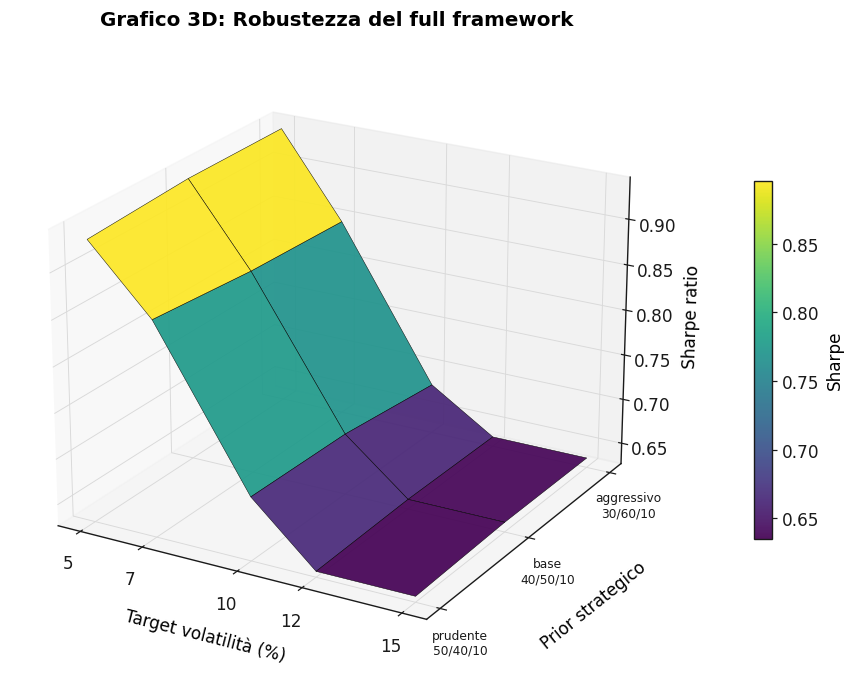

In [46]:
# =============================================================================
# ROBUSTEZZA 3D — Sharpe del framework su target-vol e prior strategico
# =============================================================================
import copy
import numpy as np
import matplotlib.pyplot as plt
from backtest import Backtester, VariantSpec, strategic_from_macro
from black_litterman import BlackLittermanModel
from plots import apply_theme

_targets = [0.05, 0.07, 0.10, 0.12, 0.15]                        
_priors = {"prudente\n50/40/10":  {"safe": 0.50, "risky": 0.40, "real": 0.10},
           "base\n40/50/10":      {"safe": 0.40, "risky": 0.50, "real": 0.10},
           "aggressivo\n30/60/10": {"safe": 0.30, "risky": 0.60, "real": 0.10}}

_Z = np.zeros((len(_priors), len(_targets)))
for _i, (_pn, _macro) in enumerate(_priors.items()):
    _cfg = copy.deepcopy(CONFIG)
    _cfg.bl.strategic_weights = strategic_from_macro(CONFIG, _macro)
    _cfg.validate()
    _blp = BlackLittermanModel(_cfg).run(md, book)       # BL una volta per prior
    for _j, _tv in enumerate(_targets):
        _cfg2 = copy.deepcopy(_cfg); _cfg2.risk.target_vol_annual = _tv
        _spec = [VariantSpec("full", "bl", "lw", True, "calibrated", "A")]
        _btc = Backtester(_cfg2).run(md, _blp, rb, variants=_spec)
        _Z[_i, _j] = _btc.results["full"].metrics["sharpe"]

# --- Figura 14 ----------------------------------------------------------
apply_theme()
_X, _Y = np.meshgrid([t * 100 for t in _targets], np.arange(len(_priors)))
fig = plt.figure(figsize=(9.5, 6.8))
ax = fig.add_subplot(111, projection="3d")
_surf = ax.plot_surface(_X, _Y, _Z, cmap="viridis", edgecolor="k", linewidth=0.3, alpha=0.92)
ax.set_xlabel("Target volatilità (%)", labelpad=10)
ax.set_xticks([t * 100 for t in _targets])               # tick esatti a 7, 10, 12
ax.set_yticks(np.arange(len(_priors))); ax.set_yticklabels(list(_priors.keys()), fontsize=8)
ax.set_ylabel("Prior strategico", labelpad=18)
ax.set_zlabel("Sharpe ratio", labelpad=6)
ax.set_title("Grafico 3D: Robustezza del full framework")
ax.view_init(elev=22, azim=-60)                          # angolo di vista
fig.colorbar(_surf, ax=ax, shrink=0.55, pad=0.10, label="Sharpe")
fig.subplots_adjust(left=0.02, right=0.90, top=0.92, bottom=0.05)
save_fig(fig, "fig_14_robustezza_3d")
plt.show()